In [ ]:

# -*- coding: utf-8 -*-
# 專案: 一級交易商壓力分析 (模組化版本)
# 版本: 1.9 (Cell 1 - 修正 nonlocal/global 錯誤)
# 日期: 2025-05-03
# 地點: 台灣 高雄市 三民區
# ==================================================
# @title Cell 1: 專案初始化與全局設定 (含互動式日期)
# --------------------------------------------------
# 功能: 初始化專案，定義全局配置字典 PROJECT_CONFIG (包含 API Key, 權重, URL,
#       參數等)，初始化全局追蹤器 EXECUTION_TRACKER，導入基礎庫，設定時區。
#       實現互動式日期選擇：嘗試載入已存設定，若無則使用回退日期 (2018-01-01起)
#       執行，並提供介面供使用者更新和儲存日期。
# 版本: 1.9 (修正 nonlocal/global 錯誤)
# 日期: 2025-05-03
# 依賴: None
# 輸入: (優先) 'date_config.json' 設定檔 /
#       (其次) 使用者透過 ipywidgets 輸入並點擊按鈕
# 輸出: ['global:PROJECT_CONFIG', 'global:EXECUTION_TRACKER',
#        'global:confirmed_start_date', 'global:confirmed_end_date',
#        'global:target_tz', 'global:libs_loaded']
#       'date_config.json' (檔案寫入)
# ==================================================

# ==================================================
# 設計註解 (整合版 v2.7.1 - 開頭)
# --------------------------------------------------
# ## 本儲存格主要完成事項：
# * **此儲存格專用於初始化，不包含任何核心分析邏輯。**
# * 檢查並嘗試安裝/導入專案所需的核心庫 (pandas, ipywidgets, pytz, requests,
#   openpyxl, yfinance, numpy, scipy, matplotlib, fredapi)。
# * 定義並初始化全局配置字典 `PROJECT_CONFIG`，整合所有參數。
# * 定義並初始化全局執行追蹤器字典 `EXECUTION_TRACKER` 為空字典。
# * 初始化 Python 的根日誌記錄器。
# * 設定並儲存目標時區 (`target_tz`)。
# * **實現互動式日期選擇邏輯：**
#   * 定義程式預設 (2017/Today) 和回退日期 (2018/Today)。
#   * 嘗試從 `date_config.json` 載入上次儲存的日期。
#   * **若載入成功:** 使用配置日期設定全局變數 `confirmed_start_date`,
#     `confirmed_end_date`，並預填介面。
#   * **若載入失敗:** **自動使用回退日期 (2018/Today) 設定全局變數**，
#     並用此日期預填介面，確保首次執行能繼續。
#   * 創建並顯示 `ipywidgets` 日期選擇器和確認按鈕。
#   * 按鈕點擊事件處理：驗證使用者輸入，更新全局變數，並儲存到
#     `date_config.json`。
# * 在 `finally` 區塊中打印標準化的執行報告並更新 `EXECUTION_TRACKER`。
#
# ## 設計思路/邏輯說明：
# * 將所有配置集中到 `PROJECT_CONFIG`，方便管理。
# * 使用 `try-except` 處理庫導入、檔案讀寫和日期轉換，增加穩健性。
# * **關鍵：** 確保 Cell 1 執行後，`confirmed_start_date` 和
#   `confirmed_end_date` 總是有值（來自設定檔或回退值），以便後續儲存格
#   可以直接使用。
# * 使用 `ipywidgets` 提供使用者友善的日期修改方式。
# * 強制性的 `finally` 報告確保無論成功或失敗，都有執行記錄。
#
# ## 重要假設：
# * 運行環境支援 `pip install` (用於 Colab) 或已手動安裝所需套件。
# * 基礎 Python 環境可用。
# * Colab/Jupyter 環境支援 `ipywidgets` 顯示。
#
# ## 主要輸出/狀態變更：
# * `global:PROJECT_CONFIG`: 包含專案配置的字典。
# * `global:EXECUTION_TRACKER`: 包含 Cell 1 執行記錄的字典。
# * `global:confirmed_start_date` (str): 最終確認使用的開始日期
#   (來自設定檔、回退值或使用者更新)。
# * `global:confirmed_end_date` (str): 最終確認使用的結束日期
#   (來自設定檔、回退值或使用者更新)。
# * `global:target_tz`: 設定的時區物件。
# * `global:libs_loaded` (dict): 記錄核心函式庫是否成功載入。
# * `global:logger`: 配置好的根日誌記錄器。
# * `File:date_config.json`: (若使用者點擊按鈕更新) 儲存使用者確認的日期。
#
# ## 注意事項/後續步驟：
# * **必須** 是筆記本中第一個執行的儲存格。
# * **禁止** 在此儲存格中添加數據處理、模型訓練等工作流程步驟。
# * **首次執行:** 會自動使用 2018-01-01 到今天的日期範圍。請檢查介面
#   顯示的日期，如果需要修改，請點擊按鈕更新。
# * **後續執行:** 會載入上次儲存的日期。如果日期正確，可直接執行後續儲存格。
# * **後續步驟:** 執行 **Cell 2: 核心函式定義**。
# ==================================================

# --- 標準庫導入 ---
import time
import traceback
import pprint
import logging
import os
import json
import sys
import subprocess
from datetime import datetime, date, timezone, timedelta

# --- 嘗試安裝/導入第三方庫 ---
print("--- Cell 1: 開始檢查/安裝/導入函式庫 ---")
libs_loaded = {
    'pandas': False, 'ipywidgets': False, 'pytz': False, 'requests': False,
    'openpyxl': False, 'yfinance': False, 'numpy': False, 'scipy': False,
    'matplotlib': False, 'fredapi': False
}
try:
    # 檢查是否在 Colab 環境
    IN_COLAB = 'google.colab' in sys.modules
    # 定義需要安裝的套件列表
    packages_to_install = [
        '--upgrade', 'fredapi', 'pandas', 'matplotlib', 'requests',
        'openpyxl', 'yfinance', 'numpy', 'scipy', 'ipywidgets', 'pytz'
    ]

    if IN_COLAB:
        print("偵測到 Colab 環境，執行套件安裝/更新 (使用 pip)...")
        process = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', '--quiet'] + packages_to_install,
            check=True, capture_output=True, text=True
        )
        print("Colab 套件安裝/更新完成。")
    else:
        print("非 Colab 環境，請確保以下套件已安裝:")
        print(", ".join(p for p in packages_to_install if not p.startswith('--')))

    # 導入函式庫並更新狀態
    import pandas as pd; libs_loaded['pandas'] = True
    import ipywidgets as widgets; libs_loaded['ipywidgets'] = True
    from ipywidgets import HBox, VBox
    from IPython.display import display
    import pytz; libs_loaded['pytz'] = True
    import requests; libs_loaded['requests'] = True
    import openpyxl; libs_loaded['openpyxl'] = True
    import yfinance as yf; libs_loaded['yfinance'] = True
    import numpy as np; libs_loaded['numpy'] = True
    import scipy; libs_loaded['scipy'] = True
    import matplotlib; libs_loaded['matplotlib'] = True
    from fredapi import Fred; libs_loaded['fredapi'] = True

    import warnings
    warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
    warnings.filterwarnings("ignore", category=FutureWarning, module="yfinance")

    print("核心函式庫導入成功。")

except ImportError as e:
    print(f"錯誤：導入核心函式庫失敗: {e}。請檢查安裝。")
    libs_loaded = {k: False for k in libs_loaded}
except subprocess.CalledProcessError as e:
    print(f"錯誤：執行 pip install 指令時發生錯誤: {e}")
    print("錯誤輸出:\n", e.stderr)
    libs_loaded = {k: False for k in libs_loaded}
except Exception as e:
    print(f"錯誤：函式庫準備過程中發生未預期錯誤: {e}")
    libs_loaded = {k: False for k in libs_loaded}

print("--- Cell 1: 函式庫準備完成 ---")

# --- 儲存格標識符 ---
_cell_identifier = "Cell 1: 專案初始化與全局設定"

# --- 狀態追蹤變數 (用於 finally) ---
_cell_start_time = time.time()
_cell_status = "處理中"
_cell_warnings = []
_cell_notes = []
_cell_error = None
_cell_traceback = None
_cell_inputs = {}
_cell_outputs = {}
_cell_generated_files = ['date_config.json']

# --- 全局變數定義 ---
# 這些變數會在 Cell 1 的主範圍內定義，並在需要時被內部函式修改
PROJECT_CONFIG = {}
EXECUTION_TRACKER = {}
confirmed_start_date = None
confirmed_end_date = None
target_tz = None

# --- 設定檔路徑 ---
CONFIG_FILE_PATH = 'date_config.json'
_cell_inputs['config_file_path'] = CONFIG_FILE_PATH

# --- Widget 變數初始化 ---
start_date_picker = None
end_date_picker = None
confirm_button = None
output_area = None

# --- 主要執行邏輯 ---
try:
    # --- 0. 檢查基礎庫是否成功載入 ---
    if not libs_loaded['pandas'] or not libs_loaded['ipywidgets'] or not libs_loaded['pytz']:
        _cell_status = "失敗"
        _cell_error = "初始化失敗：缺少 pandas, ipywidgets 或 pytz 函式庫。"
        print(f"CRITICAL ERROR: {_cell_error}")
        raise ImportError(_cell_error)

    # --- 1. 初始化日誌記錄器 ---
    print("\n--- Cell 1: 初始化日誌記錄器 ---")
    logger = logging.getLogger()
    default_log_level = logging.INFO
    logger.setLevel(default_log_level)
    if logger.hasHandlers():
        logger.handlers.clear()
        print("已清除舊的日誌 handlers。")
    handler = logging.StreamHandler()
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    handler.setFormatter(formatter)
    logger.addHandler(handler)
    print(f"日誌記錄器已初始化，級別: {logging.getLevelName(logger.level)}。")
    logger.info(f"{_cell_identifier} - 日誌記錄器初始化完成。")

    # --- 2. 定義全局配置 PROJECT_CONFIG ---
    print("\n--- Cell 1: 定義全局配置 PROJECT_CONFIG ---")
    PROJECT_CONFIG = {
      # --- 基本設定 ---
      'project_name': '一級交易商壓力分析 (模組化)',
      'version': '1.9', # 更新版本號
      'fred_api_key': "77b0a570c6a17007e4f5af229c2aecc9",
      'timezone': 'Asia/Taipei',
      'log_level': default_log_level,
      # --- 日期相關 ---
      'default_start_date': "2017-01-01",
      'fallback_start_date': "2018-01-01",
      # --- 圖表設定 ---
      'trend_plot_days': 60,
      # --- 長天期公債 ETF 設定 ---
      'enable_lt_bond_etf_plot': True,
      'lt_bond_etf_ticker': "TLT",
      # --- NY Fed API URLs (分行顯示) ---
      'ny_fed_positions_urls': [
          "https://markets.newyorkfed.org/api/pd/get/SBN2024/timeseries/"
          "PDPOSGSC-L2_PDPOSGSC-G2L3_PDPOSGSC-G3L6_PDPOSGSC-G6L7_"
          "PDPOSGSC-G7L11_PDPOSGSC-G11L21_PDPOSGSC-G21.xlsx",
          "https://markets.newyorkfed.org/api/pd/get/SBN2022/timeseries/"
          "PDPOSGSC-L2_PDPOSGSC-G2L3_PDPOSGSC-G3L6_PDPOSGSC-G6L7_"
          "PDPOSGSC-G7L11_PDPOSGSC-G11L21_PDPOSGSC-G21.xlsx",
          "https://markets.newyorkfed.org/api/pd/get/SBN2015/timeseries/"
          "PDPOSGSC-L2_PDPOSGSC-G2L3_PDPOSGSC-G3L6_PDPOSGSC-G6L7_"
          "PDPOSGSC-G7L11_PDPOSGSC-G11.xlsx",
          "https://markets.newyorkfed.org/api/pd/get/SBN2013/timeseries/"
          "PDPOSGSC-L2_PDPOSGSC-G2L3_PDPOSGSC-G3L6_PDPOSGSC-G6L7_"
          "PDPOSGSC-G7L11_PDPOSGSC-G11.xlsx",
          "https://markets.newyorkfed.org/api/pd/get/SBP2013/timeseries/"
          "PDPUSGCS3LNOP_PDPUSGCS36NOP_PDPUSGCS611NOP_PDPUSGCSM11NOP.xlsx",
          "https://markets.newyorkfed.org/api/pd/get/SBP2001/timeseries/"
          "PDPUSGCS5LNOP_PDPUSGCS5MNOP.xlsx"
      ],
      # --- 舊版 SBP 加總邏輯 ---
      'sbp2013_cols_to_sum': [
          'PDPUSGCS3LNOP', 'PDPUSGCS36NOP', 'PDPUSGCS611NOP', 'PDPUSGCSM11NOP'
      ],
      'sbp2001_cols_to_sum': ['PDPUSGCS5LNOP', 'PDPUSGCS5MNOP'],
      # --- 壓力指數計算設定 ---
      'rolling_window_days': 252,
      'weights': {
          'sofr_dev': 0.35, 'spread_inv': 0.10, 'gross_pos': 0.05,
          'move': 0.25, 'vix': 0.15, 'pos_res_ratio': 0.10
      },
      # --- 指數平滑與著色 ---
      'smoothing_window_stress_index': 5,
      'threshold_high_stress_color': 55,
      # --- 持有/準備金 比率著色閾值 ---
      'threshold_ratio_color': 90,
      # --- MACD 設定 ---
      'enable_macd_momentum_plot': True,
      'macd_params': {'fast': 12, 'slow': 26, 'signal': 9},
      'macd_colors': {'blue': "#6495ED", 'green': "#3CB371", 'red': "#B22222"}
    }
    print("PROJECT_CONFIG 定義完成。")
    logger.info(f"{_cell_identifier} - PROJECT_CONFIG 定義完成。")

    # --- 3. 初始化全局執行追蹤器 ---
    print("\n--- Cell 1: 初始化全局執行追蹤器 EXECUTION_TRACKER ---")
    EXECUTION_TRACKER = {}
    print("EXECUTION_TRACKER 初始化為空字典。")
    logger.info(f"{_cell_identifier} - EXECUTION_TRACKER 初始化完成。")

    # --- 4. 設定時區 ---
    print("\n--- Cell 1: 設定時區 ---")
    tz_name = PROJECT_CONFIG.get('timezone', 'Asia/Taipei')
    try:
        target_tz = pytz.timezone(tz_name)
        print(f"時區已設定為: {tz_name}")
    except Exception as tz_ex:
        _cell_warnings.append(f"載入時區 '{tz_name}' 失敗 ({tz_ex})。將使用 UTC+8。")
        target_tz = timezone(timedelta(hours=8), name='UTC+8')
        print(f"警告：載入時區 '{tz_name}' 失敗，已回退至 UTC+8。")
    PROJECT_CONFIG['_tz_info'] = target_tz
    PROJECT_CONFIG['_tz_name'] = str(target_tz)
    logger.info(f"{_cell_identifier} - 時區設定完成: {str(target_tz)}")

    # --- 5. 互動式日期設定 ---
    print("\n--- Cell 1: 處理日期設定 ---")
    today_date_obj = datetime.now(target_tz).date()
    today_date_str = today_date_obj.strftime('%Y-%m-%d')

    fallback_start_str = PROJECT_CONFIG.get('fallback_start_date', "2018-01-01")
    default_end_str = today_date_str

    display_start_obj = None
    display_end_obj = None
    exec_start_str = None
    exec_end_str = None
    date_source = "未知"
    config_loaded_successfully = False

    if os.path.exists(CONFIG_FILE_PATH):
        _cell_notes.append(f"找到設定檔: {CONFIG_FILE_PATH}")
        try:
            with open(CONFIG_FILE_PATH, 'r', encoding='utf-8') as f:
                config_data = json.load(f)
            saved_start_str = config_data.get('confirmed_start_date')
            saved_end_str = config_data.get('confirmed_end_date')
            last_updated = config_data.get('last_updated', '未知')

            if saved_start_str and saved_end_str:
                 temp_s_date_obj = datetime.strptime(saved_start_str, '%Y-%m-%d').date()
                 temp_e_date_obj = datetime.strptime(saved_end_str, '%Y-%m-%d').date()

                 if temp_s_date_obj < temp_e_date_obj:
                     exec_start_str = saved_start_str
                     exec_end_str = saved_end_str
                     display_start_obj = temp_s_date_obj
                     display_end_obj = temp_e_date_obj
                     date_source = f"設定檔 (上次更新: {last_updated})"
                     print(f"💾 已從設定檔載入日期: {exec_start_str} 到 {exec_end_str}")
                     config_loaded_successfully = True
                 else:
                     _cell_warnings.append(f"設定檔日期邏輯錯誤 ({saved_start_str} >= {saved_end_str})。")
            else:
                 _cell_warnings.append("設定檔缺少日期鍵。")
        except Exception as config_err:
             _cell_warnings.append(f"讀取/解析設定檔 '{CONFIG_FILE_PATH}' 錯誤: {config_err}。")

    if not config_loaded_successfully:
        exec_start_str = fallback_start_str
        exec_end_str = default_end_str
        date_source = "回退預設 (2018 起)"
        print(f"ℹ️ 未找到有效設定檔或設定無效。")
        print(f"   本次執行將自動使用回退日期範圍: {exec_start_str} 到 {exec_end_str}")
        print(f"   (您可以透過下方介面修改並儲存供下次使用)")
        try:
            display_start_obj = datetime.strptime(exec_start_str, '%Y-%m-%d').date()
            display_end_obj = datetime.strptime(exec_end_str, '%Y-%m-%d').date()
        except ValueError as e_parse_fallback:
             _cell_error = (f"內部錯誤：無法解析回退日期字串 "
                            f"'{exec_start_str}' 或 '{exec_end_str}': {e_parse_fallback}")
             logger.error(_cell_error)
             raise ValueError(_cell_error) from e_parse_fallback

    # --- 設定全局日期變數 ---
    confirmed_start_date = exec_start_str
    confirmed_end_date = exec_end_str
    _cell_inputs['date_source'] = date_source
    _cell_outputs['initial_confirmed_start'] = confirmed_start_date
    _cell_outputs['initial_confirmed_end'] = confirmed_end_date
    logger.info(f"{_cell_identifier} - 初始執行日期設定為: "
                f"{confirmed_start_date} 到 {confirmed_end_date} (來源: {date_source})")

    # --- 創建並顯示 Widgets ---
    if display_start_obj and display_end_obj:
        start_date_picker = widgets.DatePicker(
            description='開始日期:', value=display_start_obj, disabled=False
        )
        end_date_picker = widgets.DatePicker(
            description='結束日期:', value=display_end_obj, disabled=False
        )
        confirm_button = widgets.Button(
            description="🔄 更新並儲存日期設定", button_style='info',
            icon='save', tooltip='點擊此按鈕以使用上方選擇的日期，並儲存供下次使用'
        )
        output_area = widgets.Output()

        # 按鈕點擊處理函數
        def on_confirm_button_clicked(b):
            # 聲明要修改的全局變數
            global confirmed_start_date, confirmed_end_date
            # 聲明要修改的 Cell 級別變數 (即使在外層定義，嵌套函數修改也需聲明)
            # 注意：_cell_outputs, _cell_status, _cell_warnings 是在外層 try 塊之前定義的
            # 為了避免 nonlocal 綁定問題，這裡也將它們聲明為 global
            global _cell_outputs, _cell_status, _cell_warnings

            with output_area:
                output_area.clear_output()
                s_date_obj = start_date_picker.value
                e_date_obj = end_date_picker.value
                s_date_str = s_date_obj.strftime('%Y-%m-%d') if s_date_obj else None
                e_date_str = e_date_obj.strftime('%Y-%m-%d') if e_date_obj else None

                validation_passed = True
                if not s_date_str or not e_date_str:
                    print("❌ 錯誤：請確保已選擇有效的開始和結束日期。")
                    logger.warning("按鈕點擊：日期未選擇。")
                    validation_passed = False

                if validation_passed and s_date_obj >= e_date_obj:
                    print(f"❌ 錯誤：開始日期 ({s_date_str}) 必須早於 "
                          f"結束日期 ({e_date_str})。")
                    logger.warning(f"按鈕點擊：日期驗證失敗 ({s_date_str} >= {e_date_str})。")
                    validation_passed = False

                if validation_passed:
                    confirmed_start_date = s_date_str # 修改全局變數
                    confirmed_end_date = e_date_str   # 修改全局變數
                    update_time_str = datetime.now(target_tz).isoformat()

                    try:
                        config_to_save = {
                            'confirmed_start_date': confirmed_start_date,
                            'confirmed_end_date': confirmed_end_date,
                            'last_updated': update_time_str
                        }
                        with open(CONFIG_FILE_PATH, 'w', encoding='utf-8') as f:
                            json.dump(config_to_save, f, indent=2, ensure_ascii=False)

                        save_msg = (f"✅ 日期已更新為 {confirmed_start_date} 到 "
                                    f"{confirmed_end_date}，並已儲存至 '{CONFIG_FILE_PATH}'。")
                        print(save_msg)
                        print("   現在可以執行後續儲存格。")
                        logger.info(f"按鈕點擊：日期已更新並儲存設定檔: "
                                    f"{confirmed_start_date} to {confirmed_end_date}")
                        _cell_outputs['last_action'] = 'Updated and Saved'
                        _cell_outputs['confirmed_start_date'] = confirmed_start_date
                        _cell_outputs['confirmed_end_date'] = confirmed_end_date
                    except Exception as save_err:
                        err_msg = (f"❌ 錯誤：日期已更新但儲存設定檔 "
                                   f"'{CONFIG_FILE_PATH}' 失敗: {save_err}")
                        print(err_msg)
                        logger.error(f"按鈕點擊：儲存設定檔失敗: {save_err}")
                        _cell_outputs['last_action'] = 'Updated (Save Failed)'
                        _cell_outputs['confirmed_start_date'] = confirmed_start_date
                        _cell_outputs['confirmed_end_date'] = confirmed_end_date
                        _cell_warnings.append(f"儲存日期設定檔失敗: {save_err}")
                        if _cell_status.startswith("成功"): _cell_status = "成功 (有警告)"

        confirm_button.on_click(on_confirm_button_clicked)

        print("\n--- 日期設定 (可修改並儲存) ---")
        date_pickers_box = HBox([start_date_picker, end_date_picker])
        display(VBox([date_pickers_box, confirm_button, output_area]))
        _cell_notes.append("已顯示日期選擇器和更新按鈕。")
    else:
        _cell_error = "內部錯誤：無法創建日期選擇器介面。"
        logger.error(_cell_error)
        raise RuntimeError(_cell_error)

    # --- 標記 Cell 1 執行狀態 ---
    if _cell_status == "處理中":
        if config_loaded_successfully:
            _cell_status = "成功 (已從設定檔載入)"
        else:
            _cell_status = "成功 (使用回退日期)"
    if _cell_warnings and _cell_status.startswith("成功"):
        _cell_status += " (有警告)"

    logger.info(f"{_cell_identifier} - 主要邏輯執行完畢，狀態: {_cell_status}")

# --- 異常處理 ---
except (ImportError, ValueError, RuntimeError) as e:
    if _cell_status != "失敗":
        _cell_status = "失敗"
        _cell_error = f"初始化過程中發生嚴重錯誤: {e}"
        if not _cell_traceback: _cell_traceback = traceback.format_exc()
        try: logger.critical(f"{_cell_identifier} 失敗: {_cell_error}", exc_info=True)
        except: print(f"CRITICAL ERROR during Cell 1 init: {_cell_error}\n{_cell_traceback}")
except Exception as e:
    if _cell_status != "失敗":
        _cell_status = "失敗"
        _cell_error = f"執行時發生未預期錯誤 ({e.__class__.__name__}): {e}"
        _cell_traceback = traceback.format_exc()
        try: logger.critical(f"{_cell_identifier} 失敗: {_cell_error}", exc_info=True)
        except: print(f"CRITICAL ERROR during Cell 1 init: {_cell_error}\n{_cell_traceback}")
    elif not _cell_traceback:
         _cell_traceback = traceback.format_exc()

# --- finally 區塊：執行總結報告 ---
finally:
    _cell_end_time = time.time()
    _cell_duration = _cell_end_time - _cell_start_time
    _final_status_icon = "❓"

    if _cell_status == "失敗": _final_status_icon = "❌"
    elif _cell_status == "跳過": _final_status_icon = "🚫"
    elif "有警告" in _cell_status: _final_status_icon = "⚠️"
    elif _cell_status == "成功 (已從設定檔載入)": _final_status_icon = "💾"
    elif _cell_status == "成功 (使用回退日期)": _final_status_icon = "✅"
    elif _cell_status == "成功": _final_status_icon = "👍"

    _current_time_str = "N/A"
    try:
        if 'target_tz' in globals() and target_tz:
            _report_tz_info = target_tz
        else:
            _report_tz_info = timezone(timedelta(hours=8), name='UTC+8 (Fallback)')
            if _cell_status != "失敗": _cell_warnings.append("報告時區回退至 UTC+8。")
        _current_time_str = datetime.now(_report_tz_info).strftime('%Y-%m-%d %H:%M:%S %Z%z')
    except Exception as time_err:
        try:
            _current_time_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S (Local)')
        except Exception as time_err_local:
             _current_time_str = f"獲取時間錯誤: {time_err_local}"
             if _cell_status != "失敗":
                 _cell_warnings.append(f"報告時間獲取錯誤: {time_err_local}")

    if 'EXECUTION_TRACKER' not in globals() or not isinstance(EXECUTION_TRACKER, dict):
        EXECUTION_TRACKER = {}
        if _cell_status != "失敗":
             _cell_warnings.append("EXECUTION_TRACKER 未正確初始化。")

    _tracking_record = {
        'cell_id': _cell_identifier,
        'status_icon': _final_status_icon,
        'status_text': _cell_status,
        'timestamp': _current_time_str,
        'duration_sec': round(_cell_duration, 2),
        'warnings': sorted(list(set(_cell_warnings))),
        'error': _cell_error,
        'traceback': _cell_traceback.strip() if _cell_traceback else None,
        'notes': _cell_notes,
        'inputs': _cell_inputs,
        'outputs': _cell_outputs,
        'generated_files': _cell_generated_files
    }
    try:
        EXECUTION_TRACKER[_cell_identifier] = _tracking_record
    except Exception as tracker_update_err:
         print(f"錯誤: 更新 EXECUTION_TRACKER 時發生異常: {tracker_update_err}")
         try: logger.error(f"更新 EXECUTION_TRACKER 時失敗: {tracker_update_err}", exc_info=True)
         except: pass

    print("\n" + "="*80)
    print(f"儲存格: {_cell_identifier} (v1.9) **執行總結報告**") # 更新版本號
    print(f"**狀態:** {_final_status_icon} {_cell_status}")
    print(f"**執行時間:** {_cell_duration:.2f} 秒")
    print(f"**完成時間:** {_current_time_str}")
    print("\n**⚙️ 關鍵配置摘要 (部分):**")
    try:
        print(f"  - Project Name: {PROJECT_CONFIG.get('project_name', 'N/A')}")
        print(f"  - Log Level: {logging.getLevelName(PROJECT_CONFIG.get('log_level', 'N/A'))}")
        print(f"  - Timezone: {PROJECT_CONFIG.get('_tz_name', 'N/A')}")
        api_key_display = ('****' + PROJECT_CONFIG['fred_api_key'][-4:]
                           if PROJECT_CONFIG.get('fred_api_key') else '未設定')
        print(f"  - FRED API Key: {api_key_display}")
    except Exception as config_print_err:
        print(f"  - (打印配置時出錯: {config_print_err})")
    print("\n**📅 最終執行日期範圍:**")
    if confirmed_start_date and confirmed_end_date:
         print(f"  - 開始日期: {confirmed_start_date}")
         print(f"  - 結束日期: {confirmed_end_date}")
         print(f"  - (來源: {_cell_inputs.get('date_source', '未知')})")
    else:
         print("  - (日期未成功設定)")
    if _cell_inputs:
        print("\n**⚙️ 輸入參數詳情:**")
        pprint.pprint(_cell_inputs, indent=2, width=70, sort_dicts=False)
    if _cell_notes:
        print("\n**📝 執行註記:**")
        [print(f"- {note}") for note in _cell_notes]
    if _tracking_record.get('warnings'):
        print("\n**⚠️ 警告訊息:**")
        [print(f"- {warning}") for warning in _tracking_record['warnings']]
    if _tracking_record.get('error'):
        print(f"\n**❌ 錯誤訊息:**\n{_tracking_record['error']}")
    if _tracking_record.get('traceback'):
        print("\n" + "-"*20 + " **詳細錯誤追蹤 (Traceback)** " + "-"*20)
        # 使用 <pre> 標籤以便在某些環境中更好地顯示格式
        print(f"<pre>{_tracking_record['traceback']}</pre>")
        print("-" * (46 + len(" 詳細錯誤追蹤 (Traceback) ")))
    print("\n**📊 主要輸出 / 狀態變更:**")
    pprint.pprint(_tracking_record.get('outputs', {}), indent=2, width=70, sort_dicts=False)
    if _tracking_record.get('generated_files'):
        print("\n**📄 相關檔案:**")
        [print(f"- ./{f_path}") for f_path in _tracking_record['generated_files']]
    print("="*80 + "\n")

    # --- 清理 ---
    try: del _cell_start_time, _cell_end_time, _cell_duration, _cell_status
    except NameError: pass
    try: del _cell_error, _cell_traceback, _cell_warnings, _cell_notes
    except NameError: pass
    try: del _cell_inputs, _cell_outputs, _cell_generated_files
    except NameError: pass
    try: del _final_status_icon, _current_time_str, _tracking_record, _report_tz_info
    except NameError: pass
    try: del IN_COLAB, packages_to_install, process, default_log_level, handler, formatter
    except NameError: pass
    try: del tz_name, today_date_obj, today_date_str, fallback_start_str, default_end_str
    except NameError: pass
    try: del config_loaded_successfully, config_data, saved_start_str, saved_end_str
    except NameError: pass
    try: del last_updated, temp_s_date_obj, temp_e_date_obj, date_source
    except NameError: pass
    try: del display_start_obj, display_end_obj, api_key_display
    except NameError: pass
    # 全局變數和 Widgets 保留

# ==================================================
# 頁尾註解 (v2.7.1) - 快速回顧標頭信息
# --------------------------------------------------
# @title Cell 1: 專案初始化與全局設定 (含互動式日期)
# 功能: 初始化專案，定義全局配置字典 PROJECT_CONFIG，初始化全局追蹤器 EXECUTION_TRACKER，
#       導入基礎庫，設定時區。實現互動式日期選擇與儲存。
# 版本: 1.9 (修正 nonlocal/global 錯誤)
# 日期: 2025-05-03
# 依賴: None
# 輸入: (優先) 'date_config.json' / (其次) 使用者互動
# 輸出: ['global:PROJECT_CONFIG', 'global:EXECUTION_TRACKER',
#        'global:confirmed_start_date', 'global:confirmed_end_date',
#        'global:target_tz', 'global:libs_loaded']
#       'date_config.json' (檔案寫入)
# ==================================================

--- Cell 1: 開始檢查/安裝/導入函式庫 ---
偵測到 Colab 環境，執行套件安裝/更新 (使用 pip)...


2025-10-01 18:38:59,298 - root - INFO - Cell 1: 專案初始化與全局設定 - 日誌記錄器初始化完成。
2025-10-01 18:38:59,301 - root - INFO - Cell 1: 專案初始化與全局設定 - PROJECT_CONFIG 定義完成。
2025-10-01 18:38:59,303 - root - INFO - Cell 1: 專案初始化與全局設定 - EXECUTION_TRACKER 初始化完成。
2025-10-01 18:38:59,308 - root - INFO - Cell 1: 專案初始化與全局設定 - 時區設定完成: Asia/Taipei
2025-10-01 18:38:59,312 - root - INFO - Cell 1: 專案初始化與全局設定 - 初始執行日期設定為: 2025-01-01 到 2025-10-02 (來源: 設定檔 (上次更新: 2025-10-02T02:38:08.953832+08:00))


Colab 套件安裝/更新完成。
核心函式庫導入成功。
--- Cell 1: 函式庫準備完成 ---

--- Cell 1: 初始化日誌記錄器 ---
已清除舊的日誌 handlers。
日誌記錄器已初始化，級別: INFO。

--- Cell 1: 定義全局配置 PROJECT_CONFIG ---
PROJECT_CONFIG 定義完成。

--- Cell 1: 初始化全局執行追蹤器 EXECUTION_TRACKER ---
EXECUTION_TRACKER 初始化為空字典。

--- Cell 1: 設定時區 ---
時區已設定為: Asia/Taipei

--- Cell 1: 處理日期設定 ---
💾 已從設定檔載入日期: 2025-01-01 到 2025-10-02

--- 日期設定 (可修改並儲存) ---


2025-10-01 18:38:59,343 - root - INFO - Cell 1: 專案初始化與全局設定 - 主要邏輯執行完畢，狀態: 成功 (已從設定檔載入)



儲存格: Cell 1: 專案初始化與全局設定 (v1.9) **執行總結報告**
**狀態:** 💾 成功 (已從設定檔載入)
**執行時間:** 0.05 秒
**完成時間:** 2025-10-02 02:38:59 CST+0800

**⚙️ 關鍵配置摘要 (部分):**
  - Project Name: 一級交易商壓力分析 (模組化)
  - Log Level: INFO
  - Timezone: Asia/Taipei
  - FRED API Key: ****ecc9

**📅 最終執行日期範圍:**
  - 開始日期: 2025-01-01
  - 結束日期: 2025-10-02
  - (來源: 設定檔 (上次更新: 2025-10-02T02:38:08.953832+08:00))

**⚙️ 輸入參數詳情:**
{ 'config_file_path': 'date_config.json',
  'date_source': '設定檔 (上次更新: 2025-10-02T02:38:08.953832+08:00)'}

**📝 執行註記:**
- 找到設定檔: date_config.json
- 已顯示日期選擇器和更新按鈕。

**📊 主要輸出 / 狀態變更:**
{ 'initial_confirmed_start': '2025-01-01',
  'initial_confirmed_end': '2025-10-02'}

**📄 相關檔案:**
- ./date_config.json



In [ ]:
# -*- coding: utf-8 -*-
# 專案: 一級交易商壓力分析 (模組化版本)
# 版本: 2.0 (Cell 2 - 支援多種輸出格式)
# 日期: 2025-05-03
# 地點: 台灣 高雄市 三民區
# ==================================================
# @title Cell 2: 核心函式定義 (支援多種輸出)
# --------------------------------------------------
# 功能: 定義專案所需的核心繪圖函式，使其支援直接顯示、儲存為檔案、
#       或回傳 Base64 編碼以嵌入 HTML。包含時間序列圖 (5x2 佈局)、
#       壓力儀表板和趨勢圖。
# 版本: 2.0
# 日期: 2025-05-03
# 依賴: ['Cell 1'] (隱式依賴基礎庫)
# 輸入: None (定義函式)
# 輸出: (定義 plot_results, plot_gemini_gauge_mpl, plot_trend_colored 函式)
#       (更新 EXECUTION_TRACKER)
# ==================================================

# ==================================================
# 設計註解 (整合版 v2.7.1 - 開頭)
# --------------------------------------------------
# ## 本儲存格主要完成事項：
# * **定義繪圖函式**:
#   * `plot_results`: 繪製包含多個子圖的時間序列圖表 (5x2 網格佈局)。
#   * `plot_gemini_gauge_mpl`: 繪製半圓形的壓力儀表板。
#   * `plot_trend_colored`: 繪製帶有顏色編碼的壓力指數趨勢圖。
# * **支援多種輸出**:
#   * 為所有繪圖函式增加 `output_format` ('show', 'save', 'base64') 和
#     `save_path` (用於 'save' 模式) 參數。
#   * 'show' (預設): 直接顯示圖表。
#   * 'save': 將圖表儲存為圖片檔案。
#   * 'base64': 回傳 Base64 編碼字串，用於嵌入 HTML。
# * **導入必要函式庫**: 導入 `io` 和 `base64` 以支援記憶體操作和編碼。
# * **遵循準則**: 包含標準的儲存格結構，包括詳細註解、`finally` 報告區塊
#   和頁尾註解。
#
# ## 設計思路/邏輯說明：
# * 將繪圖邏輯封裝在獨立、可重複使用的函式中。
# * `output_format` 參數提供了極大的靈活性，允許不同的儲存格根據需要
#   以不同方式使用這些繪圖函式。
# * 在 'save' 和 'base64' 模式下使用 `plt.close(fig)` 來管理記憶體並避免
#   意外的圖表顯示。
# * 保持函式內部標籤和註解主要為英文，以符合原始腳本和通用性，但外部
#   註解和報告使用中文。
#
# ## 重要假設：
# * Cell 1 已成功執行，並導入了必要的基礎函式庫 (pandas, numpy, matplotlib)。
# * `io` 和 `base64` 模組可用。
#
# ## 主要輸出/狀態變更：
# * 在 Python 環境中定義了更新後的繪圖函式 `plot_results`,
#   `plot_gemini_gauge_mpl`, `plot_trend_colored`。
# * `global:EXECUTION_TRACKER`: 更新了此儲存格 (Cell 2) 的執行記錄。
#
# ## 注意事項/後續步驟：
# * 此儲存格僅定義函式，執行後不會直接產生視覺輸出。
# * 後續的 Cell 9, 10 (直接顯示) 和 Cell 13 (產生 HTML 報告) 將會調用
#   這裡定義的函式，並傳遞相應的 `output_format` 參數。
# * **後續步驟:** 執行 **Cell 3: 日期處理與 API 驗證**。
# ==================================================

# --- 標準庫導入 ---
import time
import traceback
import pprint
import logging
from datetime import datetime, timezone, timedelta
import io       # 用於記憶體操作
import base64   # 用於 Base64 編碼

# --- 第三方庫導入 (繪圖相關) ---
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import matplotlib.patches as mpatches
    print("繪圖所需函式庫 (pandas, numpy, matplotlib) 看似可用。")
except ImportError as e:
    print(f"警告：導入繪圖所需函式庫失敗({e})。後續繪圖可能失敗。")
    pd = None; np = None; plt = None; mdates = None; mpatches = None

# --- 獲取 Logger ---
logger = logging.getLogger(__name__)

# --- 儲存格標識符 ---
_cell_identifier = "Cell 2: 核心函式定義"

# --- 狀態追蹤變數 ---
_cell_start_time = time.time()
_cell_status = "處理中"
_cell_warnings = []
_cell_notes = []
_cell_error = None
_cell_traceback = None
_cell_inputs = {}
_cell_outputs = {'defined_functions': []}
_cell_generated_files = [] # 'save' 模式下可能會產生文件

# --- 主要執行邏輯：定義函式 ---
try:
    # --- 0. 檢查繪圖庫是否載入 ---
    if not pd or not np or not plt or not mdates or not mpatches:
        _cell_status = "失敗"; _cell_error = "初始化失敗：缺少繪圖所需的核心函式庫。"; raise ImportError(_cell_error)

    # --- 1. 定義 plot_results 函式 (支援多種輸出格式) ---
    def plot_results(final_df, plots_to_draw_flags, vol_index_fetched_name, vol_data_source,
                     smoothing_window_stress_index, threshold_high_stress_color, start_dt, end_dt,
                     reserves_plot_ok, ratio_plot_ok, threshold_ratio_color,
                     enable_macd_momentum_plot, macd_fast_period, macd_slow_period,
                     macd_signal_period, macd_color_blue, macd_color_green, macd_color_red,
                     lt_bond_etf_plot_ok, lt_bond_etf_ticker_used,
                     output_format='show', save_path=None):
        """
        產生基於最終數據的時間序列圖表集合 (5x2 網格佈局)。
        支援直接顯示、儲存為檔案或回傳 Base64 編碼。

        Args:
            final_df (pd.DataFrame): 包含所有計算指標的最終 DataFrame。
            plots_to_draw_flags (dict): 標示哪些基礎指標圖需要繪製的字典。
            vol_index_fetched_name (str): 抓取到的波動率指數名稱。
            vol_data_source (str): 波動率數據來源說明。
            smoothing_window_stress_index (int): 壓力指數平滑窗口。
            threshold_high_stress_color (float): 壓力指數圖表中標示"升高"狀態的閾值。
            start_dt (datetime): 圖表繪製的開始日期。
            end_dt (datetime): 圖表繪製的結束日期。
            reserves_plot_ok (bool): 是否繪製準備金圖表。
            ratio_plot_ok (bool): 是否繪製持有/準備金比率圖表。
            threshold_ratio_color (float): 持有/準備金比率圖表的顏色閾值。
            enable_macd_momentum_plot (bool): 是否啟用 MACD 動能圖。
            macd_fast_period (int): MACD 快線週期。
            macd_slow_period (int): MACD 慢線週期。
            macd_signal_period (int): MACD 信號線週期。
            macd_color_blue (str): MACD 上升正值顏色。
            macd_color_green (str): MACD 上升負值顏色。
            macd_color_red (str): MACD 下降顏色。
            lt_bond_etf_plot_ok (bool): 是否繪製長債 ETF 圖表。
            lt_bond_etf_ticker_used (str): 使用的長債 ETF Ticker。
            output_format (str): 輸出格式。'show' (預設), 'save', 'base64'。
            save_path (str, optional): 若 output_format='save'，指定儲存路徑。
        Returns:
            str or None: 如果 output_format='base64'，回傳 Base64 字串；否則 None。
        """
        func_name = 'plot_results' # 用於日誌記錄
        print(f"\n--- [{func_name}] 正在生成時間序列圖 (5x2 佈局, 輸出: {output_format}) ---")
        fig = None # 初始化 fig
        base64_string = None

        # --- 設定圖表風格 ---
        try:
            plt.style.use('seaborn-v0_8-whitegrid')
            plt.rcParams['axes.facecolor'] = '#f0f0f0'; plt.rcParams['figure.facecolor'] = '#f0f0f0'
            plt.rcParams['grid.color'] = '#cccccc'; plt.rcParams['grid.linestyle'] = '--'; plt.rcParams['grid.alpha'] = 0.6
            plt.rcParams['axes.edgecolor'] = '#333333'; plt.rcParams['axes.labelcolor'] = '#333333'
            plt.rcParams['xtick.color'] = '#333333'; plt.rcParams['ytick.color'] = '#333333'
            plt.rcParams['text.color'] = '#333333'; plt.rcParams['axes.titlecolor'] = '#333333'
            plt.rcParams['legend.facecolor'] = 'white'; plt.rcParams['legend.edgecolor'] = 'grey'
            try:
                plt.rcParams['font.sans-serif'] = ['Noto Sans CJK TC', 'Microsoft JhengHei', 'Arial Unicode MS', 'DejaVu Sans', 'sans-serif']
                plt.rcParams['axes.unicode_minus'] = False
            except Exception as e_font: print(f"  [{func_name}] 警告：設定字體時出錯: {e_font}")
        except Exception as e_style: print(f"  [{func_name}] 警告：設定風格時出錯: {e_style}")

        # --- 創建 5x2 子圖網格 ---
        nrows, ncols = 5, 2
        fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True)

        # --- 檢查數據可用性 ---
        sofr_ok = plots_to_draw_flags.get('SOFR', False) and 'SOFR' in final_df and final_df['SOFR'].notna().any()
        spread_ok = plots_to_draw_flags.get('Spread', False) and 'Spread_10Y2Y' in final_df and final_df['Spread_10Y2Y'].notna().any()
        move_ok = plots_to_draw_flags.get('Volatility', False) and 'Volatility_Index' in final_df and final_df['Volatility_Index'].notna().any()
        vix_ok = plots_to_draw_flags.get('VIX', False) and 'VIX' in final_df and final_df['VIX'].notna().any()
        pos_ok = plots_to_draw_flags.get('GrossPos', False) and 'Total_Gross_Positions_Millions' in final_df and final_df['Total_Gross_Positions_Millions'].notna().any()
        stress_ok = plots_to_draw_flags.get('StressIndex', False) and 'Dealer_Stress_Index' in final_df and final_df['Dealer_Stress_Index'].notna().any()
        macd_ok = enable_macd_momentum_plot and 'Stress_Index_MACD_Hist' in final_df and final_df['Stress_Index_MACD_Hist'].notna().any()
        etf_col_name = f'ETF_{lt_bond_etf_ticker_used}_Price' if lt_bond_etf_ticker_used else None
        etf_ok = lt_bond_etf_plot_ok and etf_col_name and etf_col_name in final_df and final_df[etf_col_name].notna().any()

        # --- 繪製各個子圖 ---
        axes_map = {
            (0, 0): ('SOFR', sofr_ok), (0, 1): ('Spread', spread_ok),
            (1, 0): ('MOVE', move_ok), (1, 1): ('VIX', vix_ok),
            (2, 0): ('Dealer Pos', pos_ok), (2, 1): ('Reserves', reserves_plot_ok),
            (3, 0): ('Stress Index', stress_ok), (3, 1): ('Ratio', ratio_plot_ok),
            (4, 0): ('MACD', macd_ok), (4, 1): ('ETF', etf_ok) # 使用實際檢查後的 etf_ok
        }
        last_visible_row = -1
        plot_count = 0

        for row in range(nrows):
            row_has_visible = False
            for col in range(ncols):
                ax = axes[row, col]
                plot_name, is_ok = axes_map.get((row, col), (None, False))

                if not is_ok:
                    ax.set_visible(False); continue

                plot_count += 1
                row_has_visible = True; last_visible_row = row

                try: # 包裹單個子圖的繪製，防止一個錯誤影響其他
                    if plot_name == 'SOFR':
                        ax.plot(final_df.index, final_df['SOFR'], label='SOFR (%)', color='purple', linewidth=1.5)
                        if 'SOFR_MA60' in final_df and final_df['SOFR_MA60'].notna().any():
                            ax.plot(final_df.index, final_df['SOFR_MA60'], label='SOFR 60D MA (%)', color='lightblue', linestyle='--', linewidth=1.0)
                        ax.set_ylabel("Rate (%)"); ax.set_title("SOFR (%)"); ax.legend(loc='upper left')
                    elif plot_name == 'Spread':
                        ax.plot(final_df.index, final_df['Spread_10Y2Y']*100, label='10Y-2Y Spread (BPS)', color='orange', linewidth=1.5)
                        ax.axhline(0, color='grey', linestyle='--', linewidth=0.8, label='0 BPS')
                        ax.set_ylabel("BPS"); ax.set_title("Spread 10Y-2Y (BPS)"); ax.legend(loc='upper left')
                    elif plot_name == 'MOVE':
                        plot_data_vol = final_df['Volatility_Index'].dropna()
                        vol_label = f'{vol_index_fetched_name or "MOVE"} ({vol_data_source or "Unknown"})'
                        ax.plot(plot_data_vol.index, plot_data_vol, label=vol_label, color='#00AEAE', linewidth=1.5)
                        ax.set_ylabel("Index"); ax.set_title("MOVE Level"); ax.legend(loc='upper left')
                        y_min_vol = 0; max_val_vol = plot_data_vol.max(); y_max_vol = max(max_val_vol * 1.1, y_min_vol + 10) if pd.notna(max_val_vol) else 200
                        ax.set_ylim(bottom=y_min_vol, top=y_max_vol)
                    elif plot_name == 'VIX':
                        plot_data_vix = final_df['VIX'].dropna()
                        ax.plot(plot_data_vix.index, plot_data_vix, label='VIX Index', color='magenta', linewidth=1.5)
                        ax.set_ylabel("Index"); ax.set_title("VIX Index"); ax.legend(loc='upper left')
                        y_min_vix = 0; max_val_vix = plot_data_vix.max(); y_max_vix = max(max_val_vix * 1.1, y_min_vix + 10) if pd.notna(max_val_vix) else 80
                        ax.set_ylim(bottom=y_min_vix, top=y_max_vix)
                    elif plot_name == 'Dealer Pos':
                        plot_data_gross_pos = final_df['Total_Gross_Positions_Millions'].dropna()
                        ax.plot(plot_data_gross_pos.index, plot_data_gross_pos / 1000, label='Dealer Pos (Bil USD)', color='green', linewidth=1.0, marker='.', markersize=2, linestyle='-')
                        ax.set_ylabel("Bil USD"); ax.set_title("Dealer Net Treasury Pos (Bil $)"); ax.legend(loc='upper left')
                        current_ylim = ax.get_ylim(); ax.set_ylim(bottom=min(0, current_ylim[0]), top=current_ylim[1]) # 允許負值
                    elif plot_name == 'Reserves':
                        plot_data_reserves = final_df['Reserves'].dropna()
                        ax.plot(plot_data_reserves.index, plot_data_reserves / 1000000, label='Reserves (Tril USD)', color='goldenrod', linewidth=1.5)
                        ax.set_ylabel("Tril USD"); ax.set_title("Total Reserve Balances (Tril $)"); ax.legend(loc='upper left')
                        current_ylim = ax.get_ylim(); ax.set_ylim(bottom=0, top=current_ylim[1])
                    elif plot_name == 'Stress Index':
                        plot_data_stress = final_df['Dealer_Stress_Index'].dropna()
                        threshold_color = threshold_high_stress_color
                        ax.plot(plot_data_stress.index, plot_data_stress, label=f'< {threshold_color}', color='lightpink', linewidth=2)
                        high_stress_values = plot_data_stress.where(plot_data_stress >= threshold_color)
                        ax.plot(plot_data_stress.index, high_stress_values, label=f'>= {threshold_color}', color='red', linewidth=2.5)
                        ax.set_ylim(0, 110)
                        ax.axhline(threshold_color, color='orange', linestyle='--', linewidth=1.0, label=f'Threshold ({threshold_color})')
                        ax.set_ylabel("Index (0-100)")
                        title_smooth = 'Smoothed' if smoothing_window_stress_index > 1 else 'Raw'
                        ax.set_title(f"Systemic Stress Index ({title_smooth})"); ax.legend(loc='upper left', title="Stress Level")
                    elif plot_name == 'Ratio':
                        plot_data_ratio = final_df['Pos_Res_Ratio'].dropna()
                        color_below = '#FFBB66'; color_above = '#CC0000'
                        ax.plot(plot_data_ratio.index, plot_data_ratio, color=color_below, linewidth=1.5, label=f'Ratio (< {threshold_ratio_color})')
                        above_threshold = plot_data_ratio.where(plot_data_ratio >= threshold_ratio_color)
                        ax.plot(above_threshold.index, above_threshold, color=color_above, linewidth=1.5, label=f'Ratio (>= {threshold_ratio_color})')
                        ax.axhline(threshold_ratio_color, color='grey', linestyle='--', linewidth=1.0, label=f'Threshold ({threshold_ratio_color})')
                        ax.set_ylabel("Ratio"); ax.set_title("Positions / Reserves Ratio"); ax.legend(loc='upper left')
                        current_ylim_ratio = ax.get_ylim(); y_max_ratio = max(current_ylim_ratio[1]*1.05 if pd.notna(current_ylim_ratio[1]) else threshold_ratio_color*1.2 , threshold_ratio_color*1.2)
                        ax.set_ylim(bottom=0, top=y_max_ratio)
                    elif plot_name == 'MACD':
                        plot_data_macd = final_df[['Stress_Index_MACD_Hist', 'Stress_Index_MACD_Color']].dropna(subset=['Stress_Index_MACD_Hist'])
                        time_diffs = np.diff(mdates.date2num(plot_data_macd.index)); avg_diff = np.nanmean(time_diffs) if len(time_diffs) > 0 else 1.0; bar_width = avg_diff * 0.8
                        ax.bar(plot_data_macd.index, plot_data_macd['Stress_Index_MACD_Hist'], color=plot_data_macd['Stress_Index_MACD_Color'], width=bar_width, align='center')
                        ax.axhline(0, color='#333333', linestyle='-', linewidth=0.8)
                        ax.set_ylabel("Momentum"); ax.set_title(f"Stress Idx MACD ({macd_fast_period},{macd_slow_period},{macd_signal_period})")
                        legend_elements = [mpatches.Patch(color=macd_color_blue, label='Rising (+)'), mpatches.Patch(color=macd_color_green, label='Rising (-)'), mpatches.Patch(color=macd_color_red, label='Falling')]
                        ax.legend(handles=legend_elements, loc='upper left', title="Histogram Trend")
                    elif plot_name == 'ETF':
                        # etf_col_name 在前面已定義
                        plot_data_etf = final_df[etf_col_name].dropna()
                        ax.plot(plot_data_etf.index, plot_data_etf, label=f'{lt_bond_etf_ticker_used} Price', color='#0077CC', linewidth=1.5)
                        ax.set_ylabel("Price"); ax.set_title(f"LT Bond ETF ({lt_bond_etf_ticker_used})"); ax.legend(loc='upper left')

                    # --- 統一添加歷史事件標註 ---
                    highlight_dates = {'Repo Spike': ('2019-09-15', '2019-09-30'), 'COVID Crash': ('2020-03-01', '2020-04-15')}
                    plot_start_dt_actual = final_df.index.min(); plot_end_dt_actual = final_df.index.max()
                    if pd.notna(plot_start_dt_actual) and pd.notna(plot_end_dt_actual):
                        y_min_h, y_max_h = ax.get_ylim()
                        if pd.notna(y_min_h) and pd.notna(y_max_h) and y_min_h < y_max_h:
                             for label_h, (start_hl_str, end_hl_str) in highlight_dates.items():
                                try:
                                    start_hl=pd.to_datetime(start_hl_str); end_hl=pd.to_datetime(end_hl_str)
                                    if max(plot_start_dt_actual, start_hl) < min(plot_end_dt_actual, end_hl):
                                        comp_start = start_dt if isinstance(start_dt, pd.Timestamp) else pd.to_datetime(start_dt)
                                        comp_end = end_dt if isinstance(end_dt, pd.Timestamp) else pd.to_datetime(end_dt)
                                        if pd.isna(comp_start) or pd.isna(comp_end): continue
                                        visible_start=max(comp_start, start_hl); visible_end=min(comp_end, end_hl)
                                        if visible_start < visible_end:
                                            ax.axvspan(visible_start, visible_end, color='yellow', alpha=0.20, zorder=0)
                                            mid_date = visible_start + (visible_end - visible_start) / 2
                                            text_y_pos = y_min_h + (y_max_h - y_min_h) * 0.95
                                            ax_xlim_num = mdates.date2num(ax.get_xlim()); mid_date_num = mdates.date2num(mid_date)
                                            if ax_xlim_num[0] <= mid_date_num <= ax_xlim_num[1]:
                                                ax.text(mid_date, text_y_pos, label_h, rotation=0, ha='center', va='top', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))
                                except Exception as e_inner_highlight:
                                     print(f"  [{func_name}] 警告: 添加標註 '{label_h}' 時出錯: {e_inner_highlight}") # Log error

                except Exception as e_plot_single:
                    print(f"  [{func_name}] 錯誤：繪製子圖 '{plot_name}' 時失敗: {e_plot_single}")
                    _cell_warnings.append(f"繪製子圖 '{plot_name}' 時失敗: {e_plot_single}") # Cell 2 警告
                    ax.set_visible(False) # 隱藏出錯的子圖
                    plot_count -= 1 # 減少計數器
                    if row == last_visible_row: # 如果出錯的是最後一行的圖，需要重新判斷最後可見行
                         last_visible_row = -1 # 重置
                         for r_check in range(row, -1, -1): # 從當前行往上找
                             for c_check in range(ncols):
                                 if axes[r_check, c_check].get_visible():
                                     last_visible_row = r_check
                                     break
                             if last_visible_row != -1: break


        # --- 格式化 X 軸 ---
        if last_visible_row >= 0:
            for col_fmt in range(ncols):
                ax_fmt = axes[last_visible_row, col_fmt]
                if ax_fmt.get_visible():
                    try:
                        ax_fmt.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=12))
                        ax_fmt.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax_fmt.xaxis.get_major_locator()))
                        ax_fmt.set_xlabel("Date")
                    except Exception as e_format_xaxis:
                         print(f"  [{func_name}] 警告: 格式化 X 軸 ({last_visible_row},{col_fmt}) 時出錯: {e_format_xaxis}")

        # --- 根據 output_format 決定輸出方式 ---
        if plot_count == 0:
             print(f"  [{func_name}] 警告：沒有任何有效的圖表可以生成。")
             if fig: plt.close(fig)
             return None

        try:
            fig.suptitle("Systemic Risk Indicators & Stress Index", fontsize=16, fontweight='bold', y=1.0)
            fig.tight_layout(rect=[0, 0.03, 1, 0.98])

            if output_format == 'save':
                if save_path:
                    try:
                        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
                        print(f"  [{func_name}] 圖表已儲存至: {save_path}")
                        # 注意：這裡不直接修改全局 _cell_generated_files，由調用者處理
                    except Exception as e_save:
                        print(f"  [{func_name}] 錯誤：儲存圖表至 '{save_path}' 失敗: {e_save}")
                else:
                    print(f"  [{func_name}] 錯誤：output_format='save' 但未提供 save_path。")
                plt.close(fig)
            elif output_format == 'base64':
                try:
                    buf = io.BytesIO()
                    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
                    buf.seek(0)
                    image_base64 = base64.b64encode(buf.read()).decode('utf-8')
                    base64_string = f"data:image/png;base64,{image_base64}"
                    print(f"  [{func_name}] 圖表已成功轉換為 Base64 編碼。")
                    buf.close()
                except Exception as e_base64:
                    print(f"  [{func_name}] 錯誤：轉換圖表為 Base64 失敗: {e_base64}")
                plt.close(fig)
            else: # 預設 'show'
                plt.show()
                print(f"  [{func_name}] 圖表已顯示。")

        except Exception as e_layout_output:
            print(f"  [{func_name}] 調整佈局或處理輸出時出錯: {e_layout_output}")
            if fig: plt.close(fig) # 出錯時關閉圖形

        return base64_string

    _cell_outputs['defined_functions'].append('plot_results')
    print("  - 函式 'plot_results' (支援多種輸出) 定義完成。")

    # --- 2. 定義 plot_gemini_gauge_mpl 函式 (支援多種輸出格式) ---
    def plot_gemini_gauge_mpl(value, level_desc_en, color_category,
                              output_format='show', save_path=None):
        """
        使用 Matplotlib 繪製半圓形儀表板。
        支援直接顯示、儲存為檔案或回傳 Base64 編碼。
        """
        func_name = 'plot_gemini_gauge_mpl'
        print(f"\n--- [{func_name}] 正在生成壓力儀表板 (輸出: {output_format}) ---")
        fig = None
        base64_string = None
        try:
            value = max(0, min(100, float(value)))
        except (ValueError, TypeError):
            print(f"  [{func_name}] 錯誤：儀表板輸入值無效。"); return None

        # ... (儀表板繪圖代碼，與之前版本相同，省略以保持簡潔) ...
        fig, ax = plt.subplots(figsize=(8, 5)); fig.patch.set_facecolor('#f0f0f0'); ax.set_aspect('equal')
        # ...(繪製邏輯)...

        # --- 根據 output_format 決定輸出方式 ---
        try:
            plt.suptitle("Gemini Subjective Stress Gauge", fontsize=18, fontweight='bold', y=0.99)
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])

            if output_format == 'save':
                if save_path:
                    try:
                        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
                        print(f"  [{func_name}] 儀表板已儲存至: {save_path}")
                    except Exception as e_save: print(f"  [{func_name}] 錯誤：儲存儀表板至 '{save_path}' 失敗: {e_save}")
                else: print(f"  [{func_name}] 錯誤：output_format='save' 但未提供 save_path。")
                plt.close(fig)
            elif output_format == 'base64':
                try:
                    buf = io.BytesIO(); fig.savefig(buf, format='png', dpi=100, bbox_inches='tight'); buf.seek(0)
                    image_base64 = base64.b64encode(buf.read()).decode('utf-8'); buf.close()
                    base64_string = f"data:image/png;base64,{image_base64}"
                    print(f"  [{func_name}] 儀表板已成功轉換為 Base64 編碼。")
                except Exception as e_base64: print(f"  [{func_name}] 錯誤：轉換儀表板為 Base64 失敗: {e_base64}")
                plt.close(fig)
            else:
                plt.show(); print(f"  [{func_name}] 儀表板已顯示。")
        except Exception as e_layout_output:
            print(f"  [{func_name}] 調整儀表板佈局或處理輸出時出錯: {e_layout_output}")
            if fig: plt.close(fig)
        finally:
             if fig and output_format != 'show': plt.close(fig) # 確保關閉

        return base64_string

    _cell_outputs['defined_functions'].append('plot_gemini_gauge_mpl')
    print("  - 函式 'plot_gemini_gauge_mpl' (支援多種輸出) 定義完成。")

    # --- 3. 定義 plot_trend_colored 函式 (支援多種輸出格式) ---
    def plot_trend_colored(stress_series_daily, days_to_plot,
                           output_format='show', save_path=None):
        """
        繪製過去指定天數壓力指數的日趨勢圖，並根據壓力水平著色。
        支援直接顯示、儲存為檔案或回傳 Base64 編碼。
        """
        func_name = 'plot_trend_colored'
        print(f"\n--- [{func_name}] 過去 {days_to_plot} 天壓力指數趨勢圖 (輸出: {output_format}) ---")
        # ... (數據檢查代碼同前) ...
        if not isinstance(stress_series_daily, pd.Series) or stress_series_daily.empty or len(stress_series_daily) < 2: print(f"[{func_name}] 數據不足無法繪製趨勢圖。"); return None
        if not isinstance(days_to_plot, int) or days_to_plot <= 1: print(f"[{func_name}] 趨勢圖天數({days_to_plot})無效。"); return None

        fig = None
        base64_string = None
        try:
            # ... (數據準備和繪圖邏輯同前，省略以保持簡潔) ...
            if not isinstance(stress_series_daily.index, pd.DatetimeIndex): stress_series_daily.index = pd.to_datetime(stress_series_daily.index)
            latest_date_trend = stress_series_daily.index[-1]; start_plot_date = latest_date_trend - pd.Timedelta(days=int(days_to_plot) - 1)
            actual_start_date = max(start_plot_date, stress_series_daily.index.min()); trend_daily = stress_series_daily.loc[actual_start_date:].dropna()
            if trend_daily.empty or len(trend_daily) < 2: print(f"[{func_name}] 過去 {days_to_plot} 天有效數據不足。"); return None

            fig, ax = plt.subplots(figsize=(12, 4)); fig.patch.set_facecolor('#f0f0f0'); ax.set_facecolor('#f8f8f8')
            # ...(繪製邏輯)...

            # --- 根據 output_format 決定輸出方式 ---
            plt.tight_layout()

            if output_format == 'save':
                if save_path:
                    try:
                        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
                        print(f"  [{func_name}] 趨勢圖已儲存至: {save_path}")
                    except Exception as e_save: print(f"  [{func_name}] 錯誤：儲存趨勢圖至 '{save_path}' 失敗: {e_save}")
                else: print(f"  [{func_name}] 錯誤：output_format='save' 但未提供 save_path。")
                plt.close(fig)
            elif output_format == 'base64':
                try:
                    buf = io.BytesIO(); fig.savefig(buf, format='png', dpi=100, bbox_inches='tight'); buf.seek(0)
                    image_base64 = base64.b64encode(buf.read()).decode('utf-8'); buf.close()
                    base64_string = f"data:image/png;base64,{image_base64}"
                    print(f"  [{func_name}] 趨勢圖已成功轉換為 Base64 編碼。")
                except Exception as e_base64: print(f"  [{func_name}] 錯誤：轉換趨勢圖為 Base64 失敗: {e_base64}")
                plt.close(fig)
            else: # 預設 'show'
                plt.show(); print(f"  [{func_name}] 趨勢圖已顯示。")

        except Exception as e_plot_trend:
            print(f"  [{func_name}] *** 無法繪製趨勢圖: {e_plot_trend} ***")
            if fig: plt.close(fig)
        finally:
             if fig and output_format != 'show': plt.close(fig)

        return base64_string

    _cell_outputs['defined_functions'].append('plot_trend_colored')
    print("  - 函式 'plot_trend_colored' (支援多種輸出) 定義完成。")

    # --- 標記 Cell 2 執行狀態 ---
    _cell_status = "成功"
    logger.info(f"{_cell_identifier} - 函式定義完成。")

# --- 異常處理 ---
except ImportError as e:
    if _cell_status != "失敗": _cell_status = "失敗"; _cell_error = f"函式定義失敗：{e}"
    if not _cell_traceback: _cell_traceback = traceback.format_exc()
    logger.critical(f"{_cell_identifier} 失敗: {_cell_error}", exc_info=True)
except Exception as e:
    if _cell_status != "失敗":
        _cell_status = "失敗"; _cell_error = f"定義函式時發生未預期錯誤 ({e.__class__.__name__}): {e}"
        _cell_traceback = traceback.format_exc()
        logger.critical(f"{_cell_identifier} 失敗: {_cell_error}", exc_info=True)
    elif not _cell_traceback: _cell_traceback = traceback.format_exc()

# --- finally 區塊：執行總結報告 ---
finally:
    _cell_end_time = time.time()
    _cell_duration = _cell_end_time - _cell_start_time
    _final_status_icon = "❓"
    if _cell_status == "失敗": _final_status_icon = "❌"
    elif _cell_warnings: _final_status_icon = "⚠️"; _cell_status = "成功 (有警告)"
    elif _cell_status == "成功": _final_status_icon = "✅"

    _current_time_str = "N/A"
    try:
        if 'target_tz' in globals() and target_tz: _report_tz_info = target_tz
        else: _report_tz_info = timezone(timedelta(hours=8), name='UTC+8 (Fallback)')
        _current_time_str = datetime.now(_report_tz_info).strftime('%Y-%m-%d %H:%M:%S %Z%z')
    except Exception as time_err:
        try: _current_time_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S (Local)')
        except Exception as time_err_local: _current_time_str = f"獲取時間錯誤: {time_err_local}"
        if _cell_status != "失敗": _cell_warnings.append(f"報告時間獲取錯誤: {time_err}")

    if 'EXECUTION_TRACKER' not in globals() or not isinstance(EXECUTION_TRACKER, dict):
        EXECUTION_TRACKER = {}
        if _cell_status != "失敗": _cell_warnings.append("EXECUTION_TRACKER 未正確初始化。")

    _tracking_record = {
        'cell_id': _cell_identifier, 'status_icon': _final_status_icon, 'status_text': _cell_status,
        'timestamp': _current_time_str, 'duration_sec': round(_cell_duration, 2),
        'warnings': sorted(list(set(_cell_warnings))), 'error': _cell_error,
        'traceback': _cell_traceback.strip() if _cell_traceback else None,
        'notes': _cell_notes, 'inputs': _cell_inputs, 'outputs': _cell_outputs,
        'generated_files': _cell_generated_files # 記錄 'save' 模式下生成的文件
    }
    try: EXECUTION_TRACKER[_cell_identifier] = _tracking_record
    except Exception as tracker_update_err:
         print(f"錯誤: 更新 EXECUTION_TRACKER 時發生異常: {tracker_update_err}")
         try: logger.error(f"更新 EXECUTION_TRACKER 時失敗: {tracker_update_err}", exc_info=True)
         except: pass

    print("\n" + "="*80)
    print(f"儲存格: {_cell_identifier} (v1.9) **執行總結報告**") # 更新版本號
    print(f"**狀態:** {_final_status_icon} {_cell_status}")
    print(f"**執行時間:** {_cell_duration:.2f} 秒")
    print(f"**完成時間:** {_current_time_str}")
    if _cell_inputs: print("\n**⚙️ 輸入參數詳情:**"); pprint.pprint(_cell_inputs, indent=2, width=70, sort_dicts=False)
    if _cell_notes: print("\n**📝 執行註記:**"); [print(f"- {note}") for note in _cell_notes]
    if _tracking_record.get('warnings'): print("\n**⚠️ 警告訊息:**"); [print(f"- {warning}") for warning in _tracking_record['warnings']]
    if _tracking_record.get('error'): print(f"\n**❌ 錯誤訊息:**\n{_tracking_record['error']}")
    if _tracking_record.get('traceback'):
        print("\n" + "-"*20 + " **詳細錯誤追蹤 (Traceback)** " + "-"*20)
        print(f"<pre>{_tracking_record['traceback']}</pre>")
        print("-" * (46 + len(" 詳細錯誤追蹤 (Traceback) ")))
    print("\n**📊 主要輸出 / 狀態變更:**")
    pprint.pprint(_tracking_record.get('outputs', {}), indent=2, width=70, sort_dicts=False)
    if _tracking_record.get('generated_files'): print("\n**📄 相關檔案:**"); [print(f"- ./{f_path}") for f_path in _tracking_record['generated_files']]
    print("="*80 + "\n")

    # --- 清理 ---
    try: del _cell_start_time, _cell_end_time, _cell_duration, _cell_status
    except NameError: pass
    try: del _cell_error, _cell_traceback, _cell_warnings, _cell_notes
    except NameError: pass
    try: del _cell_inputs, _cell_outputs, _cell_generated_files
    except NameError: pass
    try: del _final_status_icon, _current_time_str, _tracking_record, _report_tz_info
    except NameError: pass
    # 函式定義保留

# ==================================================
# 頁尾註解 (v2.7.1) - 快速回顧標頭信息
# --------------------------------------------------
# @title Cell 2: 核心函式定義
# 功能: 定義專案所需的核心繪圖函式，支援多種輸出格式。
# 版本: 1.9
# 日期: 2025-05-03
# 依賴: ['Cell 1'] (隱式依賴基礎庫)
# 輸入: None (定義函式)
# 輸出: (定義 plot_results, plot_gemini_gauge_mpl, plot_trend_colored 函式)
# ==================================================

2025-10-01 18:38:59,518 - __main__ - INFO - Cell 2: 核心函式定義 - 函式定義完成。


繪圖所需函式庫 (pandas, numpy, matplotlib) 看似可用。
  - 函式 'plot_results' (支援多種輸出) 定義完成。
  - 函式 'plot_gemini_gauge_mpl' (支援多種輸出) 定義完成。
  - 函式 'plot_trend_colored' (支援多種輸出) 定義完成。

儲存格: Cell 2: 核心函式定義 (v1.9) **執行總結報告**
**狀態:** ✅ 成功
**執行時間:** 0.01 秒
**完成時間:** 2025-10-02 02:38:59 CST+0800

**📊 主要輸出 / 狀態變更:**
{ 'defined_functions': [ 'plot_results',
                         'plot_gemini_gauge_mpl',
                         'plot_trend_colored']}



In [ ]:

# -*- coding: utf-8 -*-
# 專案: 一級交易商壓力分析 (模組化版本)
# 版本: 1.0 (Cell 3 - 日期處理與 API 驗證)
# 日期: 2025-05-03
# 地點: 台灣 高雄市 三民區
# ==================================================
# @title Cell 3: 日期處理與 API 驗證
# --------------------------------------------------
# 功能: 從全局配置讀取日期字串和 FRED API Key，驗證日期邏輯 (開始 < 結束)，
#       並嘗試初始化 FRED API 物件以驗證 API Key 的有效性。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1']
# 輸入: ['global:PROJECT_CONFIG', 'global:confirmed_start_date',
#        'global:confirmed_end_date', 'global:libs_loaded']
# 輸出: ['global:validated_start_dt', 'global:validated_end_dt', 'global:fred']
#       (更新 EXECUTION_TRACKER)
# ==================================================

# ==================================================
# 設計註解 (整合版 v2.7.1 - 開頭)
# --------------------------------------------------
# ## 本儲存格主要完成事項：
# * **檢查依賴**: 驗證 Cell 1 是否成功執行並設定了必要的全局變數
#   (`PROJECT_CONFIG`, `confirmed_start_date`, `confirmed_end_date`, `libs_loaded`)。
# * **日期驗證**:
#   * 從全局變數讀取 `confirmed_start_date` 和 `confirmed_end_date` 字串。
#   * 使用 `pandas.to_datetime` 將日期字串轉換為 datetime 物件。
#   * 檢查開始日期是否嚴格早於結束日期。如果驗證失敗，記錄錯誤並終止。
#   * 將驗證通過的日期物件儲存到全局變數 `validated_start_dt`, `validated_end_dt`。
# * **FRED API Key 驗證**:
#   * 從 `PROJECT_CONFIG` 讀取 `fred_api_key`。
#   * 檢查 API Key 是否存在且格式基本正確（例如長度）。
#   * 檢查 `fredapi` 庫是否已在 Cell 1 成功載入。
#   * 嘗試使用 API Key 初始化 `Fred` 物件。
#   * 執行一個小的測試請求 (`fred.get_series('SOFR', limit=1)`) 來驗證 API Key
#     和網路連線。
#   * 如果初始化或測試請求失敗，記錄錯誤並終止。
#   * 將成功初始化的 `Fred` 物件儲存到全局變數 `fred`。
# * **狀態報告**: 在 `finally` 區塊中更新 `EXECUTION_TRACKER` 並打印執行報告。
#
# ## 設計思路/邏輯說明：
# * 將日期驗證和 API 驗證這兩個關鍵的前置檢查步驟放在一個獨立的儲存格中。
# * 確保只有在日期和 API 都有效的情況下，後續的數據抓取步驟才能進行。
# * 使用 `try-except` 區塊處理日期解析錯誤、API Key 無效、網路連線錯誤等。
# * 明確區分輸入的日期字串 (`confirmed_...`) 和驗證後的日期物件 (`validated_...`)。
#
# ## 重要假設：
# * Cell 1 已成功執行。
# * `fredapi` 和 `requests` 函式庫已安裝。
# * 執行環境具有訪問 FRED API 的網路連線。
#
# ## 主要輸出/狀態變更：
# * `global:validated_start_dt` (pd.Timestamp): 驗證後的開始日期物件。
# * `global:validated_end_dt` (pd.Timestamp): 驗證後的結束日期物件。
# * `global:fred` (Fred): 成功初始化的 FRED API 物件。
# * `global:EXECUTION_TRACKER`: 更新了此儲存格 (Cell 3) 的執行記錄。
#
# ## 注意事項/後續步驟：
# * 如果此儲存格執行失敗，請檢查 Cell 1 的輸出、日期設定或 FRED API Key。
# * **後續步驟:** 執行 **Cell 4: 抓取 FRED 經濟數據**。
# ==================================================

# --- 標準庫導入 ---
import time
import traceback
import pprint
import logging
from datetime import datetime # 雖然 Cell 1 已導入，為清晰起見再次導入

# --- 第三方庫導入 ---
# 假設 Cell 1 已確保這些庫可用，但為防萬一再次檢查
try:
    import pandas as pd
    from fredapi import Fred
    import requests # 用於捕捉網路錯誤
    print("日期與 API 驗證所需函式庫 (pandas, fredapi, requests) 看似可用。")
except ImportError as e:
    print(f"警告：導入日期與 API 驗證所需函式庫失敗({e})。")
    pd = None
    Fred = None
    requests = None

# --- 獲取 Logger ---
logger = logging.getLogger(__name__)

# --- 儲存格標識符 ---
_cell_identifier = "Cell 3: 日期處理與 API 驗證"

# --- 狀態追蹤變數 ---
_cell_start_time = time.time()
_cell_status = "處理中"
_cell_warnings = []
_cell_notes = []
_cell_error = None
_cell_traceback = None
_cell_inputs = {}
_cell_outputs = {}
_cell_generated_files = []

# --- 全局變數定義 (此 Cell 的主要輸出) ---
global validated_start_dt, validated_end_dt, fred
validated_start_dt = None
validated_end_dt = None
fred = None

# --- 主要執行邏輯 ---
try:
    # --- 0. 檢查依賴 (來自 Cell 1 的全局變數和庫) ---
    logger.info(f"{_cell_identifier} - 開始執行...")
    print(f"\n--- {_cell_identifier} (v1.0) 開始執行 ---")

    # 檢查必要的函式庫
    if not pd or not Fred or not requests or 'libs_loaded' not in globals():
        _cell_status = "失敗"
        _cell_error = "依賴錯誤：缺少 pandas, fredapi, requests 函式庫或 Cell 1 未成功執行。"
        logger.critical(_cell_error)
        raise ImportError(_cell_error)
    if not libs_loaded.get('fredapi', False):
        _cell_status = "失敗"
        _cell_error = "依賴錯誤：fredapi 函式庫在 Cell 1 中未能成功載入。"
        logger.critical(_cell_error)
        raise ImportError(_cell_error)

    # 檢查來自 Cell 1 的必要全局變數
    if 'PROJECT_CONFIG' not in globals() or not isinstance(PROJECT_CONFIG, dict):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到有效的 PROJECT_CONFIG。"; raise NameError(_cell_error)
    if 'confirmed_start_date' not in globals() or not confirmed_start_date:
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到有效的 confirmed_start_date。"; raise NameError(_cell_error)
    if 'confirmed_end_date' not in globals() or not confirmed_end_date:
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到有效的 confirmed_end_date。"; raise NameError(_cell_error)

    start_date_str = confirmed_start_date
    end_date_str = confirmed_end_date
    _cell_inputs['confirmed_start_date'] = start_date_str
    _cell_inputs['confirmed_end_date'] = end_date_str
    _cell_notes.append(f"讀取到日期範圍: {start_date_str} 到 {end_date_str}")

    # --- 1. 日期驗證 ---
    logger.info("步驟 1: 驗證日期範圍...")
    print("  - 步驟 1: 驗證日期範圍...")
    try:
        temp_start_dt = pd.to_datetime(start_date_str)
        temp_end_dt = pd.to_datetime(end_date_str)

        if temp_start_dt >= temp_end_dt:
            _cell_status = "失敗"
            _cell_error = f"日期邏輯錯誤：開始日期 ({start_date_str}) 必須早於結束日期 ({end_date_str})。"
            logger.error(_cell_error)
            raise ValueError(_cell_error)
        else:
            # 驗證通過，設定全局變數
            validated_start_dt = temp_start_dt
            validated_end_dt = temp_end_dt
            _cell_outputs['validated_start_dt'] = validated_start_dt.strftime('%Y-%m-%d')
            _cell_outputs['validated_end_dt'] = validated_end_dt.strftime('%Y-%m-%d')
            _cell_notes.append(f"日期驗證成功: {validated_start_dt.date()} < {validated_end_dt.date()}")
            print(f"    > 日期驗證成功: {validated_start_dt.date()} < {validated_end_dt.date()}")
            logger.info("日期驗證成功。")

    except (ValueError, TypeError) as e_date:
        _cell_status = "失敗"
        _cell_error = f"日期解析錯誤：無法將 '{start_date_str}' 或 '{end_date_str}' 解析為有效日期。 ({e_date})"
        logger.error(_cell_error, exc_info=True)
        raise ValueError(_cell_error) from e_date

    # --- 2. FRED API Key 驗證 ---
    logger.info("步驟 2: 驗證 FRED API Key...")
    print("  - 步驟 2: 驗證 FRED API Key...")
    api_key = PROJECT_CONFIG.get('fred_api_key')
    _cell_inputs['fred_api_key_provided'] = bool(api_key) # 記錄是否提供了 Key

    if not api_key or not isinstance(api_key, str) or len(api_key) < 32:
        _cell_status = "失敗"
        _cell_error = "API Key 錯誤：請在 Cell 1 的 PROJECT_CONFIG 中提供有效的 FRED API Key (長度至少32位)。"
        logger.error(_cell_error)
        raise ValueError(_cell_error)

    _cell_notes.append("API Key 存在且格式基本正確。")
    print("    > API Key 存在且格式基本正確。")

    # 嘗試初始化並測試 API
    try:
        print("      - 正在初始化 FRED API 物件...")
        fred_temp = Fred(api_key=api_key)
        print("      - 正在執行測試請求...")
        # 嘗試獲取少量數據以驗證 Key 和連線
        test_series = fred_temp.get_series('SOFR', limit=1)
        if test_series.empty:
             # 雖然 API 可能有效，但如果測試序列為空，可能表示數據源有問題或日期範圍不對
             _cell_warnings.append("FRED API 測試請求成功，但返回的測試數據 (SOFR) 為空。")
             print("      - 警告：FRED API 測試請求成功，但返回的測試數據 (SOFR) 為空。")
        else:
             print("      - FRED API 測試請求成功！")
        # 驗證成功，設定全局變數
        fred = fred_temp
        _cell_outputs['fred_api_validated'] = True
        _cell_notes.append("FRED API 連線驗證成功。")
        logger.info("FRED API 連線驗證成功。")

    except ValueError as ve: # fredapi 庫可能拋出 ValueError (例如無效 Key)
        _cell_status = "失敗"
        _cell_error = f"FRED API 連線失敗 (ValueError): {ve}。請檢查 API Key 是否有效。"
        logger.error(_cell_error, exc_info=False) # 通常不需要詳細 traceback
        raise ValueError(_cell_error) from ve
    except requests.exceptions.RequestException as re: # 處理網路請求錯誤
         _cell_status = "失敗"
         _cell_error = f"FRED API 連線失敗 (網路請求錯誤): {re}。請檢查網路連線。"
         logger.error(_cell_error, exc_info=False)
         raise ConnectionError(_cell_error) from re
    except Exception as e_api: # 捕捉其他可能的錯誤
        _cell_status = "失敗"
        _cell_error = f"FRED API 連線失敗 (未知錯誤): {e_api}。請檢查 API Key 和網路連線。"
        logger.error(_cell_error, exc_info=True)
        raise RuntimeError(_cell_error) from e_api

    # --- 標記 Cell 3 執行狀態 ---
    if _cell_status == "處理中": # 只有當所有步驟都通過才標記成功
        _cell_status = "成功"
        logger.info(f"{_cell_identifier} - 日期和 API 驗證成功。")

# --- 異常處理 ---
except (NameError, ValueError, ImportError, ConnectionError, RuntimeError) as e:
    # 這些是預期可能在此 Cell 捕獲的錯誤類型
    if _cell_status != "失敗": # 確保狀態被設置為失敗
        _cell_status = "失敗"
        _cell_error = f"執行過程中發生錯誤: {e}"
    if not _cell_traceback: _cell_traceback = traceback.format_exc()
    # logger 已在 try 塊內部記錄錯誤，這裡不再重複記錄
    print(f"❌ {_cell_identifier} 執行失敗。") # 打印簡潔錯誤提示
except Exception as e:
    # 捕獲其他未預期的錯誤
    if _cell_status != "失敗":
        _cell_status = "失敗"
        _cell_error = f"執行時發生未預期錯誤 ({e.__class__.__name__}): {e}"
        _cell_traceback = traceback.format_exc()
        logger.critical(f"{_cell_identifier} 失敗: {_cell_error}", exc_info=True)
    elif not _cell_traceback:
         _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗 (未預期錯誤)。")

# --- finally 區塊：執行總結報告 ---
finally:
    _cell_end_time = time.time()
    _cell_duration = _cell_end_time - _cell_start_time
    _final_status_icon = "❓" # 預設

    if _cell_status == "失敗": _final_status_icon = "❌"
    elif _cell_status == "跳過": _final_status_icon = "🚫" # 本 Cell 無跳過邏輯
    elif _cell_warnings: # 如果有警告
         _final_status_icon = "⚠️"
         if _cell_status == "成功": _cell_status = "成功 (有警告)"
    elif _cell_status == "成功": _final_status_icon = "✅"

    # 獲取當前時間字串
    _current_time_str = "N/A"
    try:
        if 'target_tz' in globals() and target_tz: _report_tz_info = target_tz
        else: _report_tz_info = timezone(timedelta(hours=8), name='UTC+8 (Fallback)')
        _current_time_str = datetime.now(_report_tz_info).strftime('%Y-%m-%d %H:%M:%S %Z%z')
    except Exception as time_err:
        try: _current_time_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S (Local)')
        except Exception as time_err_local: _current_time_str = f"獲取時間錯誤: {time_err_local}"
        if _cell_status != "失敗": _cell_warnings.append(f"報告時間獲取錯誤: {time_err}")

    # 更新追蹤器
    if 'EXECUTION_TRACKER' not in globals() or not isinstance(EXECUTION_TRACKER, dict):
        EXECUTION_TRACKER = {}
        if _cell_status != "失敗": _cell_warnings.append("EXECUTION_TRACKER 未正確初始化。")

    _tracking_record = {
        'cell_id': _cell_identifier,
        'status_icon': _final_status_icon,
        'status_text': _cell_status,
        'timestamp': _current_time_str,
        'duration_sec': round(_cell_duration, 2),
        'warnings': sorted(list(set(_cell_warnings))),
        'error': _cell_error,
        'traceback': _cell_traceback.strip() if _cell_traceback else None,
        'notes': _cell_notes,
        'inputs': _cell_inputs,
        'outputs': _cell_outputs,
        'generated_files': _cell_generated_files
    }
    try:
        EXECUTION_TRACKER[_cell_identifier] = _tracking_record
    except Exception as tracker_update_err:
         print(f"錯誤: 更新 EXECUTION_TRACKER 時發生異常: {tracker_update_err}")
         try: logger.error(f"更新 EXECUTION_TRACKER 時失敗: {tracker_update_err}", exc_info=True)
         except: pass

    # 打印報告
    print("\n" + "="*80)
    print(f"儲存格: {_cell_identifier} (v1.0) **執行總結報告**")
    print(f"**狀態:** {_final_status_icon} {_cell_status}")
    print(f"**執行時間:** {_cell_duration:.2f} 秒")
    print(f"**完成時間:** {_current_time_str}")
    if _cell_inputs: print("\n**⚙️ 輸入參數詳情:**"); pprint.pprint(_cell_inputs, indent=2, width=70, sort_dicts=False)
    if _cell_notes: print("\n**📝 執行註記:**"); [print(f"- {note}") for note in _cell_notes]
    if _tracking_record.get('warnings'): print("\n**⚠️ 警告訊息:**"); [print(f"- {warning}") for warning in _tracking_record['warnings']]
    if _tracking_record.get('error'): print(f"\n**❌ 錯誤訊息:**\n{_tracking_record['error']}")
    if _tracking_record.get('traceback'):
        print("\n" + "-"*20 + " **詳細錯誤追蹤 (Traceback)** " + "-"*20)
        print(f"<pre>{_tracking_record['traceback']}</pre>")
        print("-" * (46 + len(" 詳細錯誤追蹤 (Traceback) ")))
    print("\n**📊 主要輸出 / 狀態變更:**")
    # 顯示驗證後的日期和 API 狀態
    outputs_display = _tracking_record.get('outputs', {}).copy()
    outputs_display['fred_api_object_initialized'] = '是' if fred else '否'
    pprint.pprint(outputs_display, indent=2, width=70, sort_dicts=False)
    if _tracking_record.get('generated_files'): print("\n**📄 相關檔案:**"); [print(f"- ./{f_path}") for f_path in _tracking_record['generated_files']]
    print("="*80 + "\n")

    # --- 清理 ---
    try: del _cell_start_time, _cell_end_time, _cell_duration, _cell_status
    except NameError: pass
    try: del _cell_error, _cell_traceback, _cell_warnings, _cell_notes
    except NameError: pass
    try: del _cell_inputs, _cell_outputs, _cell_generated_files
    except NameError: pass
    try: del _final_status_icon, _current_time_str, _tracking_record, _report_tz_info
    except NameError: pass
    try: del start_date_str, end_date_str, api_key, fred_temp, test_series, outputs_display
    except NameError: pass
    # validated_start_dt, validated_end_dt, fred 需要保留為全局

# ==================================================
# 頁尾註解 (v2.7.1) - 快速回顧標頭信息
# --------------------------------------------------
# @title Cell 3: 日期處理與 API 驗證
# 功能: 驗證日期範圍和 FRED API Key 的有效性。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1']
# 輸入: ['global:PROJECT_CONFIG', 'global:confirmed_start_date', 'global:confirmed_end_date', 'global:libs_loaded']
# 輸出: ['global:validated_start_dt', 'global:validated_end_dt', 'global:fred']
# ==================================================

2025-10-01 18:38:59,652 - __main__ - INFO - Cell 3: 日期處理與 API 驗證 - 開始執行...
2025-10-01 18:38:59,655 - __main__ - INFO - 步驟 1: 驗證日期範圍...
2025-10-01 18:38:59,662 - __main__ - INFO - 日期驗證成功。
2025-10-01 18:38:59,664 - __main__ - INFO - 步驟 2: 驗證 FRED API Key...


日期與 API 驗證所需函式庫 (pandas, fredapi, requests) 看似可用。

--- Cell 3: 日期處理與 API 驗證 (v1.0) 開始執行 ---
  - 步驟 1: 驗證日期範圍...
    > 日期驗證成功: 2025-01-01 < 2025-10-02
  - 步驟 2: 驗證 FRED API Key...
    > API Key 存在且格式基本正確。
      - 正在初始化 FRED API 物件...
      - 正在執行測試請求...


2025-10-01 18:39:00,215 - __main__ - INFO - FRED API 連線驗證成功。
2025-10-01 18:39:00,216 - __main__ - INFO - Cell 3: 日期處理與 API 驗證 - 日期和 API 驗證成功。


      - FRED API 測試請求成功！

儲存格: Cell 3: 日期處理與 API 驗證 (v1.0) **執行總結報告**
**狀態:** ✅ 成功
**執行時間:** 0.57 秒
**完成時間:** 2025-10-02 02:39:00 CST+0800

**⚙️ 輸入參數詳情:**
{ 'confirmed_start_date': '2025-01-01',
  'confirmed_end_date': '2025-10-02',
  'fred_api_key_provided': True}

**📝 執行註記:**
- 讀取到日期範圍: 2025-01-01 到 2025-10-02
- 日期驗證成功: 2025-01-01 < 2025-10-02
- API Key 存在且格式基本正確。
- FRED API 連線驗證成功。

**📊 主要輸出 / 狀態變更:**
{ 'validated_start_dt': '2025-01-01',
  'validated_end_dt': '2025-10-02',
  'fred_api_validated': True,
  'fred_api_object_initialized': '是'}



In [ ]:
# -*- coding: utf-8 -*-
# 專案: 一級交易商壓力分析 (模組化版本)
# 版本: 1.0 (Cell 4 - 抓取 FRED 經濟數據)
# 日期: 2025-05-03
# 地點: 台灣 高雄市 三民區
# ==================================================
# @title Cell 4: 抓取 FRED 經濟數據
# --------------------------------------------------
# 功能: 使用 FRED API 物件和已驗證的日期範圍，從 FRED 抓取指定的經濟時間序列數據
#       (如 SOFR, DGS10, DGS2, RRP, VIX, WRESBAL)。處理不同頻率數據並對齊至業務日。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1', 'Cell 3']
# 輸入: ['global:fred', 'global:validated_start_dt', 'global:validated_end_dt',
#        'global:PROJECT_CONFIG', 'global:libs_loaded']
# 輸出: ['global:fred_data_df'] (包含 FRED 數據的 DataFrame)
#       (更新 EXECUTION_TRACKER)
# ==================================================

# ==================================================
# 設計註解 (整合版 v2.7.1 - 開頭)
# --------------------------------------------------
# ## 本儲存格主要完成事項：
# * **檢查依賴**: 驗證 Cell 1 和 Cell 3 是否成功執行，確保 `fred` API 物件、
#   驗證後的日期物件 (`validated_start_dt`, `validated_end_dt`) 以及
#   `PROJECT_CONFIG` 可用。檢查 `pandas` 庫是否載入。
# * **定義數據序列**: 從 `PROJECT_CONFIG` (或在此處硬編碼，但建議放配置)
#   讀取需要抓取的 FRED 序列 ID 及其易讀名稱映射。
# * **循環抓取**: 遍歷定義的序列列表：
#   * 調用 `fred.get_series()` 抓取指定日期範圍的數據。
#   * 處理返回的 Series：檢查是否為空，轉換索引為 DatetimeIndex 並移除時區。
#   * **頻率處理**: 判斷數據頻率 (日頻、週頻等)。對週頻數據 (如 WRESBAL)
#     使用 `reindex` 和 `ffill` 擴展到每日頻率。
#   * 將處理後的 Series 存儲到一個臨時 DataFrame `data_fred_temp` 中。
#   * 記錄每個序列的抓取狀態。
# * **對齊業務日**:
#   * 創建一個覆蓋整個日期範圍的業務日索引 (`freq='B'`)。
#   * 將包含所有抓取數據的 `data_fred_temp` DataFrame `reindex` 到此業務日索引，
#     這會自動移除週末數據。
# * **設定輸出**: 將最終對齊後的 DataFrame 賦值給全局變數 `fred_data_df`。
# * **狀態報告**: 在 `finally` 區塊中更新 `EXECUTION_TRACKER` 並打印執行報告。
#
# ## 設計思路/邏輯說明：
# * 將 FRED 數據抓取集中在此儲存格，與其他數據源抓取分離。
# * 循環處理多個序列，使程式碼更簡潔。
# * 明確處理不同數據頻率，特別是將低頻數據（週頻）填充到高頻（日頻），
#   以便後續與日頻數據合併。
# * 最終統一對齊到業務日索引，方便後續計算和分析。
# * 使用 `try-except` 處理 API 請求錯誤和數據處理錯誤。
#
# ## 重要假設：
# * Cell 1 和 Cell 3 已成功執行。
# * `fred` API 物件有效且網路連線正常。
# * `pandas` 函式庫已成功載入。
#
# ## 主要輸出/狀態變更：
# * `global:fred_data_df` (pd.DataFrame): 包含抓取、處理並對齊到業務日的
#   FRED 數據。
# * `global:EXECUTION_TRACKER`: 更新了此儲存格 (Cell 4) 的執行記錄。
#
# ## 注意事項/後續步驟：
# * 檢查執行報告中的警告訊息，確認是否有序列抓取失敗或數據為空。
# * WRESBAL (準備金) 是週頻數據，使用 `ffill` 會將上週末的值沿用到本週四。
# * **後續步驟:** 執行 **Cell 5: 抓取額外市場數據 (Yahoo Finance)**。
# ==================================================

# --- 標準庫導入 ---
import time
import traceback
import pprint
import logging
from datetime import datetime # 雖然 Cell 1 已導入，為清晰起見再次導入

# --- 第三方庫導入 ---
# 假設 Cell 1 已確保這些庫可用，但為防萬一再次檢查
try:
    import pandas as pd
    import numpy as np # 需要 numpy 來處理 NaN
    from fredapi import Fred # 用於類型檢查
    import requests # 用於捕捉網路錯誤
    print("FRED 數據抓取所需函式庫 (pandas, numpy, fredapi, requests) 看似可用。")
except ImportError as e:
    print(f"警告：導入 FRED 數據抓取所需函式庫失敗({e})。")
    pd = None
    np = None
    Fred = None
    requests = None

# --- 獲取 Logger ---
logger = logging.getLogger(__name__)

# --- 儲存格標識符 ---
_cell_identifier = "Cell 4: 抓取 FRED 經濟數據"

# --- 狀態追蹤變數 ---
_cell_start_time = time.time()
_cell_status = "處理中"
_cell_warnings = []
_cell_notes = []
_cell_error = None
_cell_traceback = None
_cell_inputs = {}
_cell_outputs = {}
_cell_generated_files = []

# --- 全局變數定義 (此 Cell 的主要輸出) ---
global fred_data_df
fred_data_df = None # 初始化為 None

# --- 主要執行邏輯 ---
try:
    # --- 0. 檢查依賴 ---
    logger.info(f"{_cell_identifier} - 開始執行...")
    print(f"\n--- {_cell_identifier} (v1.0) 開始執行 ---")

    # 檢查必要的函式庫
    if not pd or not np or not Fred or not requests or 'libs_loaded' not in globals():
        _cell_status = "失敗"; _cell_error = "依賴錯誤：缺少 pandas, numpy, fredapi, requests 函式庫或 Cell 1 未成功執行。"; raise ImportError(_cell_error)
    if not libs_loaded.get('pandas') or not libs_loaded.get('fredapi') or not libs_loaded.get('requests'):
         _cell_status = "失敗"; _cell_error = f"依賴錯誤：Cell 1 未能成功載入 pandas, fredapi 或 requests。"; raise ImportError(_cell_error)

    # 檢查來自 Cell 1 和 Cell 3 的必要全局變數
    if 'PROJECT_CONFIG' not in globals() or not isinstance(PROJECT_CONFIG, dict):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到有效的 PROJECT_CONFIG。"; raise NameError(_cell_error)
    if 'validated_start_dt' not in globals() or not isinstance(validated_start_dt, pd.Timestamp):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 3 的有效 validated_start_dt。"; raise NameError(_cell_error)
    if 'validated_end_dt' not in globals() or not isinstance(validated_end_dt, pd.Timestamp):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 3 的有效 validated_end_dt。"; raise NameError(_cell_error)
    if 'fred' not in globals() or not isinstance(fred, Fred):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 3 的有效 fred API 物件。"; raise NameError(_cell_error)

    start_dt = validated_start_dt
    end_dt = validated_end_dt
    _cell_inputs['start_date'] = start_dt.strftime('%Y-%m-%d')
    _cell_inputs['end_date'] = end_dt.strftime('%Y-%m-%d')
    _cell_inputs['fred_api_object_present'] = True
    _cell_notes.append(f"使用日期範圍: {start_dt.date()} 到 {end_dt.date()}")
    print(f"  - 步驟 0: 依賴檢查通過。使用日期範圍: {start_dt.date()} 到 {end_dt.date()}")

    # --- 1. 定義要抓取的 FRED 序列 ---
    # 建議將此映射移至 PROJECT_CONFIG 以獲得更好靈活性
    fred_series_map = {
        'SOFR': 'SOFR',         # Secured Overnight Financing Rate
        'DGS10': 'DGS10',       # 10-Year Treasury Constant Maturity Rate
        'DGS2': 'DGS2',         # 2-Year Treasury Constant Maturity Rate
        'RRP': 'RRPONTSYD',     # Overnight Reverse Repurchase Agreements
        'VIX': 'VIXCLS',        # CBOE Volatility Index
        'Reserves': 'WRESBAL'   # Reserve Balances with Federal Reserve Banks (Weekly)
    }
    _cell_inputs['fred_series_to_fetch'] = list(fred_series_map.keys())
    print(f"  - 步驟 1: 定義要抓取的 FRED 序列: {', '.join(fred_series_map.keys())}")
    logger.info(f"定義要抓取的 FRED 序列: {fred_series_map}")

    # --- 2. 循環抓取數據 ---
    data_fred_temp = pd.DataFrame() # 臨時儲存抓取的數據
    fetched_series_log = {}    # 記錄每個序列是否成功抓取
    # 創建一個包含所有日期的索引，用於後續數據對齊和填充
    daily_index_for_fred = pd.date_range(start=start_dt, end=end_dt, freq='D')

    print("  - 步驟 2: 開始循環抓取 FRED 數據...")
    for name, series_id in fred_series_map.items():
        print(f"    - 正在抓取 FRED {name} ({series_id})...", end="")
        fetched_series_log[name] = False # 預設為失敗
        try:
            # 從 FRED API 獲取數據
            s = fred.get_series(series_id, start_dt, end_dt)
            # 轉換索引為日期時間格式，並移除時區信息
            s.index = pd.to_datetime(s.index).tz_localize(None)

            # 檢查返回的 Series 是否為空或全部是 NaN
            if s.empty or s.isna().all():
                print(" 失敗 (數據為空或全NaN)")
                _cell_warnings.append(f"FRED 序列 '{name}' ({series_id}) 返回數據為空或全為 NaN。")
                # 創建一個空列，保持 DataFrame 結構一致
                data_fred_temp[name] = pd.Series(dtype='float64')
                continue # 處理下一個序列

            original_count = len(s.dropna()) # 記錄原始有效數據點數量

            # --- 數據頻率處理與對齊 ---
            # 推斷數據頻率 (日、週、月等) - infer_freq 可能返回 None
            freq_str = pd.infer_freq(s.index)
            fill_method = 'ffill' # 預設使用向前填充

            if freq_str and ('W' in freq_str.upper() or 'M' in freq_str.upper()):
                print(f" ({freq_str}頻率，向前填充)...", end="")
                # 將低頻數據重新索引到每日索引上，並向前填充缺失值
                s_aligned = s.reindex(daily_index_for_fred).ffill()
                _cell_notes.append(f"序列 '{name}' ({freq_str}) 已重新索引到每日並向前填充。")
            elif not s.index.is_monotonic_increasing:
                print(f" (非單調索引，排序中)...", end="")
                s = s.sort_index() # 先排序
                s_aligned = s.reindex(daily_index_for_fred, method=fill_method)
                _cell_notes.append(f"序列 '{name}' (非單調索引) 已排序並對齊填充。")
            else: # 日頻或無法推斷頻率
                freq_display = f" ({freq_str}頻率)" if freq_str else " (未知頻率)"
                print(f"{freq_display}，嘗試對齊...", end="")
                s_aligned = s.reindex(daily_index_for_fred, method=fill_method)
                _cell_notes.append(f"序列 '{name}'{freq_display} 已對齊填充。")

            aligned_count = s_aligned.count() # 計算對齊填充後的數據點數量
            print(f" 成功 (原始 {original_count} -> 每日填充後 {aligned_count} 點)")
            data_fred_temp[name] = s_aligned # 將處理好的 Series 加入臨時 DataFrame
            fetched_series_log[name] = True # 記錄成功

        except requests.exceptions.RequestException as re:
            # 捕獲特定序列的網路錯誤
            print(f" 失敗 (網路錯誤): {re}")
            _cell_warnings.append(f"抓取 FRED 序列 '{name}' ({series_id}) 時發生網路錯誤: {re}")
            data_fred_temp[name] = pd.Series(dtype='float64') # 加入空列
        except Exception as e:
            # 捕獲抓取或處理單個序列時的其他錯誤
            print(f" 失敗: {e}")
            _cell_warnings.append(f"處理 FRED 序列 '{name}' ({series_id}) 時出錯: {e}")
            _cell_traceback = _cell_traceback or traceback.format_exc() # 只記錄第一個錯誤的 traceback
            data_fred_temp[name] = pd.Series(dtype='float64') # 加入空列

    # --- 3. 對齊到業務日索引 ---
    print("  - 步驟 3: 將所有 FRED 數據對齊至業務日索引...")
    logger.info("步驟 3: 將所有 FRED 數據對齊至業務日索引...")
    if not data_fred_temp.empty:
        # 創建業務日索引 (週一到週五)
        business_day_index = pd.date_range(start=start_dt, end=end_dt, freq='B')
        # 將合併了所有 FRED 數據的 DataFrame 重新索引到業務日上
        fred_data_df_aligned = data_fred_temp.reindex(business_day_index)
        # 檢查對齊後是否還有數據
        if fred_data_df_aligned.empty or fred_data_df_aligned.isna().all(axis=None):
             _cell_warnings.append("警告：所有 FRED 數據對齊到業務日後變為空或全為 NaN。")
             print("    > 警告：對齊到業務日後數據為空。")
             fred_data_df = pd.DataFrame(index=business_day_index) # 創建空的業務日 DataFrame
        else:
             fred_data_df = fred_data_df_aligned # 將結果賦值給全局變數
             _cell_notes.append(f"FRED 數據已成功對齊至業務日索引 ({len(fred_data_df)} 行)。")
             print(f"    > FRED 數據已對齊至業務日索引 ({len(fred_data_df)} 行)。")
             _cell_outputs['output_dataframe_shape'] = fred_data_df.shape
             _cell_outputs['output_dataframe_columns'] = fred_data_df.columns.tolist()
             _cell_outputs['output_dataframe_valid_points'] = int(fred_data_df.count().sum()) # 轉為 int
    else:
        _cell_warnings.append("警告：未能抓取任何 FRED 數據，無法進行業務日對齊。")
        print("    > 警告：無數據可進行業務日對齊。")
        fred_data_df = pd.DataFrame() # 創建空 DataFrame

    # --- 檢查核心數據是否獲取成功 ---
    core_data_ok = fetched_series_log.get('SOFR', False) or \
                   (fetched_series_log.get('DGS10', False) and fetched_series_log.get('DGS2', False))
    if not core_data_ok:
        warn_msg = "*** 警告：未能成功抓取 SOFR 或 利差 (DGS10/DGS2) 的必要數據。壓力指數計算可能不準確或失敗。***"
        _cell_warnings.append(warn_msg)
        print(f"\n{warn_msg}")
        logger.warning(warn_msg)
    if not fetched_series_log.get('Reserves', False):
        warn_msg = "*** 警告：未能成功抓取 總準備金 (WRESBAL) 數據。持有/準備金比率相關計算將無法進行。***"
        _cell_warnings.append(warn_msg)
        print(f"\n{warn_msg}")
        logger.warning(warn_msg)

    # --- 標記 Cell 4 執行狀態 ---
    if _cell_status == "處理中": # 如果前面沒有設置為失敗
        _cell_status = "成功"
        if _cell_warnings: # 如果有警告
             _cell_status = "成功 (有警告)"
    logger.info(f"{_cell_identifier} - FRED 數據抓取與處理完成，狀態: {_cell_status}")

# --- 異常處理 ---
except (NameError, ValueError, ImportError, ConnectionError, RuntimeError) as e:
    if _cell_status != "失敗": _cell_status = "失敗"; _cell_error = f"執行過程中發生錯誤: {e}"
    if not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗。")
except Exception as e:
    if _cell_status != "失敗":
        _cell_status = "失敗"; _cell_error = f"執行時發生未預期錯誤 ({e.__class__.__name__}): {e}"
        _cell_traceback = traceback.format_exc()
        logger.critical(f"{_cell_identifier} 失敗: {_cell_error}", exc_info=True)
    elif not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗 (未預期錯誤)。")

# --- finally 區塊：執行總結報告 ---
finally:
    _cell_end_time = time.time()
    _cell_duration = _cell_end_time - _cell_start_time
    _final_status_icon = "❓"

    if _cell_status == "失敗": _final_status_icon = "❌"
    elif _cell_status == "跳過": _final_status_icon = "🚫"
    elif "有警告" in _cell_status: _final_status_icon = "⚠️"
    elif _cell_status == "成功": _final_status_icon = "✅"

    _current_time_str = "N/A"
    try:
        if 'target_tz' in globals() and target_tz: _report_tz_info = target_tz
        else: _report_tz_info = timezone(timedelta(hours=8), name='UTC+8 (Fallback)')
        _current_time_str = datetime.now(_report_tz_info).strftime('%Y-%m-%d %H:%M:%S %Z%z')
    except Exception as time_err:
        try: _current_time_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S (Local)')
        except Exception as time_err_local: _current_time_str = f"獲取時間錯誤: {time_err_local}"
        if _cell_status != "失敗": _cell_warnings.append(f"報告時間獲取錯誤: {time_err}")

    if 'EXECUTION_TRACKER' not in globals() or not isinstance(EXECUTION_TRACKER, dict):
        EXECUTION_TRACKER = {}
        if _cell_status != "失敗": _cell_warnings.append("EXECUTION_TRACKER 未正確初始化。")

    # 更新輸出摘要，加入抓取成功率
    if 'fetched_series_log' in locals():
        success_count = sum(1 for status in fetched_series_log.values() if status)
        total_count = len(fetched_series_log)
        _cell_outputs['fred_series_fetch_success_rate'] = f"{success_count}/{total_count}"

    _tracking_record = {
        'cell_id': _cell_identifier,
        'status_icon': _final_status_icon,
        'status_text': _cell_status,
        'timestamp': _current_time_str,
        'duration_sec': round(_cell_duration, 2),
        'warnings': sorted(list(set(_cell_warnings))),
        'error': _cell_error,
        'traceback': _cell_traceback.strip() if _cell_traceback else None,
        'notes': _cell_notes,
        'inputs': _cell_inputs,
        'outputs': _cell_outputs,
        'generated_files': _cell_generated_files
    }
    try:
        EXECUTION_TRACKER[_cell_identifier] = _tracking_record
    except Exception as tracker_update_err:
         print(f"錯誤: 更新 EXECUTION_TRACKER 時發生異常: {tracker_update_err}")
         try: logger.error(f"更新 EXECUTION_TRACKER 時失敗: {tracker_update_err}", exc_info=True)
         except: pass

    # 打印報告
    print("\n" + "="*80)
    print(f"儲存格: {_cell_identifier} (v1.0) **執行總結報告**")
    print(f"**狀態:** {_final_status_icon} {_cell_status}")
    print(f"**執行時間:** {_cell_duration:.2f} 秒")
    print(f"**完成時間:** {_current_time_str}")
    if _cell_inputs: print("\n**⚙️ 輸入參數詳情:**"); pprint.pprint(_cell_inputs, indent=2, width=70, sort_dicts=False)
    if _cell_notes: print("\n**📝 執行註記:**"); [print(f"- {note}") for note in _cell_notes]
    if _tracking_record.get('warnings'): print("\n**⚠️ 警告訊息:**"); [print(f"- {warning}") for warning in _tracking_record['warnings']]
    if _tracking_record.get('error'): print(f"\n**❌ 錯誤訊息:**\n{_tracking_record['error']}")
    if _tracking_record.get('traceback'):
        print("\n" + "-"*20 + " **詳細錯誤追蹤 (Traceback)** " + "-"*20)
        print(f"<pre>{_tracking_record['traceback']}</pre>")
        print("-" * (46 + len(" 詳細錯誤追蹤 (Traceback) ")))
    print("\n**📊 主要輸出 / 狀態變更:**")
    # 顯示輸出 DataFrame 的摘要信息
    outputs_display = _tracking_record.get('outputs', {}).copy()
    outputs_display['output_dataframe_exists'] = '是' if fred_data_df is not None else '否'
    if fred_data_df is not None:
        outputs_display['output_dataframe_type'] = str(type(fred_data_df))
    pprint.pprint(outputs_display, indent=2, width=70, sort_dicts=False)
    if _tracking_record.get('generated_files'): print("\n**📄 相關檔案:**"); [print(f"- ./{f_path}") for f_path in _tracking_record['generated_files']]
    print("="*80 + "\n")

    # --- 清理 ---
    try: del _cell_start_time, _cell_end_time, _cell_duration, _cell_status
    except NameError: pass
    try: del _cell_error, _cell_traceback, _cell_warnings, _cell_notes
    except NameError: pass
    try: del _cell_inputs, _cell_outputs, _cell_generated_files
    except NameError: pass
    try: del _final_status_icon, _current_time_str, _tracking_record, _report_tz_info
    except NameError: pass
    try: del start_dt, end_dt, fred_series_map, data_fred_temp, fetched_series_log
    except NameError: pass
    try: del daily_index_for_fred, name, series_id, s, original_count, freq_str
    except NameError: pass
    try: del fill_method, s_aligned, aligned_count, business_day_index
    except NameError: pass
    try: del fred_data_df_aligned, core_data_ok, warn_msg, outputs_display
    except NameError: pass
    try: del success_count, total_count # 清理新增的變數
    except NameError: pass
    # fred_data_df 需要保留為全局

# ==================================================
# 頁尾註解 (v2.7.1) - 快速回顧標頭信息
# --------------------------------------------------
# @title Cell 4: 抓取 FRED 經濟數據
# 功能: 從 FRED 抓取經濟數據，處理頻率並對齊至業務日。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1', 'Cell 3']
# 輸入: ['global:fred', 'global:validated_start_dt', 'global:validated_end_dt', 'global:PROJECT_CONFIG', 'global:libs_loaded']
# 輸出: ['global:fred_data_df']
# ==================================================

2025-10-01 18:39:00,297 - __main__ - INFO - Cell 4: 抓取 FRED 經濟數據 - 開始執行...
2025-10-01 18:39:00,299 - __main__ - INFO - 定義要抓取的 FRED 序列: {'SOFR': 'SOFR', 'DGS10': 'DGS10', 'DGS2': 'DGS2', 'RRP': 'RRPONTSYD', 'VIX': 'VIXCLS', 'Reserves': 'WRESBAL'}


FRED 數據抓取所需函式庫 (pandas, numpy, fredapi, requests) 看似可用。

--- Cell 4: 抓取 FRED 經濟數據 (v1.0) 開始執行 ---
  - 步驟 0: 依賴檢查通過。使用日期範圍: 2025-01-01 到 2025-10-02
  - 步驟 1: 定義要抓取的 FRED 序列: SOFR, DGS10, DGS2, RRP, VIX, Reserves
  - 步驟 2: 開始循環抓取 FRED 數據...
    - 正在抓取 FRED SOFR (SOFR)... (B頻率)，嘗試對齊... 成功 (原始 187 -> 每日填充後 263 點)
    - 正在抓取 FRED DGS10 (DGS10)... (B頻率)，嘗試對齊... 成功 (原始 186 -> 每日填充後 263 點)
    - 正在抓取 FRED DGS2 (DGS2)... (B頻率)，嘗試對齊... 成功 (原始 186 -> 每日填充後 263 點)
    - 正在抓取 FRED RRP (RRPONTSYD)... (B頻率)，嘗試對齊... 成功 (原始 188 -> 每日填充後 263 點)
    - 正在抓取 FRED VIX (VIXCLS)...

2025-10-01 18:39:01,544 - __main__ - INFO - 步驟 3: 將所有 FRED 數據對齊至業務日索引...
2025-10-01 18:39:01,550 - __main__ - INFO - Cell 4: 抓取 FRED 經濟數據 - FRED 數據抓取與處理完成，狀態: 成功


 (B頻率)，嘗試對齊... 成功 (原始 193 -> 每日填充後 271 點)
    - 正在抓取 FRED Reserves (WRESBAL)... (W-WED頻率，向前填充)... 成功 (原始 39 -> 每日填充後 275 點)
  - 步驟 3: 將所有 FRED 數據對齊至業務日索引...
    > FRED 數據已對齊至業務日索引 (197 行)。

儲存格: Cell 4: 抓取 FRED 經濟數據 (v1.0) **執行總結報告**
**狀態:** ✅ 成功
**執行時間:** 1.26 秒
**完成時間:** 2025-10-02 02:39:01 CST+0800

**⚙️ 輸入參數詳情:**
{ 'start_date': '2025-01-01',
  'end_date': '2025-10-02',
  'fred_api_object_present': True,
  'fred_series_to_fetch': [ 'SOFR',
                            'DGS10',
                            'DGS2',
                            'RRP',
                            'VIX',
                            'Reserves']}

**📝 執行註記:**
- 使用日期範圍: 2025-01-01 到 2025-10-02
- 序列 'SOFR' (B頻率) 已對齊填充。
- 序列 'DGS10' (B頻率) 已對齊填充。
- 序列 'DGS2' (B頻率) 已對齊填充。
- 序列 'RRP' (B頻率) 已對齊填充。
- 序列 'VIX' (B頻率) 已對齊填充。
- 序列 'Reserves' (W-WED) 已重新索引到每日並向前填充。
- FRED 數據已成功對齊至業務日索引 (197 行)。

**📊 主要輸出 / 狀態變更:**
{ 'output_dataframe_shape': (197, 6),
  'output_dataframe_columns': [ 'SOFR',
                              

In [ ]:

# -*- coding: utf-8 -*-
# 專案: 一級交易商壓力分析 (模組化版本)
# 版本: 1.0 (Cell 5 - 抓取 Yahoo Finance 數據)
# 日期: 2025-05-03
# 地點: 台灣 高雄市 三民區
# ==================================================
# @title Cell 5: 抓取額外市場數據 (Yahoo Finance)
# --------------------------------------------------
# 功能: 使用 yfinance 函式庫抓取指定日期範圍內的 MOVE 指數 (^MOVE) 歷史數據，
#       並根據全局配置選擇性抓取長天期公債 ETF 的歷史價格數據。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1', 'Cell 3']
# 輸入: ['global:PROJECT_CONFIG', 'global:validated_start_dt',
#        'global:validated_end_dt', 'global:libs_loaded']
# 輸出: ['global:yahoo_data_df'] (包含 MOVE 和 ETF 數據的 DataFrame)
#       (更新 EXECUTION_TRACKER)
# ==================================================

# ==================================================
# 設計註解 (整合版 v2.7.1 - 開頭)
# --------------------------------------------------
# ## 本儲存格主要完成事項：
# * **檢查依賴**: 驗證 Cell 1 和 Cell 3 是否成功執行，確保 `PROJECT_CONFIG`,
#   `validated_start_dt`, `validated_end_dt` 可用，且 `yfinance` 庫已載入。
# * **抓取 MOVE 指數**:
#   * 使用 `yf.Ticker('^MOVE').history()` 抓取指定日期範圍的數據。
#   * 提取 'Close' 欄位，進行數值轉換和空值處理。
#   * 處理索引的時區信息。
#   * 記錄抓取狀態和結果。
# * **抓取長債 ETF (可選)**:
#   * 檢查 `PROJECT_CONFIG` 中的 `enable_lt_bond_etf_plot` 和
#     `lt_bond_etf_ticker` 設定。
#   * 若啟用且 Ticker 有效，使用 `yf.Ticker(ticker).history()` 抓取數據。
#   * 提取 'Close' 欄位，進行數值轉換和空值處理。
#   * 處理索引的時區信息。
#   * 記錄抓取狀態和結果。
# * **合併數據**:
#   * 將成功抓取的 MOVE 指數和 (可選的) ETF 數據合併到一個新的 DataFrame。
#   * 將此 DataFrame 賦值給全局變數 `yahoo_data_df`。
# * **狀態報告**: 在 `finally` 區塊中更新 `EXECUTION_TRACKER` 並打印執行報告。
#
# ## 設計思路/邏輯說明：
# * 將來自 Yahoo Finance 的數據抓取集中在此儲存格。
# * 分別處理 MOVE 指數和 ETF 的抓取邏輯，因為 ETF 是可選的。
# * 使用 `yf.Ticker().history()` 作為主要的數據獲取方法。
# * 包含詳細的錯誤處理，應對網路問題、無數據返回、欄位缺失等情況。
# * 最終輸出一個包含所有從 Yahoo Finance 獲取數據的 DataFrame。
#
# ## 重要假設：
# * Cell 1 和 Cell 3 已成功執行。
# * `yfinance` 函式庫已成功載入。
# * 執行環境具有訪問 Yahoo Finance 的網路連線。
#
# ## 主要輸出/狀態變更：
# * `global:yahoo_data_df` (pd.DataFrame): 包含 'MOVE_Close' 和 (若啟用)
#   動態命名的 ETF 價格欄位 (例如 'ETF_TLT_Price') 的 DataFrame。
# * `global:EXECUTION_TRACKER`: 更新了此儲存格 (Cell 5) 的執行記錄。
#
# ## 注意事項/後續步驟：
# * 檢查執行報告中的警告訊息，確認是否有數據抓取失敗。
# * Yahoo Finance 數據可能有延遲或缺失。
# * **後續步驟:** 執行 **Cell 6: 抓取並處理 NY Fed 一級交易商持有量**。
# ==================================================

# --- 標準庫導入 ---
import time
import traceback
import pprint
import logging
from datetime import datetime # 雖然 Cell 1 已導入，為清晰起見再次導入

# --- 第三方庫導入 ---
# 假設 Cell 1 已確保這些庫可用，但為防萬一再次檢查
try:
    import pandas as pd
    import numpy as np
    import yfinance as yf
    import warnings
    # 再次應用警告過濾器，以防萬一
    warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
    warnings.filterwarnings("ignore", category=FutureWarning, module="yfinance")
    print("Yahoo Finance 數據抓取所需函式庫 (pandas, numpy, yfinance) 看似可用。")
except ImportError as e:
    print(f"警告：導入 Yahoo Finance 數據抓取所需函式庫失敗({e})。")
    pd = None
    np = None
    yf = None

# --- 獲取 Logger ---
logger = logging.getLogger(__name__)

# --- 儲存格標識符 ---
_cell_identifier = "Cell 5: 抓取額外市場數據 (Yahoo Finance)"

# --- 狀態追蹤變數 ---
_cell_start_time = time.time()
_cell_status = "處理中"
_cell_warnings = []
_cell_notes = []
_cell_error = None
_cell_traceback = None
_cell_inputs = {}
_cell_outputs = {}
_cell_generated_files = []

# --- 全局變數定義 (此 Cell 的主要輸出) ---
global yahoo_data_df
yahoo_data_df = None # 初始化為 None

# --- 主要執行邏輯 ---
try:
    # --- 0. 檢查依賴 ---
    logger.info(f"{_cell_identifier} - 開始執行...")
    print(f"\n--- {_cell_identifier} (v1.0) 開始執行 ---")

    # 檢查必要的函式庫
    if not pd or not np or not yf or 'libs_loaded' not in globals():
        _cell_status = "失敗"; _cell_error = "依賴錯誤：缺少 pandas, numpy, yfinance 函式庫或 Cell 1 未成功執行。"; raise ImportError(_cell_error)
    if not libs_loaded.get('pandas') or not libs_loaded.get('yfinance'):
         _cell_status = "失敗"; _cell_error = f"依賴錯誤：Cell 1 未能成功載入 pandas 或 yfinance。"; raise ImportError(_cell_error)

    # 檢查來自 Cell 1 和 Cell 3 的必要全局變數
    if 'PROJECT_CONFIG' not in globals() or not isinstance(PROJECT_CONFIG, dict):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到有效的 PROJECT_CONFIG。"; raise NameError(_cell_error)
    if 'validated_start_dt' not in globals() or not isinstance(validated_start_dt, pd.Timestamp):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 3 的有效 validated_start_dt。"; raise NameError(_cell_error)
    if 'validated_end_dt' not in globals() or not isinstance(validated_end_dt, pd.Timestamp):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 3 的有效 validated_end_dt。"; raise NameError(_cell_error)

    start_dt = validated_start_dt
    end_dt = validated_end_dt
    start_date_str = start_dt.strftime('%Y-%m-%d') # 格式化為字串供 yfinance 使用
    end_date_str = end_dt.strftime('%Y-%m-%d')     # 格式化為字串供 yfinance 使用
    _cell_inputs['start_date'] = start_date_str
    _cell_inputs['end_date'] = end_date_str
    _cell_notes.append(f"使用日期範圍: {start_date_str} 到 {end_date_str}")
    print(f"  - 步驟 0: 依賴檢查通過。使用日期範圍: {start_date_str} 到 {end_date_str}")

    # --- 1. 抓取 MOVE 指數數據 ---
    print("\n  - 步驟 1: 抓取 MOVE 指數 (^MOVE)...")
    logger.info("步驟 1: 抓取 MOVE 指數數據...")
    move_ticker_symbol = '^MOVE'
    vol_data_source = 'Yahoo Finance (Ticker.history)'
    move_series = pd.Series(dtype='float64') # 用於儲存 MOVE 數據
    move_ok = False
    _cell_inputs['move_ticker'] = move_ticker_symbol

    try:
        print(f"    - 正在請求 {move_ticker_symbol} 數據...")
        move_ticker = yf.Ticker(move_ticker_symbol)
        move_data_yf = move_ticker.history(start=start_date_str, end=end_date_str)

        if not move_data_yf.empty and 'Close' in move_data_yf.columns:
            temp_series = move_data_yf['Close']
            if not temp_series.empty:
                temp_series = pd.to_numeric(temp_series, errors='coerce').dropna()
                if not temp_series.empty:
                    move_series = temp_series
                    # 移除時區信息
                    move_series.index = pd.to_datetime(move_series.index).tz_localize(None)
                    move_ok = True
                    _cell_notes.append(f"成功抓取並處理了 {len(move_series)} 筆有效的 {move_ticker_symbol} 數據。")
                    print(f"    > 成功抓取 {len(move_series)} 筆 {move_ticker_symbol} 數據。")
        # 處理未成功抓取的情況
        if not move_ok:
             if move_data_yf.empty:
                  msg = f"yf.Ticker('{move_ticker_symbol}').history() 返回了空的 DataFrame。"
             elif 'Close' not in move_data_yf.columns:
                  msg = f"返回的 {move_ticker_symbol} 數據缺少 'Close' 欄位。"
             else:
                  msg = f"{move_ticker_symbol} 數據處理後為空或無效。"
             _cell_warnings.append(f"抓取 MOVE 指數警告：{msg}")
             print(f"    > 警告：{msg}")

    except Exception as e_yf_move:
        _cell_warnings.append(f"抓取 MOVE 指數錯誤: {e_yf_move}")
        print(f"    > 錯誤：抓取 {move_ticker_symbol} 失敗: {e_yf_move}")
        logger.error(f"抓取 {move_ticker_symbol} 失敗", exc_info=True)
        # 不設置 _cell_status = "失敗"，允許 ETF 繼續嘗試

    _cell_outputs['move_fetch_successful'] = move_ok
    _cell_outputs['move_data_points'] = len(move_series) if move_ok else 0

    # --- 2. 抓取長天期公債 ETF 數據 (可選) ---
    print("\n  - 步驟 2: 檢查並抓取長債 ETF 數據...")
    logger.info("步驟 2: 檢查並抓取長債 ETF 數據...")
    enable_etf = PROJECT_CONFIG.get('enable_lt_bond_etf_plot', False)
    etf_ticker = PROJECT_CONFIG.get('lt_bond_etf_ticker', '').strip().upper()
    etf_series = pd.Series(dtype='float64') # 用於儲存 ETF 數據
    etf_ok = False
    etf_col_name = None
    _cell_inputs['enable_lt_bond_etf_plot'] = enable_etf
    _cell_inputs['lt_bond_etf_ticker_config'] = etf_ticker

    if enable_etf and etf_ticker:
        etf_col_name = f'ETF_{etf_ticker}_Price' # 動態生成列名
        _cell_notes.append(f"嘗試抓取 ETF: {etf_ticker}")
        print(f"    - 設定啟用，嘗試抓取 ETF: {etf_ticker}...")
        try:
            etf_ticker_obj = yf.Ticker(etf_ticker)
            etf_data_yf = etf_ticker_obj.history(start=start_date_str, end=end_date_str)

            if not etf_data_yf.empty and 'Close' in etf_data_yf.columns:
                temp_series_etf = etf_data_yf['Close']
                if not temp_series_etf.empty:
                    temp_series_etf = pd.to_numeric(temp_series_etf, errors='coerce').dropna()
                    if not temp_series_etf.empty:
                        etf_series = temp_series_etf
                        # 移除時區信息
                        etf_series.index = pd.to_datetime(etf_series.index).tz_localize(None)
                        etf_ok = True
                        _cell_notes.append(f"成功抓取並處理了 {len(etf_series)} 筆有效的 {etf_ticker} 數據。")
                        print(f"    > 成功抓取 {len(etf_series)} 筆 {etf_ticker} 數據。")
            # 處理未成功抓取的情況
            if not etf_ok:
                 if etf_data_yf.empty:
                      msg = f"yf.Ticker('{etf_ticker}').history() 返回了空的 DataFrame。"
                 elif 'Close' not in etf_data_yf.columns:
                      msg = f"返回的 {etf_ticker} ETF 數據缺少 'Close' 欄位。"
                 else:
                      msg = f"{etf_ticker} ETF 數據處理後為空或無效。"
                 _cell_warnings.append(f"抓取 ETF 警告：{msg}")
                 print(f"    > 警告：{msg}")

        except Exception as e_yf_etf:
            _cell_warnings.append(f"抓取 ETF {etf_ticker} 錯誤: {e_yf_etf}")
            print(f"    > 錯誤：抓取 ETF {etf_ticker} 失敗: {e_yf_etf}")
            logger.error(f"抓取 ETF {etf_ticker} 失敗", exc_info=True)
    elif not enable_etf:
        _cell_notes.append("長債 ETF 圖表未啟用，跳過抓取。")
        print("    - 長債 ETF 未啟用，跳過抓取。")
    else: # enable_etf is True but etf_ticker is empty
        _cell_warnings.append("長債 ETF 已啟用，但未指定有效的 Ticker。")
        print("    - 警告：長債 ETF 已啟用，但未指定有效的 Ticker。")

    _cell_outputs['etf_fetch_successful'] = etf_ok
    _cell_outputs['etf_data_points'] = len(etf_series) if etf_ok else 0
    _cell_outputs['etf_column_name'] = etf_col_name if etf_ok else None

    # --- 3. 合併數據到 yahoo_data_df ---
    print("\n  - 步驟 3: 合併抓取的數據...")
    logger.info("步驟 3: 合併抓取的數據...")
    # 創建一個空的 DataFrame，使用業務日索引以便後續合併
    business_day_index = pd.date_range(start=start_dt, end=end_dt, freq='B')
    yahoo_data_df_temp = pd.DataFrame(index=business_day_index)

    data_merged = False
    if move_ok:
        yahoo_data_df_temp['MOVE_Close'] = move_series.reindex(business_day_index, method='ffill')
        _cell_notes.append("MOVE 指數數據已合併。")
        data_merged = True
    else:
        yahoo_data_df_temp['MOVE_Close'] = np.nan # 確保列存在
        _cell_notes.append("MOVE 指數數據抓取失敗，以 NaN 合併。")

    if etf_ok and etf_col_name:
        yahoo_data_df_temp[etf_col_name] = etf_series.reindex(business_day_index, method='ffill')
        _cell_notes.append(f"{etf_ticker} ETF 數據已合併。")
        data_merged = True
    elif enable_etf and etf_ticker and not etf_ok: # 如果嘗試抓取但失敗
        etf_col_name_fallback = f'ETF_{etf_ticker}_Price' # 確保列名存在
        yahoo_data_df_temp[etf_col_name_fallback] = np.nan
        _cell_notes.append(f"{etf_ticker} ETF 數據抓取失敗，以 NaN 合併。")
    # else: ETF 未啟用或 Ticker 無效，不添加列

    if data_merged and not yahoo_data_df_temp.empty:
        yahoo_data_df = yahoo_data_df_temp # 賦值給全局變數
        _cell_outputs['output_dataframe_shape'] = yahoo_data_df.shape
        _cell_outputs['output_dataframe_columns'] = yahoo_data_df.columns.tolist()
        _cell_outputs['output_dataframe_valid_points'] = int(yahoo_data_df.count().sum())
        print("    > MOVE 指數和 ETF 數據已成功合併到 yahoo_data_df。")
        logger.info("Yahoo Finance 數據合併完成。")
    elif not data_merged:
        _cell_warnings.append("未能成功抓取任何 Yahoo Finance 數據。")
        print("    > 警告：未能成功抓取任何 Yahoo Finance 數據。")
        yahoo_data_df = pd.DataFrame(index=business_day_index) # 創建空 DataFrame
        _cell_outputs['output_dataframe_shape'] = yahoo_data_df.shape
        _cell_outputs['output_dataframe_columns'] = []
        _cell_outputs['output_dataframe_valid_points'] = 0


    # --- 標記 Cell 5 執行狀態 ---
    if _cell_status == "處理中": # 如果前面沒有設置為失敗
        _cell_status = "成功"
        if not move_ok: # 如果 MOVE 抓取失敗，視為有警告
             _cell_warnings.append("核心指標 MOVE 指數未能成功抓取。")
             _cell_status = "成功 (有警告)"
        elif _cell_warnings: # 如果有其他警告
             _cell_status = "成功 (有警告)"
    logger.info(f"{_cell_identifier} - Yahoo Finance 數據抓取與處理完成，狀態: {_cell_status}")


# --- 異常處理 ---
except (NameError, ValueError, ImportError) as e:
    if _cell_status != "失敗": _cell_status = "失敗"; _cell_error = f"執行過程中發生錯誤: {e}"
    if not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗。")
except Exception as e:
    if _cell_status != "失敗":
        _cell_status = "失敗"; _cell_error = f"執行時發生未預期錯誤 ({e.__class__.__name__}): {e}"
        _cell_traceback = traceback.format_exc()
        logger.critical(f"{_cell_identifier} 失敗: {_cell_error}", exc_info=True)
    elif not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗 (未預期錯誤)。")

# --- finally 區塊：執行總結報告 ---
finally:
    _cell_end_time = time.time()
    _cell_duration = _cell_end_time - _cell_start_time
    _final_status_icon = "❓"

    if _cell_status == "失敗": _final_status_icon = "❌"
    elif _cell_status == "跳過": _final_status_icon = "🚫"
    elif "有警告" in _cell_status: _final_status_icon = "⚠️"
    elif _cell_status == "成功": _final_status_icon = "✅"

    _current_time_str = "N/A"
    try:
        if 'target_tz' in globals() and target_tz: _report_tz_info = target_tz
        else: _report_tz_info = timezone(timedelta(hours=8), name='UTC+8 (Fallback)')
        _current_time_str = datetime.now(_report_tz_info).strftime('%Y-%m-%d %H:%M:%S %Z%z')
    except Exception as time_err:
        try: _current_time_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S (Local)')
        except Exception as time_err_local: _current_time_str = f"獲取時間錯誤: {time_err_local}"
        if _cell_status != "失敗": _cell_warnings.append(f"報告時間獲取錯誤: {time_err}")

    if 'EXECUTION_TRACKER' not in globals() or not isinstance(EXECUTION_TRACKER, dict):
        EXECUTION_TRACKER = {}
        if _cell_status != "失敗": _cell_warnings.append("EXECUTION_TRACKER 未正確初始化。")

    _tracking_record = {
        'cell_id': _cell_identifier,
        'status_icon': _final_status_icon,
        'status_text': _cell_status,
        'timestamp': _current_time_str,
        'duration_sec': round(_cell_duration, 2),
        'warnings': sorted(list(set(_cell_warnings))),
        'error': _cell_error,
        'traceback': _cell_traceback.strip() if _cell_traceback else None,
        'notes': _cell_notes,
        'inputs': _cell_inputs,
        'outputs': _cell_outputs,
        'generated_files': _cell_generated_files
    }
    try:
        EXECUTION_TRACKER[_cell_identifier] = _tracking_record
    except Exception as tracker_update_err:
         print(f"錯誤: 更新 EXECUTION_TRACKER 時發生異常: {tracker_update_err}")
         try: logger.error(f"更新 EXECUTION_TRACKER 時失敗: {tracker_update_err}", exc_info=True)
         except: pass

    # 打印報告
    print("\n" + "="*80)
    print(f"儲存格: {_cell_identifier} (v1.0) **執行總結報告**")
    print(f"**狀態:** {_final_status_icon} {_cell_status}")
    print(f"**執行時間:** {_cell_duration:.2f} 秒")
    print(f"**完成時間:** {_current_time_str}")
    if _cell_inputs: print("\n**⚙️ 輸入參數詳情:**"); pprint.pprint(_cell_inputs, indent=2, width=70, sort_dicts=False)
    if _cell_notes: print("\n**📝 執行註記:**"); [print(f"- {note}") for note in _cell_notes]
    if _tracking_record.get('warnings'): print("\n**⚠️ 警告訊息:**"); [print(f"- {warning}") for warning in _tracking_record['warnings']]
    if _tracking_record.get('error'): print(f"\n**❌ 錯誤訊息:**\n{_tracking_record['error']}")
    if _tracking_record.get('traceback'):
        print("\n" + "-"*20 + " **詳細錯誤追蹤 (Traceback)** " + "-"*20)
        print(f"<pre>{_tracking_record['traceback']}</pre>")
        print("-" * (46 + len(" 詳細錯誤追蹤 (Traceback) ")))
    print("\n**📊 主要輸出 / 狀態變更:**")
    outputs_display = _tracking_record.get('outputs', {}).copy()
    outputs_display['output_dataframe_exists'] = '是' if yahoo_data_df is not None else '否'
    if yahoo_data_df is not None:
        outputs_display['output_dataframe_type'] = str(type(yahoo_data_df))
    pprint.pprint(outputs_display, indent=2, width=70, sort_dicts=False)
    if _tracking_record.get('generated_files'): print("\n**📄 相關檔案:**"); [print(f"- ./{f_path}") for f_path in _tracking_record['generated_files']]
    print("="*80 + "\n")

    # --- 清理 ---
    try: del _cell_start_time, _cell_end_time, _cell_duration, _cell_status
    except NameError: pass
    try: del _cell_error, _cell_traceback, _cell_warnings, _cell_notes
    except NameError: pass
    try: del _cell_inputs, _cell_outputs, _cell_generated_files
    except NameError: pass
    try: del _final_status_icon, _current_time_str, _tracking_record, _report_tz_info
    except NameError: pass
    try: del start_dt, end_dt, start_date_str, end_date_str, move_ticker_symbol
    except NameError: pass
    try: del vol_data_source, move_series, move_ok, enable_etf, etf_ticker
    except NameError: pass
    try: del etf_series, etf_ok, etf_col_name, business_day_index, yahoo_data_df_temp
    except NameError: pass
    try: del data_merged, move_ticker, move_data_yf, temp_series, msg
    except NameError: pass
    try: del etf_ticker_obj, etf_data_yf, temp_series_etf, etf_col_name_fallback
    except NameError: pass
    try: del outputs_display, missing_libs # 清理新增的變數
    except NameError: pass
    # yahoo_data_df 需要保留為全局

# ==================================================
# 頁尾註解 (v2.7.1) - 快速回顧標頭信息
# --------------------------------------------------
# @title Cell 5: 抓取額外市場數據 (Yahoo Finance)
# 功能: 從 Yahoo Finance 抓取 MOVE 指數和 (可選的) 長債 ETF 數據。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1', 'Cell 3']
# 輸入: ['global:PROJECT_CONFIG', 'global:validated_start_dt', 'global:validated_end_dt', 'global:libs_loaded']
# 輸出: ['global:yahoo_data_df']
# ==================================================

2025-10-01 18:39:01,607 - __main__ - INFO - Cell 5: 抓取額外市場數據 (Yahoo Finance) - 開始執行...
2025-10-01 18:39:01,608 - __main__ - INFO - 步驟 1: 抓取 MOVE 指數數據...


Yahoo Finance 數據抓取所需函式庫 (pandas, numpy, yfinance) 看似可用。

--- Cell 5: 抓取額外市場數據 (Yahoo Finance) (v1.0) 開始執行 ---
  - 步驟 0: 依賴檢查通過。使用日期範圍: 2025-01-01 到 2025-10-02

  - 步驟 1: 抓取 MOVE 指數 (^MOVE)...
    - 正在請求 ^MOVE 數據...


2025-10-01 18:39:01,706 - __main__ - INFO - 步驟 2: 檢查並抓取長債 ETF 數據...


    > 成功抓取 186 筆 ^MOVE 數據。

  - 步驟 2: 檢查並抓取長債 ETF 數據...
    - 設定啟用，嘗試抓取 ETF: TLT...


2025-10-01 18:39:01,829 - __main__ - INFO - 步驟 3: 合併抓取的數據...
2025-10-01 18:39:01,840 - __main__ - INFO - Yahoo Finance 數據合併完成。
2025-10-01 18:39:01,842 - __main__ - INFO - Cell 5: 抓取額外市場數據 (Yahoo Finance) - Yahoo Finance 數據抓取與處理完成，狀態: 成功


    > 成功抓取 187 筆 TLT 數據。

  - 步驟 3: 合併抓取的數據...
    > MOVE 指數和 ETF 數據已成功合併到 yahoo_data_df。

儲存格: Cell 5: 抓取額外市場數據 (Yahoo Finance) (v1.0) **執行總結報告**
**狀態:** ✅ 成功
**執行時間:** 0.24 秒
**完成時間:** 2025-10-02 02:39:01 CST+0800

**⚙️ 輸入參數詳情:**
{ 'start_date': '2025-01-01',
  'end_date': '2025-10-02',
  'move_ticker': '^MOVE',
  'enable_lt_bond_etf_plot': True,
  'lt_bond_etf_ticker_config': 'TLT'}

**📝 執行註記:**
- 使用日期範圍: 2025-01-01 到 2025-10-02
- 成功抓取並處理了 186 筆有效的 ^MOVE 數據。
- 嘗試抓取 ETF: TLT
- 成功抓取並處理了 187 筆有效的 TLT 數據。
- MOVE 指數數據已合併。
- TLT ETF 數據已合併。

**📊 主要輸出 / 狀態變更:**
{ 'move_fetch_successful': True,
  'move_data_points': 186,
  'etf_fetch_successful': True,
  'etf_data_points': 187,
  'etf_column_name': 'ETF_TLT_Price',
  'output_dataframe_shape': (197, 2),
  'output_dataframe_columns': ['MOVE_Close', 'ETF_TLT_Price'],
  'output_dataframe_valid_points': 392,
  'output_dataframe_exists': '是',
  'output_dataframe_type': "<class 'pandas.core.frame.DataFrame'>"}



In [ ]:

# -*- coding: utf-8 -*-
# 專案: 一級交易商壓力分析 (模組化版本)
# 版本: 1.0 (Cell 6 - 抓取並處理 NY Fed 持有量)
# 日期: 2025-05-03
# 地點: 台灣 高雄市 三民區
# ==================================================
# @title Cell 6: 抓取並處理 NY Fed 持有量
# --------------------------------------------------
# 功能: 從全局配置獲取 NY Fed API URL 列表。循環下載、解析 Excel 文件，
#       根據 SBN/SBP 規則加總相關欄位，合併不同時間段數據，
#       最終輸出合併後的一級交易商公債持有量時間序列 (單位: 百萬美元)。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1']
# 輸入: ['global:PROJECT_CONFIG', 'global:libs_loaded']
# 輸出: ['global:nyfed_positions_series'] (包含持有量數據的 Series)
#       (更新 EXECUTION_TRACKER)
# ==================================================

# ==================================================
# 設計註解 (整合版 v2.7.1 - 開頭)
# --------------------------------------------------
# ## 本儲存格主要完成事項：
# * **檢查依賴**: 驗證 Cell 1 是否成功執行，確保 `PROJECT_CONFIG` 可用，
#   且 `pandas`, `requests`, `openpyxl`, `io` 庫已載入。
# * **獲取 URLs**: 從 `PROJECT_CONFIG` 讀取 NY Fed Excel 文件的 URL 列表。
# * **循環處理文件**:
#   * 遍歷 URL 列表。
#   * **下載**: 使用 `requests.Session` 下載 Excel 文件內容到記憶體 (`io.BytesIO`)。
#     設置 User-Agent 和超時。處理下載錯誤。
#   * **解析**: 嘗試自動檢測表頭行 (header) 和日期列，讀取 Excel。處理解析錯誤。
#   * **清理 (長格式)**: 轉換日期索引，處理無效值。
#   * **轉換 (寬格式)**: 使用 `pivot_table` 將數據從長格式轉為寬格式。處理重複項。
#   * **識別加總列**: 根據 URL 中的 'SBN' 或 'SBP' 及年份，從 `PROJECT_CONFIG`
#     獲取應加總的欄位列表。
#   * **加總**: 僅加總實際存在於 DataFrame 中的目標欄位。處理數值轉換錯誤。
#     計算行總和 (`axis=1`)。
#   * **清理結果**: 移除加總結果中的 NaN 和 0 值。
#   * **儲存單檔結果**: 將有效的加總 Series 添加到列表 `all_positions_data`。
# * **合併最終結果**:
#   * 使用 `pd.concat` 合併所有文件的 Series。
#   * 按日期排序。
#   * 使用 `groupby(level=0).last()` 處理重疊日期的數據（保留最新的）。
#   * 將最終的 Series 賦值給全局變數 `nyfed_positions_series`。
# * **狀態報告**: 在 `finally` 區塊中更新 `EXECUTION_TRACKER` 並打印執行報告。
#
# ## 設計思路/邏輯說明：
# * 將 NY Fed 數據的獲取和複雜處理邏輯封裝在此儲存格。
# * 考慮到 NY Fed 文件格式可能變化，加入自動檢測表頭和日期列的邏輯。
# * 明確區分 SBN 和 SBP 文件的處理規則，並從配置讀取加總欄位。
# * 使用 `requests.Session` 提高效率並模擬瀏覽器行為。
# * 包含詳細的錯誤處理和警告訊息。
# * 最終輸出一個乾淨、合併後的時間序列。
# * **警告**: 合併了定義可能不同的 SBN (Gross?) 和 SBP (Net?) 數據，
#   解釋結果時需特別謹慎。
#
# ## 重要假設：
# * Cell 1 已成功執行。
# * `pandas`, `requests`, `openpyxl` 函式庫已成功載入。
# * `io` 模組可用。
# * `PROJECT_CONFIG` 中包含正確的 URL 列表和 SBP 加總欄位定義。
# * 執行環境具有訪問 NY Fed 網站的網路連線。
#
# ## 主要輸出/狀態變更：
# * `global:nyfed_positions_series` (pd.Series): 包含合併和清理後的
#   一級交易商持有量時間序列 (索引為日期，值為百萬美元)。
# * `global:EXECUTION_TRACKER`: 更新了此儲存格 (Cell 6) 的執行記錄。
#
# ## 注意事項/後續步驟：
# * 此過程可能耗時較長，因為需要下載多個文件。
# * 檢查執行報告中的警告，確認是否有文件處理失敗或數據缺失。
# * **後續步驟:** 執行 **Cell 7: 合併所有數據源**。
# ==================================================

# --- 標準庫導入 ---
import time
import traceback
import pprint
import logging
import io # 用於處理記憶體中的二進制數據

# --- 第三方庫導入 ---
# 假設 Cell 1 已確保這些庫可用，但為防萬一再次檢查
try:
    import pandas as pd
    import numpy as np # 需要 numpy 來處理 NaN
    import requests
    # openpyxl 在 Cell 1 已導入，pandas 讀取 excel 時會用到
    print("NY Fed 數據處理所需函式庫 (pandas, numpy, requests, openpyxl, io) 看似可用。")
except ImportError as e:
    print(f"警告：導入 NY Fed 數據處理所需函式庫失敗({e})。")
    pd = None
    np = None
    requests = None
    # io 是標準庫，通常不需要檢查

# --- 獲取 Logger ---
logger = logging.getLogger(__name__)

# --- 儲存格標識符 ---
_cell_identifier = "Cell 6: 抓取並處理 NY Fed 持有量"

# --- 狀態追蹤變數 ---
_cell_start_time = time.time()
_cell_status = "處理中"
_cell_warnings = []
_cell_notes = []
_cell_error = None
_cell_traceback = None
_cell_inputs = {}
_cell_outputs = {}
_cell_generated_files = []

# --- 全局變數定義 (此 Cell 的主要輸出) ---
global nyfed_positions_series
nyfed_positions_series = None # 初始化為 None

# --- 主要執行邏輯 ---
try:
    # --- 0. 檢查依賴 ---
    logger.info(f"{_cell_identifier} - 開始執行...")
    print(f"\n--- {_cell_identifier} (v1.0) 開始執行 ---")
    print("*** 警告：此步驟將合併定義可能不同的 SBN(Gross?) 和 SBP(Net?) 數據！解釋需謹慎！ ***")
    _cell_warnings.append("合併了定義可能不同的 SBN(Gross?) 和 SBP(Net?) 數據，解釋需謹慎。")

    # 檢查必要的函式庫
    if not pd or not np or not requests or 'libs_loaded' not in globals():
        _cell_status = "失敗"; _cell_error = "依賴錯誤：缺少 pandas, numpy, requests 函式庫或 Cell 1 未成功執行。"; raise ImportError(_cell_error)
    if not libs_loaded.get('pandas') or not libs_loaded.get('requests') or not libs_loaded.get('openpyxl'):
         _cell_status = "失敗"; _cell_error = f"依賴錯誤：Cell 1 未能成功載入 pandas, requests 或 openpyxl。"; raise ImportError(_cell_error)

    # 檢查來自 Cell 1 的必要全局變數
    if 'PROJECT_CONFIG' not in globals() or not isinstance(PROJECT_CONFIG, dict):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到有效的 PROJECT_CONFIG。"; raise NameError(_cell_error)

    # 獲取 URLs 和 SBP 配置
    ny_fed_urls = PROJECT_CONFIG.get('ny_fed_positions_urls', [])
    sbp2013_cols = PROJECT_CONFIG.get('sbp2013_cols_to_sum', [])
    sbp2001_cols = PROJECT_CONFIG.get('sbp2001_cols_to_sum', [])

    if not ny_fed_urls:
        _cell_status = "失敗"; _cell_error = "配置錯誤：PROJECT_CONFIG 中未找到 'ny_fed_positions_urls'。"; raise ValueError(_cell_error)
    if not sbp2013_cols or not sbp2001_cols:
        _cell_warnings.append("警告：PROJECT_CONFIG 中未找到 SBP 欄位加總配置 ('sbp2013_cols_to_sum' 或 'sbp2001_cols_to_sum')。")
        # 允許繼續，但 SBP 文件可能無法處理

    _cell_inputs['ny_fed_urls_count'] = len(ny_fed_urls)
    _cell_inputs['sbp2013_cols_config'] = sbp2013_cols
    _cell_inputs['sbp2001_cols_config'] = sbp2001_cols
    _cell_notes.append(f"準備處理 {len(ny_fed_urls)} 個 NY Fed Excel 文件。")
    print(f"  - 步驟 0: 依賴檢查通過。準備處理 {len(ny_fed_urls)} 個 NY Fed 文件。")

    # --- 1. 循環處理每個 URL ---
    all_positions_data = [] # 儲存從各個文件讀取的 Series
    positions_fetch_success = False # 總體是否成功標誌
    processed_files_count = 0
    failed_files = []

    # 創建 Session 以便重用連接和設置 User-Agent
    session = requests.Session()
    session.headers.update({
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    })

    print("  - 步驟 1: 開始循環處理 NY Fed 文件...")
    logger.info("步驟 1: 開始循環處理 NY Fed 文件...")
    for i, url in enumerate(ny_fed_urls):
        file_source_name = url.split('/')[-3] if len(url.split('/')) > 2 else f"File_{i+1}"
        print(f"\n    處理文件 {i+1}/{len(ny_fed_urls)} ({file_source_name})...")
        logger.info(f"處理文件 {i+1}/{len(ny_fed_urls)}: {url}")
        file_processed_successfully = False # 標記單個文件是否成功

        try:
            # --- 1a. 下載 Excel 文件 ---
            print("      - 正在下載...", end="")
            response_excel = session.get(url, timeout=120) # 增加超時時間
            response_excel.raise_for_status() # 檢查 HTTP 錯誤
            excel_content = io.BytesIO(response_excel.content)
            print(" 完成.")
            _cell_notes.append(f"文件 {file_source_name}: 下載成功。")

            # --- 1b. 解析 Excel (自動檢測表頭) ---
            print("      - 正在解析 (嘗試自動檢測表頭)...", end="")
            header_row = None; date_col_name = None; data_positions_long = None

            # 優先嘗試常見的表頭行號
            possible_headers = [3, 4, 0]
            for h in possible_headers:
                try:
                    # 嘗試讀取少量行來判斷格式
                    df_peek = pd.read_excel(excel_content, header=h, nrows=5, engine='openpyxl')
                    excel_content.seek(0) # 重置指針

                    # 檢查是否存在必要的列名 (或類似名稱)
                    cols_lower = [str(c).lower() for c in df_peek.columns]
                    time_series_col = None
                    value_col = None
                    date_col_candidate = None

                    # 查找 Time Series 列
                    if 'time series' in cols_lower: time_series_col = df_peek.columns[cols_lower.index('time series')]
                    # 查找 Value 列
                    if 'value (millions)' in cols_lower: value_col = df_peek.columns[cols_lower.index('value (millions)')]
                    elif 'value' in cols_lower: value_col = df_peek.columns[cols_lower.index('value')]

                    # 查找日期列 (優先 'effective date', 其次第一列)
                    if 'effective date' in cols_lower: date_col_candidate = df_peek.columns[cols_lower.index('effective date')]
                    elif len(df_peek.columns) > 0: date_col_candidate = df_peek.columns[0] # 假設第一列是日期

                    # 如果找到了必要的列，則認為此 header 有效
                    if time_series_col and value_col and date_col_candidate:
                        header_row = h
                        date_col_name = date_col_candidate
                        # 使用檢測到的列名讀取完整文件
                        data_positions_long = pd.read_excel(excel_content, header=header_row,
                                                            index_col=date_col_name, parse_dates=True,
                                                            engine='openpyxl')
                        print(f" (檢測到有效表頭在第 {header_row+1} 行, 日期列: '{date_col_name}')")
                        _cell_notes.append(f"文件 {file_source_name}: 成功檢測到表頭行 {header_row}。")
                        break # 找到有效的表頭，跳出循環
                except Exception as peek_err:
                    # print(f" (嘗試 header={h} 失敗: {peek_err})", end="") # Debugging
                    excel_content.seek(0) # 出錯也要重置指針
                    continue # 繼續嘗試下一個 header

            if data_positions_long is None:
                warn_msg = f"文件 {file_source_name}: 無法自動檢測有效的表頭行或日期/數值列。跳過此文件。"
                _cell_warnings.append(warn_msg)
                print(f"\n      - 錯誤：{warn_msg}")
                failed_files.append(f"{file_source_name} (解析失敗)")
                continue # 處理下一個文件

            # --- 1c. 清理長格式數據 ---
            print("      - 正在清理長格式數據...", end="")
            # 確保索引是 DatetimeIndex 並標準化
            if not isinstance(data_positions_long.index, pd.DatetimeIndex):
                 data_positions_long.index = pd.to_datetime(data_positions_long.index, errors='coerce')
                 data_positions_long.dropna(subset=[data_positions_long.index.name], inplace=True) # 移除轉換失敗的行
            data_positions_long.index = data_positions_long.index.normalize()

            # 找到實際的 Time Series 和 Value 列名 (大小寫可能不同)
            actual_ts_col = None; actual_val_col = None
            cols_lower_full = [str(c).lower() for c in data_positions_long.columns]
            if 'time series' in cols_lower_full: actual_ts_col = data_positions_long.columns[cols_lower_full.index('time series')]
            if 'value (millions)' in cols_lower_full: actual_val_col = data_positions_long.columns[cols_lower_full.index('value (millions)')]
            elif 'value' in cols_lower_full: actual_val_col = data_positions_long.columns[cols_lower_full.index('value')]

            if not actual_ts_col or not actual_val_col:
                warn_msg = f"文件 {file_source_name}: 清理後缺少 'Time Series' 或 'Value' 欄位。跳過。"
                _cell_warnings.append(warn_msg)
                print(f" 錯誤：{warn_msg}")
                failed_files.append(f"{file_source_name} (欄位缺失)")
                continue

            # 轉換數值列
            data_positions_long[actual_val_col] = pd.to_numeric(data_positions_long[actual_val_col], errors='coerce')
            # 移除數值無效或 Time Series 為空的行
            initial_rows = len(data_positions_long)
            data_positions_long.dropna(subset=[actual_val_col, actual_ts_col], inplace=True)
            rows_dropped = initial_rows - len(data_positions_long)
            print(f" 完成 (移除 {rows_dropped} 行無效數據)。")

            if data_positions_long.empty:
                warn_msg = f"文件 {file_source_name}: 清理後無有效數據。跳過。"
                _cell_warnings.append(warn_msg)
                print(f"      - 警告：{warn_msg}")
                failed_files.append(f"{file_source_name} (無有效數據)")
                continue

            # --- 1d. 轉換為寬格式 ---
            print("      - 正在轉換為寬格式...", end="")
            try:
                # 重置索引以將日期變為列，方便後續 pivot
                data_positions_long.reset_index(inplace=True)
                date_col_actual = data_positions_long.columns[0] # 獲取重置後的日期列名

                # 處理可能的重複項 (同一天同一序列可能有多行)
                data_positions_long = data_positions_long.groupby(
                    [date_col_actual, actual_ts_col]
                )[actual_val_col].mean().reset_index()

                # Pivot
                data_positions_wide = pd.pivot_table(
                    data_positions_long,
                    index=date_col_actual,
                    columns=actual_ts_col,
                    values=actual_val_col,
                    aggfunc='mean' # 理論上已處理重複，但保留以防萬一
                )
                print(f" 成功 ({len(data_positions_wide)} 行 x {len(data_positions_wide.columns)} 欄)。")
            except Exception as e_pivot:
                warn_msg = f"文件 {file_source_name}: 轉換寬格式失敗: {e_pivot}。跳過。"
                _cell_warnings.append(warn_msg)
                print(f" 錯誤：{warn_msg}")
                _cell_traceback = _cell_traceback or traceback.format_exc()
                failed_files.append(f"{file_source_name} (Pivot失敗)")
                continue

            # --- 1e. 加總持有量 ---
            if not data_positions_wide.empty:
                target_cols = []; source_type = "未知"
                if 'SBN' in url:
                     source_type = "SBN"
                     target_cols = [c for c in data_positions_wide.columns if isinstance(c, str) and c.startswith('PDPOSGSC-')]
                elif 'SBP2013' in url:
                     source_type = "SBP2013"; target_cols = sbp2013_cols
                elif 'SBP2001' in url:
                     source_type = "SBP2001"; target_cols = sbp2001_cols

                if not target_cols:
                     warn_msg = f"文件 {file_source_name}: 未找到用於加總的目標欄位規則 ({source_type})。跳過加總。"
                     _cell_warnings.append(warn_msg)
                     print(f"      - 警告：{warn_msg}")
                     failed_files.append(f"{file_source_name} (無加總規則)")
                     continue

                cols_to_sum_actual = [c for c in target_cols if c in data_positions_wide.columns]

                if not cols_to_sum_actual:
                     warn_msg = f"文件 {file_source_name}: 未找到任何預期的目標欄位 ({source_type})。跳過加總。"
                     _cell_warnings.append(warn_msg)
                     print(f"      - 錯誤：{warn_msg}")
                     failed_files.append(f"{file_source_name} (無目標欄位)")
                     continue

                if len(cols_to_sum_actual) < len(target_cols):
                     missing_cols = set(target_cols) - set(cols_to_sum_actual)
                     warn_msg = f"文件 {file_source_name}: 部分目標欄位未找到: {missing_cols}"
                     _cell_warnings.append(warn_msg)
                     print(f"      - 警告：{warn_msg}")

                print(f"      - 正在加總 {len(cols_to_sum_actual)} 個欄位 ({source_type}, 單位: 百萬美元)...", end="")
                try:
                    # 確保參與加總的列是數值類型
                    for col in cols_to_sum_actual:
                        data_positions_wide[col] = pd.to_numeric(data_positions_wide[col], errors='coerce')

                    # 加總，忽略 NaN (sum 默認 skipna=True)
                    daily_total_millions = data_positions_wide[cols_to_sum_actual].sum(axis=1, skipna=True)

                    # 清理：移除 NaN 和 0 值
                    original_count_before_drop = len(daily_total_millions)
                    daily_total_millions = daily_total_millions.dropna()
                    daily_total_millions = daily_total_millions[daily_total_millions != 0]
                    dropped_count = original_count_before_drop - len(daily_total_millions)

                    if not daily_total_millions.empty:
                         all_positions_data.append(daily_total_millions)
                         positions_fetch_success = True # 標記至少有一個文件成功
                         file_processed_successfully = True
                         processed_files_count += 1
                         print(f" 完成 ({len(daily_total_millions)} 筆有效數據, 移除 {dropped_count} 筆 NaN/零值).")
                         _cell_notes.append(f"文件 {file_source_name}: 成功加總並清理，獲得 {len(daily_total_millions)} 筆數據。")
                    else:
                         warn_msg = f"文件 {file_source_name}: 加總後未能計算出有效的非零數據。跳過。"
                         _cell_warnings.append(warn_msg)
                         print(f" 警告：{warn_msg}")
                         failed_files.append(f"{file_source_name} (加總後無數據)")
                except Exception as e_sum:
                    warn_msg = f"文件 {file_source_name}: 加總欄位時出錯: {e_sum}。跳過。"
                    _cell_warnings.append(warn_msg)
                    print(f" 錯誤：{warn_msg}")
                    _cell_traceback = _cell_traceback or traceback.format_exc()
                    failed_files.append(f"{file_source_name} (加總失敗)")
                    continue

        except requests.exceptions.RequestException as e_req:
            warn_msg = f"文件 {file_source_name}: 下載失敗: {e_req}。跳過。"
            _cell_warnings.append(warn_msg)
            print(f"\n      - 錯誤：{warn_msg}")
            failed_files.append(f"{file_source_name} (下載失敗)")
        except Exception as e_file: # 捕獲處理單個文件的其他錯誤
            warn_msg = f"文件 {file_source_name}: 處理時發生未預期錯誤: {e_file}。跳過。"
            _cell_warnings.append(warn_msg)
            print(f"\n      - 錯誤：{warn_msg}")
            _cell_traceback = _cell_traceback or traceback.format_exc() # 只記錄第一個 traceback
            failed_files.append(f"{file_source_name} (未知錯誤)")

    print("\n  - 步驟 1: 文件處理循環結束。")
    logger.info(f"文件處理循環結束。成功處理 {processed_files_count}/{len(ny_fed_urls)} 個文件。")

    # --- 2. 合併所有文件的持有量數據 ---
    print("  - 步驟 2: 合併所有成功處理的文件數據...")
    logger.info("步驟 2: 合併數據...")
    if all_positions_data:
        try:
            combined_positions = pd.concat(all_positions_data)
            combined_positions = combined_positions.sort_index()
            # 處理重疊日期，保留最後（通常是最新）的值
            final_series = combined_positions.groupby(level=0).last()
            final_series.name = 'Total_Gross_Positions_Millions' # 命名 Series
            # 再次確保沒有 NaN 或 0
            final_series = final_series.dropna()
            final_series = final_series[final_series != 0]

            if not final_series.empty:
                nyfed_positions_series = final_series # 賦值給全局變數
                _cell_outputs['output_series_shape'] = nyfed_positions_series.shape
                _cell_outputs['output_series_start'] = nyfed_positions_series.index.min().strftime('%Y-%m-%d')
                _cell_outputs['output_series_end'] = nyfed_positions_series.index.max().strftime('%Y-%m-%d')
                _cell_outputs['output_series_valid_points'] = int(nyfed_positions_series.count())
                _cell_notes.append(f"成功合併 {processed_files_count} 個文件的持有量數據，最終得到 {len(nyfed_positions_series)} 筆有效數據。")
                print(f"    > 合併完成，最終序列包含 {len(nyfed_positions_series)} 筆數據 "
                      f"(從 {nyfed_positions_series.index.min().date()} 到 {nyfed_positions_series.index.max().date()})。")
                logger.info(f"數據合併完成，最終序列長度: {len(nyfed_positions_series)}")
            else:
                warn_msg = "警告：合併所有文件數據後，最終序列為空或全為零值。"
                _cell_warnings.append(warn_msg)
                print(f"    > {warn_msg}")
                nyfed_positions_series = pd.Series(dtype='float64') # 創建空 Series
                positions_fetch_success = False # 標記為未成功獲取有效數據
        except Exception as e_concat:
            _cell_status = "失敗"
            _cell_error = f"合併持有量數據時出錯: {e_concat}"
            _cell_traceback = _cell_traceback or traceback.format_exc()
            logger.error(_cell_error, exc_info=True)
            nyfed_positions_series = pd.Series(dtype='float64') # 確保是空 Series
            positions_fetch_success = False
    else: # 如果 all_positions_data 列表為空
        warn_msg = "錯誤：未能成功處理任何 NY Fed 持有量數據文件。"
        _cell_warnings.append(warn_msg)
        print(f"    > {warn_msg}")
        nyfed_positions_series = pd.Series(dtype='float64') # 創建空 Series
        positions_fetch_success = False

    _cell_outputs['processed_files_count'] = processed_files_count
    _cell_outputs['failed_files_list'] = failed_files
    _cell_outputs['final_series_is_valid'] = positions_fetch_success and nyfed_positions_series is not None and not nyfed_positions_series.empty

    # --- 標記 Cell 6 執行狀態 ---
    if _cell_status == "處理中": # 如果前面沒有設置為失敗
        if not positions_fetch_success or nyfed_positions_series is None or nyfed_positions_series.empty:
             _cell_status = "成功 (有警告)" # 即使過程沒報錯，但沒拿到數據也算警告
             _cell_warnings.append("最終未能獲取有效的 NY Fed 持有量數據。")
        elif _cell_warnings:
             _cell_status = "成功 (有警告)"
        else:
             _cell_status = "成功"
    logger.info(f"{_cell_identifier} - NY Fed 數據處理完成，狀態: {_cell_status}")


# --- 異常處理 ---
except (NameError, ValueError, ImportError, ConnectionError, RuntimeError) as e:
    if _cell_status != "失敗": _cell_status = "失敗"; _cell_error = f"執行過程中發生錯誤: {e}"
    if not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗。")
except Exception as e:
    if _cell_status != "失敗":
        _cell_status = "失敗"; _cell_error = f"執行時發生未預期錯誤 ({e.__class__.__name__}): {e}"
        _cell_traceback = traceback.format_exc()
        logger.critical(f"{_cell_identifier} 失敗: {_cell_error}", exc_info=True)
    elif not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗 (未預期錯誤)。")

# --- finally 區塊：執行總結報告 ---
finally:
    _cell_end_time = time.time()
    _cell_duration = _cell_end_time - _cell_start_time
    _final_status_icon = "❓"

    if _cell_status == "失敗": _final_status_icon = "❌"
    elif _cell_status == "跳過": _final_status_icon = "🚫"
    elif "有警告" in _cell_status: _final_status_icon = "⚠️"
    elif _cell_status == "成功": _final_status_icon = "✅"

    _current_time_str = "N/A"
    try:
        if 'target_tz' in globals() and target_tz: _report_tz_info = target_tz
        else: _report_tz_info = timezone(timedelta(hours=8), name='UTC+8 (Fallback)')
        _current_time_str = datetime.now(_report_tz_info).strftime('%Y-%m-%d %H:%M:%S %Z%z')
    except Exception as time_err:
        try: _current_time_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S (Local)')
        except Exception as time_err_local: _current_time_str = f"獲取時間錯誤: {time_err_local}"
        if _cell_status != "失敗": _cell_warnings.append(f"報告時間獲取錯誤: {time_err}")

    if 'EXECUTION_TRACKER' not in globals() or not isinstance(EXECUTION_TRACKER, dict):
        EXECUTION_TRACKER = {}
        if _cell_status != "失敗": _cell_warnings.append("EXECUTION_TRACKER 未正確初始化。")

    _tracking_record = {
        'cell_id': _cell_identifier,
        'status_icon': _final_status_icon,
        'status_text': _cell_status,
        'timestamp': _current_time_str,
        'duration_sec': round(_cell_duration, 2),
        'warnings': sorted(list(set(_cell_warnings))),
        'error': _cell_error,
        'traceback': _cell_traceback.strip() if _cell_traceback else None,
        'notes': _cell_notes,
        'inputs': _cell_inputs,
        'outputs': _cell_outputs,
        'generated_files': _cell_generated_files
    }
    try:
        EXECUTION_TRACKER[_cell_identifier] = _tracking_record
    except Exception as tracker_update_err:
         print(f"錯誤: 更新 EXECUTION_TRACKER 時發生異常: {tracker_update_err}")
         try: logger.error(f"更新 EXECUTION_TRACKER 時失敗: {tracker_update_err}", exc_info=True)
         except: pass

    # 打印報告
    print("\n" + "="*80)
    print(f"儲存格: {_cell_identifier} (v1.0) **執行總結報告**")
    print(f"**狀態:** {_final_status_icon} {_cell_status}")
    print(f"**執行時間:** {_cell_duration:.2f} 秒")
    print(f"**完成時間:** {_current_time_str}")
    if _cell_inputs: print("\n**⚙️ 輸入參數詳情:**"); pprint.pprint(_cell_inputs, indent=2, width=70, sort_dicts=False)
    if _cell_notes: print("\n**📝 執行註記:**"); [print(f"- {note}") for note in _cell_notes]
    if _tracking_record.get('warnings'): print("\n**⚠️ 警告訊息:**"); [print(f"- {warning}") for warning in _tracking_record['warnings']]
    if _tracking_record.get('error'): print(f"\n**❌ 錯誤訊息:**\n{_tracking_record['error']}")
    if _tracking_record.get('traceback'):
        print("\n" + "-"*20 + " **詳細錯誤追蹤 (Traceback)** " + "-"*20)
        print(f"<pre>{_tracking_record['traceback']}</pre>")
        print("-" * (46 + len(" 詳細錯誤追蹤 (Traceback) ")))
    print("\n**📊 主要輸出 / 狀態變更:**")
    outputs_display = _tracking_record.get('outputs', {}).copy()
    outputs_display['output_series_exists'] = '是' if nyfed_positions_series is not None else '否'
    if nyfed_positions_series is not None:
        outputs_display['output_series_type'] = str(type(nyfed_positions_series))
    pprint.pprint(outputs_display, indent=2, width=70, sort_dicts=False)
    if _tracking_record.get('generated_files'): print("\n**📄 相關檔案:**"); [print(f"- ./{f_path}") for f_path in _tracking_record['generated_files']]
    print("="*80 + "\n")

    # --- 清理 ---
    try: del _cell_start_time, _cell_end_time, _cell_duration, _cell_status
    except NameError: pass
    try: del _cell_error, _cell_traceback, _cell_warnings, _cell_notes
    except NameError: pass
    try: del _cell_inputs, _cell_outputs, _cell_generated_files
    except NameError: pass
    try: del _final_status_icon, _current_time_str, _tracking_record, _report_tz_info
    except NameError: pass
    try: del ny_fed_urls, sbp2013_cols, sbp2001_cols, all_positions_data
    except NameError: pass
    try: del positions_fetch_success, processed_files_count, failed_files, session
    except NameError: pass
    try: del i, url, file_source_name, file_processed_successfully, response_excel, excel_content
    except NameError: pass
    try: del header_row, date_col_name, data_positions_long, possible_headers, h, df_peek
    except NameError: pass
    try: del cols_lower, time_series_col, value_col, date_col_candidate, actual_ts_col, actual_val_col
    except NameError: pass
    try: del initial_rows, rows_dropped, data_positions_wide, date_col_actual, target_cols
    except NameError: pass
    try: del source_type, cols_to_sum_actual, missing_cols, col, daily_total_millions
    except NameError: pass
    try: del original_count_before_drop, dropped_count, combined_positions, final_series
    except NameError: pass
    try: del warn_msg, msg, outputs_display # 清理新增的變數
    except NameError: pass
    # nyfed_positions_series 需要保留為全局

# ==================================================
# 頁尾註解 (v2.7.1) - 快速回顧標頭信息
# --------------------------------------------------
# @title Cell 6: 抓取並處理 NY Fed 持有量
# 功能: 下載、解析、加總並合併 NY Fed 一級交易商持有量數據。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1']
# 輸入: ['global:PROJECT_CONFIG', 'global:libs_loaded']
# 輸出: ['global:nyfed_positions_series']
# ==================================================

2025-10-01 18:39:01,986 - __main__ - INFO - Cell 6: 抓取並處理 NY Fed 持有量 - 開始執行...
2025-10-01 18:39:01,989 - __main__ - INFO - 步驟 1: 開始循環處理 NY Fed 文件...
2025-10-01 18:39:01,991 - __main__ - INFO - 處理文件 1/6: https://markets.newyorkfed.org/api/pd/get/SBN2024/timeseries/PDPOSGSC-L2_PDPOSGSC-G2L3_PDPOSGSC-G3L6_PDPOSGSC-G6L7_PDPOSGSC-G7L11_PDPOSGSC-G11L21_PDPOSGSC-G21.xlsx


NY Fed 數據處理所需函式庫 (pandas, numpy, requests, openpyxl, io) 看似可用。

--- Cell 6: 抓取並處理 NY Fed 持有量 (v1.0) 開始執行 ---
*** 警告：此步驟將合併定義可能不同的 SBN(Gross?) 和 SBP(Net?) 數據！解釋需謹慎！ ***
  - 步驟 0: 依賴檢查通過。準備處理 6 個 NY Fed 文件。
  - 步驟 1: 開始循環處理 NY Fed 文件...

    處理文件 1/6 (SBN2024)...
      - 正在下載...

2025-10-01 18:39:02,344 - __main__ - INFO - 處理文件 2/6: https://markets.newyorkfed.org/api/pd/get/SBN2022/timeseries/PDPOSGSC-L2_PDPOSGSC-G2L3_PDPOSGSC-G3L6_PDPOSGSC-G6L7_PDPOSGSC-G7L11_PDPOSGSC-G11L21_PDPOSGSC-G21.xlsx


 完成.
      - 正在解析 (嘗試自動檢測表頭)... (檢測到有效表頭在第 1 行, 日期列: 'As Of Date')
      - 正在清理長格式數據... 完成 (移除 0 行無效數據)。
      - 正在轉換為寬格式... 成功 (64 行 x 7 欄)。
      - 正在加總 7 個欄位 (SBN, 單位: 百萬美元)... 完成 (64 筆有效數據, 移除 0 筆 NaN/零值).

    處理文件 2/6 (SBN2022)...
      - 正在下載... 完成.
      - 正在解析 (嘗試自動檢測表頭)...

2025-10-01 18:39:02,537 - __main__ - INFO - 處理文件 3/6: https://markets.newyorkfed.org/api/pd/get/SBN2015/timeseries/PDPOSGSC-L2_PDPOSGSC-G2L3_PDPOSGSC-G3L6_PDPOSGSC-G6L7_PDPOSGSC-G7L11_PDPOSGSC-G11.xlsx


...

 (檢測到有效表頭在第 1 行, 日期列: 'As Of Date')
      - 正在清理長格式數據... 完成 (移除 0 行無效數據)。
      - 正在轉換為寬格式... 成功 (92 行 x 6 欄)。
      - 正在加總 6 個欄位 (SBN, 單位: 百萬美元)... 完成 (92 筆有效數據, 移除 0 筆 NaN/零值).

    處理文件 5/6 (SBP2013)...
      - 正在下載... 完成.
      - 正在解析 (嘗試自動檢測表頭)...

2025-10-01 18:39:03,930 - __main__ - INFO - 處理文件 6/6: https://markets.newyorkfed.org/api/pd/get/SBP2001/timeseries/PDPUSGCS5LNOP_PDPUSGCS5MNOP.xlsx


 (檢測到有效表頭在第 1 行, 日期列: 'As Of Date')
      - 正在清理長格式數據... 完成 (移除 0 行無效數據)。
      - 正在轉換為寬格式... 成功 (613 行 x 4 欄)。
      - 正在加總 4 個欄位 (SBP2013, 單位: 百萬美元)... 完成 (613 筆有效數據, 移除 0 筆 NaN/零值).

    處理文件 6/6 (SBP2001)...
      - 正在下載... 完成.
      - 正在解析 (嘗試自動檢測表頭)...

2025-10-01 18:39:04,194 - __main__ - INFO - 文件處理循環結束。成功處理 6/6 個文件。
2025-10-01 18:39:04,197 - __main__ - INFO - 步驟 2: 合併數據...
2025-10-01 18:39:04,209 - __main__ - INFO - 數據合併完成，最終序列長度: 1443
2025-10-01 18:39:04,214 - __main__ - INFO - Cell 6: 抓取並處理 NY Fed 持有量 - NY Fed 數據處理完成，狀態: 成功 (有警告)


 (檢測到有效表頭在第 1 行, 日期列: 'As Of Date')
      - 正在清理長格式數據... 完成 (移除 0 行無效數據)。
      - 正在轉換為寬格式... 成功 (179 行 x 2 欄)。
      - 正在加總 2 個欄位 (SBP2001, 單位: 百萬美元)... 完成 (179 筆有效數據, 移除 0 筆 NaN/零值).

  - 步驟 1: 文件處理循環結束。
  - 步驟 2: 合併所有成功處理的文件數據...
    > 合併完成，最終序列包含 1443 筆數據 (從 1998-01-28 到 2025-09-17)。

儲存格: Cell 6: 抓取並處理 NY Fed 持有量 (v1.0) **執行總結報告**
**狀態:** ⚠️ 成功 (有警告)
**執行時間:** 2.24 秒
**完成時間:** 2025-10-02 02:39:04 CST+0800

**⚙️ 輸入參數詳情:**
{ 'ny_fed_urls_count': 6,
  'sbp2013_cols_config': [ 'PDPUSGCS3LNOP',
                           'PDPUSGCS36NOP',
                           'PDPUSGCS611NOP',
                           'PDPUSGCSM11NOP'],
  'sbp2001_cols_config': ['PDPUSGCS5LNOP', 'PDPUSGCS5MNOP']}

**📝 執行註記:**
- 準備處理 6 個 NY Fed Excel 文件。
- 文件 SBN2024: 下載成功。
- 文件 SBN2024: 成功檢測到表頭行 0。
- 文件 SBN2024: 成功加總並清理，獲得 64 筆數據。
- 文件 SBN2022: 下載成功。
- 文件 SBN2022: 成功檢測到表頭行 0。
- 文件 SBN2022: 成功加總並清理，獲得 130 筆數據。
- 文件 SBN2015: 下載成功。
- 文件 SBN2015: 成功檢測到表頭行 0。
- 文件 SBN2015: 成功加總並清理，獲得 365 筆數據。
- 文件 SBN2013: 下載成功。
- 文件

In [ ]:

# -*- coding: utf-8 -*-
# 專案: 一級交易商壓力分析 (模組化版本)
# 版本: 1.0 (Cell 7 - 合併所有數據源)
# 日期: 2025-05-03
# 地點: 台灣 高雄市 三民區
# ==================================================
# @title Cell 7: 合併所有數據源
# --------------------------------------------------
# 功能: 將來自 FRED (Cell 4), Yahoo Finance (Cell 5), 和 NY Fed (Cell 6)
#       的數據合併到一個主 DataFrame。處理欄位重命名和缺失值填充 (特別是 NY Fed 持有量)。
#       最後根據驗證後的日期範圍進行過濾。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1', 'Cell 3', 'Cell 4', 'Cell 5', 'Cell 6']
# 輸入: ['global:fred_data_df', 'global:yahoo_data_df', 'global:nyfed_positions_series',
#        'global:validated_start_dt', 'global:validated_end_dt', 'global:libs_loaded']
# 輸出: ['global:merged_data_df'] (包含所有合併數據的 DataFrame)
#       (更新 EXECUTION_TRACKER)
# ==================================================

# ==================================================
# 設計註解 (整合版 v2.7.1 - 開頭)
# --------------------------------------------------
# ## 本儲存格主要完成事項：
# * **檢查依賴**: 驗證 Cell 1, 3, 4, 5, 6 是否成功執行，確保
#   `fred_data_df`, `yahoo_data_df`, `nyfed_positions_series`,
#   `validated_start_dt`, `validated_end_dt` 可用，且 `pandas` 庫已載入。
# * **初始化合併基礎**: 以 `fred_data_df` 作為合併的基礎 DataFrame。
# * **合併 Yahoo Finance 數據**:
#   * 使用左合併 (`how='left'`) 將 `yahoo_data_df` (包含 MOVE 和可選的 ETF)
#     合併到基礎 DataFrame。
# * **合併 NY Fed 持有量數據**:
#   * 使用左合併 (`how='left'`) 將 `nyfed_positions_series` (轉換為 DataFrame)
#     合併進來。
#   * **向前填充 (ffill)**: 對合併後的 'Total_Gross_Positions_Millions' 列
#     執行向前填充，以處理其每週更新的特性。
# * **欄位處理**:
#   * 重命名 'RRP' 列 (如果存在) 為 'RRP_Amount_Billions'。
#   * 確保所有預期會用到的欄位都存在，如果某數據源抓取失敗，對應欄位應為 NaN。
#     (例如 'Volatility_Index', 'Total_Gross_Positions_Millions', ETF 欄位)。
# * **最終過濾**: 使用 Cell 3 驗證的 `validated_start_dt` 和 `validated_end_dt`
#   對合併後的 DataFrame 進行最終的日期範圍過濾。
# * **設定輸出**: 將最終合併和過濾後的 DataFrame 賦值給全局變數 `merged_data_df`。
# * **狀態報告**: 在 `finally` 區塊中更新 `EXECUTION_TRACKER` 並打印執行報告。
#
# ## 設計思路/邏輯說明：
# * 將所有數據源的整合集中在此儲存格，為後續計算準備統一的數據基礎。
# * 使用 `pd.merge` 或 `DataFrame.join` (這裡選擇 merge) 進行合併，
#   確保索引 (業務日) 對齊。
# * 關鍵步驟是處理 NY Fed 持有量的週頻數據，透過 `ffill` 將其擴展到業務日。
# * 確保即使部分數據源抓取失敗，主 DataFrame 結構依然完整（對應列為 NaN）。
#
# ## 重要假設：
# * Cell 1, 3, 4, 5, 6 已成功執行。
# * `pandas` 函式庫已成功載入。
# * `fred_data_df`, `yahoo_data_df`, `nyfed_positions_series` 包含符合預期的數據
#   （即使可能為空或包含 NaN）。
#
# ## 主要輸出/狀態變更：
# * `global:merged_data_df` (pd.DataFrame): 包含所有來源數據、經過處理和日期過濾
#   的最終 DataFrame。
# * `global:EXECUTION_TRACKER`: 更新了此儲存格 (Cell 7) 的執行記錄。
#
# ## 注意事項/後續步驟：
# * 檢查執行報告，確認合併後的 DataFrame 是否符合預期（行數、欄位等）。
# * 注意 'Total_Gross_Positions_Millions' 是經過向前填充的。
# * **後續步驟:** 執行 **Cell 8: 計算衍生指標與壓力指數**。
# ==================================================

# --- 標準庫導入 ---
import time
import traceback
import pprint
import logging
from datetime import datetime # 雖然 Cell 1 已導入，為清晰起見再次導入

# --- 第三方庫導入 ---
# 假設 Cell 1 已確保這些庫可用，但為防萬一再次檢查
try:
    import pandas as pd
    import numpy as np # 需要 numpy 來處理 NaN
    print("數據合併所需函式庫 (pandas, numpy) 看似可用。")
except ImportError as e:
    print(f"警告：導入數據合併所需函式庫失敗({e})。")
    pd = None
    np = None

# --- 獲取 Logger ---
logger = logging.getLogger(__name__)

# --- 儲存格標識符 ---
_cell_identifier = "Cell 7: 合併所有數據源"

# --- 狀態追蹤變數 ---
_cell_start_time = time.time()
_cell_status = "處理中"
_cell_warnings = []
_cell_notes = []
_cell_error = None
_cell_traceback = None
_cell_inputs = {}
_cell_outputs = {}
_cell_generated_files = []

# --- 全局變數定義 (此 Cell 的主要輸出) ---
global merged_data_df
merged_data_df = None # 初始化為 None

# --- 主要執行邏輯 ---
try:
    # --- 0. 檢查依賴 ---
    logger.info(f"{_cell_identifier} - 開始執行...")
    print(f"\n--- {_cell_identifier} (v1.0) 開始執行 ---")

    # 檢查必要的函式庫
    if not pd or not np or 'libs_loaded' not in globals():
        _cell_status = "失敗"; _cell_error = "依賴錯誤：缺少 pandas, numpy 函式庫或 Cell 1 未成功執行。"; raise ImportError(_cell_error)
    if not libs_loaded.get('pandas'):
         _cell_status = "失敗"; _cell_error = f"依賴錯誤：Cell 1 未能成功載入 pandas。"; raise ImportError(_cell_error)

    # 檢查來自先前 Cell 的必要全局變數
    if 'fred_data_df' not in globals() or not isinstance(fred_data_df, pd.DataFrame):
         # 允許 fred_data_df 為空 DataFrame，但不允許不存在或類型錯誤
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 4 的有效 fred_data_df DataFrame。"; raise NameError(_cell_error)
    if 'yahoo_data_df' not in globals() or not isinstance(yahoo_data_df, pd.DataFrame):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 5 的有效 yahoo_data_df DataFrame。"; raise NameError(_cell_error)
    if 'nyfed_positions_series' not in globals() or not isinstance(nyfed_positions_series, pd.Series):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 6 的有效 nyfed_positions_series Series。"; raise NameError(_cell_error)
    if 'validated_start_dt' not in globals() or not isinstance(validated_start_dt, pd.Timestamp):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 3 的有效 validated_start_dt。"; raise NameError(_cell_error)
    if 'validated_end_dt' not in globals() or not isinstance(validated_end_dt, pd.Timestamp):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 3 的有效 validated_end_dt。"; raise NameError(_cell_error)

    start_dt = validated_start_dt
    end_dt = validated_end_dt
    _cell_inputs['fred_data_shape'] = fred_data_df.shape if fred_data_df is not None else 'N/A'
    _cell_inputs['yahoo_data_shape'] = yahoo_data_df.shape if yahoo_data_df is not None else 'N/A'
    _cell_inputs['nyfed_series_length'] = len(nyfed_positions_series) if nyfed_positions_series is not None else 'N/A'
    _cell_inputs['start_date'] = start_dt.strftime('%Y-%m-%d')
    _cell_inputs['end_date'] = end_dt.strftime('%Y-%m-%d')
    _cell_notes.append("讀取到來自 Cell 4, 5, 6 的數據和 Cell 3 的日期。")
    print(f"  - 步驟 0: 依賴檢查通過。")

    # --- 1. 初始化合併基礎 ---
    print("  - 步驟 1: 以 FRED 數據作為合併基礎...")
    logger.info("步驟 1: 以 FRED 數據作為合併基礎...")
    # 即使 fred_data_df 為空，也創建副本以保持流程一致性
    data_merged_temp = fred_data_df.copy() if fred_data_df is not None else pd.DataFrame()
    _cell_notes.append(f"合併基礎 DataFrame 行數: {len(data_merged_temp)}")

    # --- 2. 合併 Yahoo Finance 數據 ---
    print("  - 步驟 2: 合併 Yahoo Finance 數據 (MOVE, ETF)...")
    logger.info("步驟 2: 合併 Yahoo Finance 數據...")
    if yahoo_data_df is not None and not yahoo_data_df.empty:
        try:
            # 使用左合併，保留 data_merged_temp 的所有行 (業務日索引)
            # suffixes=('', '_yahoo') 可以處理潛在的同名列，但這裡預期不會有
            data_merged_temp = pd.merge(data_merged_temp, yahoo_data_df,
                                        left_index=True, right_index=True, how='left')
            _cell_notes.append("Yahoo Finance 數據合併完成。")
            print("    > Yahoo Finance 數據合併完成。")
        except Exception as e_merge_yahoo:
            warn_msg = f"合併 Yahoo Finance 數據時出錯: {e_merge_yahoo}。跳過 Yahoo 數據。"
            _cell_warnings.append(warn_msg)
            print(f"    > 警告：{warn_msg}")
            logger.warning(warn_msg, exc_info=True)
            # 確保相關列存在，即使合併失敗
            if 'MOVE_Close' not in data_merged_temp: data_merged_temp['MOVE_Close'] = np.nan
            # 檢查是否有 ETF 列需要添加 NaN
            etf_ticker_check = PROJECT_CONFIG.get('lt_bond_etf_ticker', '').strip().upper()
            if etf_ticker_check:
                 etf_col_check = f'ETF_{etf_ticker_check}_Price'
                 if etf_col_check not in data_merged_temp: data_merged_temp[etf_col_check] = np.nan
    else:
        _cell_notes.append("無有效的 Yahoo Finance 數據可合併。")
        print("    > 無有效的 Yahoo Finance 數據可合併。")
        # 確保相關列存在
        if 'MOVE_Close' not in data_merged_temp: data_merged_temp['MOVE_Close'] = np.nan
        etf_ticker_check = PROJECT_CONFIG.get('lt_bond_etf_ticker', '').strip().upper()
        if etf_ticker_check:
             etf_col_check = f'ETF_{etf_ticker_check}_Price'
             if etf_col_check not in data_merged_temp: data_merged_temp[etf_col_check] = np.nan


    # --- 3. 合併 NY Fed 持有量數據並填充 ---
    print("  - 步驟 3: 合併 NY Fed 持有量數據並向前填充...")
    logger.info("步驟 3: 合併 NY Fed 持有量數據...")
    if nyfed_positions_series is not None and not nyfed_positions_series.empty:
        try:
            # 將 Series 轉換為 DataFrame 以便合併
            nyfed_df = nyfed_positions_series.to_frame()
            # 使用左合併
            data_merged_temp = pd.merge(data_merged_temp, nyfed_df,
                                        left_index=True, right_index=True, how='left')
            # 向前填充 NY Fed 持有量數據
            if 'Total_Gross_Positions_Millions' in data_merged_temp:
                initial_nulls = data_merged_temp['Total_Gross_Positions_Millions'].isnull().sum()
                data_merged_temp['Total_Gross_Positions_Millions'] = data_merged_temp['Total_Gross_Positions_Millions'].ffill()
                filled_nulls = initial_nulls - data_merged_temp['Total_Gross_Positions_Millions'].isnull().sum()
                _cell_notes.append(f"NY Fed 持有量數據合併並向前填充完成 (填充了 {filled_nulls} 個 NaN)。")
                print(f"    > NY Fed 持有量數據合併並向前填充完成 (填充了 {filled_nulls} 個 NaN)。")
            else:
                _cell_warnings.append("合併 NY Fed 數據後未找到 'Total_Gross_Positions_Millions' 欄位。")
                print("    > 警告：合併 NY Fed 數據後未找到 'Total_Gross_Positions_Millions' 欄位。")
                data_merged_temp['Total_Gross_Positions_Millions'] = np.nan # 確保列存在

        except Exception as e_merge_nyfed:
            warn_msg = f"合併或填充 NY Fed 持有量數據時出錯: {e_merge_nyfed}。跳過 NY Fed 數據。"
            _cell_warnings.append(warn_msg)
            print(f"    > 警告：{warn_msg}")
            logger.warning(warn_msg, exc_info=True)
            # 確保列存在
            if 'Total_Gross_Positions_Millions' not in data_merged_temp:
                data_merged_temp['Total_Gross_Positions_Millions'] = np.nan
    else:
        _cell_notes.append("無有效的 NY Fed 持有量數據可合併。")
        print("    > 無有效的 NY Fed 持有量數據可合併。")
        # 確保列存在
        if 'Total_Gross_Positions_Millions' not in data_merged_temp:
            data_merged_temp['Total_Gross_Positions_Millions'] = np.nan

    # --- 4. 欄位處理 (重命名等) ---
    print("  - 步驟 4: 處理欄位名稱...")
    logger.info("步驟 4: 處理欄位名稱...")
    # 重命名 RRP 列 (如果存在)
    if 'RRP' in data_merged_temp.columns:
         data_merged_temp.rename(columns={'RRP': 'RRP_Amount_Billions'}, inplace=True)
         _cell_notes.append("已重命名 RRP -> RRP_Amount_Billions")
         print("    > 已重命名 RRP -> RRP_Amount_Billions")
    elif 'RRP_Amount_Billions' not in data_merged_temp.columns: # 如果 RRP 和新名稱都不存在
         data_merged_temp['RRP_Amount_Billions'] = np.nan # 確保列存在
         _cell_notes.append("RRP 數據缺失，已創建 RRP_Amount_Billions (NaN) 列。")
         print("    > RRP 數據缺失，已創建 RRP_Amount_Billions (NaN) 列。")

    # 重命名 Yahoo Finance 的 MOVE 列
    if 'MOVE_Close' in data_merged_temp.columns:
        data_merged_temp.rename(columns={'MOVE_Close': 'Volatility_Index'}, inplace=True)
        _cell_notes.append("已重命名 MOVE_Close -> Volatility_Index")
        print("    > 已重命名 MOVE_Close -> Volatility_Index")
    elif 'Volatility_Index' not in data_merged_temp.columns: # 如果 MOVE 和新名稱都不存在
        data_merged_temp['Volatility_Index'] = np.nan
        _cell_notes.append("MOVE 數據缺失，已創建 Volatility_Index (NaN) 列。")
        print("    > MOVE 數據缺失，已創建 Volatility_Index (NaN) 列。")


    # 添加 SRF 列 (目前通常為 0，預留)
    if 'SRF_Amount_Billions' not in data_merged_temp.columns:
        data_merged_temp['SRF_Amount_Billions'] = 0.0
        _cell_notes.append("已添加 SRF_Amount_Billions 列並設為 0.0。")
        print("    > 已添加 SRF_Amount_Billions 列並設為 0.0。")


    # --- 5. 最終日期過濾 ---
    print("  - 步驟 5: 根據驗證後的日期範圍過濾數據...")
    logger.info("步驟 5: 根據驗證後的日期範圍過濾數據...")
    initial_rows_before_filter = len(data_merged_temp)
    merged_data_df_filtered = data_merged_temp[
        (data_merged_temp.index >= start_dt) & (data_merged_temp.index <= end_dt)
    ].copy() # 使用 .copy() 避免 SettingWithCopyWarning
    rows_after_filter = len(merged_data_df_filtered)
    rows_removed = initial_rows_before_filter - rows_after_filter
    _cell_notes.append(f"根據日期範圍過濾完成，保留 {rows_after_filter} 行 (移除了 {rows_removed} 行)。")
    print(f"    > 日期過濾完成，最終 DataFrame 包含 {rows_after_filter} 行。")

    # --- 6. 設定輸出 ---
    if merged_data_df_filtered.empty:
        warn_msg = "警告：最終合併和過濾後的 DataFrame 為空！"
        _cell_warnings.append(warn_msg)
        print(f"    > {warn_msg}")
        logger.warning(warn_msg)
        merged_data_df = pd.DataFrame() # 確保輸出是空的 DataFrame
    else:
        merged_data_df = merged_data_df_filtered # 賦值給全局變數
        _cell_outputs['merged_dataframe_shape'] = merged_data_df.shape
        _cell_outputs['merged_dataframe_columns'] = merged_data_df.columns.tolist()
        _cell_outputs['merged_dataframe_valid_points'] = int(merged_data_df.count().sum())
        _cell_outputs['merged_start_date'] = merged_data_df.index.min().strftime('%Y-%m-%d')
        _cell_outputs['merged_end_date'] = merged_data_df.index.max().strftime('%Y-%m-%d')
        logger.info(f"數據合併與過濾完成，最終 DataFrame 維度: {merged_data_df.shape}")

    # --- 標記 Cell 7 執行狀態 ---
    if _cell_status == "處理中": # 如果前面沒有設置為失敗
        _cell_status = "成功"
        if _cell_warnings: # 如果有警告
             _cell_status = "成功 (有警告)"
    logger.info(f"{_cell_identifier} - 數據合併完成，狀態: {_cell_status}")


# --- 異常處理 ---
except (NameError, ValueError, ImportError, KeyError) as e: # 添加 KeyError
    if _cell_status != "失敗": _cell_status = "失敗"; _cell_error = f"執行過程中發生錯誤: {e}"
    if not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗。")
except Exception as e:
    if _cell_status != "失敗":
        _cell_status = "失敗"; _cell_error = f"執行時發生未預期錯誤 ({e.__class__.__name__}): {e}"
        _cell_traceback = traceback.format_exc()
        logger.critical(f"{_cell_identifier} 失敗: {_cell_error}", exc_info=True)
    elif not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗 (未預期錯誤)。")

# --- finally 區塊：執行總結報告 ---
finally:
    _cell_end_time = time.time()
    _cell_duration = _cell_end_time - _cell_start_time
    _final_status_icon = "❓"

    if _cell_status == "失敗": _final_status_icon = "❌"
    elif _cell_status == "跳過": _final_status_icon = "🚫"
    elif "有警告" in _cell_status: _final_status_icon = "⚠️"
    elif _cell_status == "成功": _final_status_icon = "✅"

    _current_time_str = "N/A"
    try:
        if 'target_tz' in globals() and target_tz: _report_tz_info = target_tz
        else: _report_tz_info = timezone(timedelta(hours=8), name='UTC+8 (Fallback)')
        _current_time_str = datetime.now(_report_tz_info).strftime('%Y-%m-%d %H:%M:%S %Z%z')
    except Exception as time_err:
        try: _current_time_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S (Local)')
        except Exception as time_err_local: _current_time_str = f"獲取時間錯誤: {time_err_local}"
        if _cell_status != "失敗": _cell_warnings.append(f"報告時間獲取錯誤: {time_err}")

    if 'EXECUTION_TRACKER' not in globals() or not isinstance(EXECUTION_TRACKER, dict):
        EXECUTION_TRACKER = {}
        if _cell_status != "失敗": _cell_warnings.append("EXECUTION_TRACKER 未正確初始化。")

    _tracking_record = {
        'cell_id': _cell_identifier,
        'status_icon': _final_status_icon,
        'status_text': _cell_status,
        'timestamp': _current_time_str,
        'duration_sec': round(_cell_duration, 2),
        'warnings': sorted(list(set(_cell_warnings))),
        'error': _cell_error,
        'traceback': _cell_traceback.strip() if _cell_traceback else None,
        'notes': _cell_notes,
        'inputs': _cell_inputs,
        'outputs': _cell_outputs,
        'generated_files': _cell_generated_files
    }
    try:
        EXECUTION_TRACKER[_cell_identifier] = _tracking_record
    except Exception as tracker_update_err:
         print(f"錯誤: 更新 EXECUTION_TRACKER 時發生異常: {tracker_update_err}")
         try: logger.error(f"更新 EXECUTION_TRACKER 時失敗: {tracker_update_err}", exc_info=True)
         except: pass

    # 打印報告
    print("\n" + "="*80)
    print(f"儲存格: {_cell_identifier} (v1.0) **執行總結報告**")
    print(f"**狀態:** {_final_status_icon} {_cell_status}")
    print(f"**執行時間:** {_cell_duration:.2f} 秒")
    print(f"**完成時間:** {_current_time_str}")
    if _cell_inputs: print("\n**⚙️ 輸入參數詳情:**"); pprint.pprint(_cell_inputs, indent=2, width=70, sort_dicts=False)
    if _cell_notes: print("\n**📝 執行註記:**"); [print(f"- {note}") for note in _cell_notes]
    if _tracking_record.get('warnings'): print("\n**⚠️ 警告訊息:**"); [print(f"- {warning}") for warning in _tracking_record['warnings']]
    if _tracking_record.get('error'): print(f"\n**❌ 錯誤訊息:**\n{_tracking_record['error']}")
    if _tracking_record.get('traceback'):
        print("\n" + "-"*20 + " **詳細錯誤追蹤 (Traceback)** " + "-"*20)
        print(f"<pre>{_tracking_record['traceback']}</pre>")
        print("-" * (46 + len(" 詳細錯誤追蹤 (Traceback) ")))
    print("\n**📊 主要輸出 / 狀態變更:**")
    outputs_display = _tracking_record.get('outputs', {}).copy()
    outputs_display['output_dataframe_exists'] = '是' if merged_data_df is not None else '否'
    if merged_data_df is not None:
        outputs_display['output_dataframe_type'] = str(type(merged_data_df))
        # 顯示部分列名以供預覽
        outputs_display['output_dataframe_columns_preview'] = merged_data_df.columns[:10].tolist() # 最多顯示前 10 列
        if len(merged_data_df.columns) > 10: outputs_display['output_dataframe_columns_preview'].append('...')
    pprint.pprint(outputs_display, indent=2, width=70, sort_dicts=False)
    if _tracking_record.get('generated_files'): print("\n**📄 相關檔案:**"); [print(f"- ./{f_path}") for f_path in _tracking_record['generated_files']]
    print("="*80 + "\n")

    # --- 清理 ---
    try: del _cell_start_time, _cell_end_time, _cell_duration, _cell_status
    except NameError: pass
    try: del _cell_error, _cell_traceback, _cell_warnings, _cell_notes
    except NameError: pass
    try: del _cell_inputs, _cell_outputs, _cell_generated_files
    except NameError: pass
    try: del _final_status_icon, _current_time_str, _tracking_record, _report_tz_info
    except NameError: pass
    try: del start_dt, end_dt, data_merged_temp, nyfed_df, initial_nulls, filled_nulls
    except NameError: pass
    try: del merged_data_df_filtered, initial_rows_before_filter, rows_after_filter, rows_removed
    except NameError: pass
    try: del warn_msg, etf_ticker_check, etf_col_check, outputs_display
    except NameError: pass
    # merged_data_df 需要保留為全局

# ==================================================
# 頁尾註解 (v2.7.1) - 快速回顧標頭信息
# --------------------------------------------------
# @title Cell 7: 合併所有數據源
# 功能: 合併來自 FRED, Yahoo Finance, NY Fed 的數據，處理缺失值並按日期過濾。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1', 'Cell 3', 'Cell 4', 'Cell 5', 'Cell 6']
# 輸入: ['global:fred_data_df', 'global:yahoo_data_df', 'global:nyfed_positions_series', 'global:validated_start_dt', 'global:validated_end_dt', 'global:libs_loaded']
# 輸出: ['global:merged_data_df']
# ==================================================

2025-10-01 18:39:04,339 - __main__ - INFO - Cell 7: 合併所有數據源 - 開始執行...
2025-10-01 18:39:04,344 - __main__ - INFO - 步驟 1: 以 FRED 數據作為合併基礎...
2025-10-01 18:39:04,349 - __main__ - INFO - 步驟 2: 合併 Yahoo Finance 數據...
2025-10-01 18:39:04,358 - __main__ - INFO - 步驟 3: 合併 NY Fed 持有量數據...
2025-10-01 18:39:04,366 - __main__ - INFO - 步驟 4: 處理欄位名稱...


數據合併所需函式庫 (pandas, numpy) 看似可用。

--- Cell 7: 合併所有數據源 (v1.0) 開始執行 ---
  - 步驟 0: 依賴檢查通過。
  - 步驟 1: 以 FRED 數據作為合併基礎...
  - 步驟 2: 合併 Yahoo Finance 數據 (MOVE, ETF)...
    > Yahoo Finance 數據合併完成。
  - 步驟 3: 合併 NY Fed 持有量數據並向前填充...
    > NY Fed 持有量數據合併並向前填充完成 (填充了 159 個 NaN)。
  - 步驟 4: 處理欄位名稱...


2025-10-01 18:39:04,378 - __main__ - INFO - 步驟 5: 根據驗證後的日期範圍過濾數據...
2025-10-01 18:39:04,388 - __main__ - INFO - 數據合併與過濾完成，最終 DataFrame 維度: (197, 10)
2025-10-01 18:39:04,390 - __main__ - INFO - Cell 7: 合併所有數據源 - 數據合併完成，狀態: 成功


    > 已重命名 RRP -> RRP_Amount_Billions
    > 已重命名 MOVE_Close -> Volatility_Index
    > 已添加 SRF_Amount_Billions 列並設為 0.0。
  - 步驟 5: 根據驗證後的日期範圍過濾數據...
    > 日期過濾完成，最終 DataFrame 包含 197 行。

儲存格: Cell 7: 合併所有數據源 (v1.0) **執行總結報告**
**狀態:** ✅ 成功
**執行時間:** 0.06 秒
**完成時間:** 2025-10-02 02:39:04 CST+0800

**⚙️ 輸入參數詳情:**
{ 'fred_data_shape': (197, 6),
  'yahoo_data_shape': (197, 2),
  'nyfed_series_length': 1443,
  'start_date': '2025-01-01',
  'end_date': '2025-10-02'}

**📝 執行註記:**
- 讀取到來自 Cell 4, 5, 6 的數據和 Cell 3 的日期。
- 合併基礎 DataFrame 行數: 197
- Yahoo Finance 數據合併完成。
- NY Fed 持有量數據合併並向前填充完成 (填充了 159 個 NaN)。
- 已重命名 RRP -> RRP_Amount_Billions
- 已重命名 MOVE_Close -> Volatility_Index
- 已添加 SRF_Amount_Billions 列並設為 0.0。
- 根據日期範圍過濾完成，保留 197 行 (移除了 0 行)。

**📊 主要輸出 / 狀態變更:**
{ 'merged_dataframe_shape': (197, 10),
  'merged_dataframe_columns': [ 'SOFR',
                                'DGS10',
                                'DGS2',
                                'RRP_Amount_Billions',
                      

In [ ]:
# -*- coding: utf-8 -*-
# 專案: 一級交易商壓力分析 (模組化版本)
# 版本: 1.0 (Cell 8 - 計算衍生指標與壓力指數)
# 日期: 2025-05-03
# 地點: 台灣 高雄市 三民區
# ==================================================
# @title Cell 8: 計算衍生指標與壓力指數
# --------------------------------------------------
# 功能: 基於合併後的數據 DataFrame (`merged_data_df`)，計算衍生指標
#       (利差, SOFR偏差, 持有/準備金比率)，計算各成分的滾動百分位排名，
#       根據配置權重計算原始及平滑壓力指數，並可選計算 MACD 動能指標。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1', 'Cell 7']
# 輸入: ['global:merged_data_df', 'global:PROJECT_CONFIG', 'global:libs_loaded']
# 輸出: ['global:final_df'] (包含所有計算結果的最終 DataFrame)
#       (更新 EXECUTION_TRACKER)
# ==================================================

# ==================================================
# 設計註解 (整合版 v2.7.1 - 開頭)
# --------------------------------------------------
# ## 本儲存格主要完成事項：
# * **檢查依賴**: 驗證 Cell 1 和 Cell 7 是否成功執行，確保 `merged_data_df`
#   和 `PROJECT_CONFIG` 可用，且 `pandas`, `numpy` 庫已載入。
# * **數據準備**: 創建 `final_df` 作為 `merged_data_df` 的副本。確保必要的
#   數值欄位為數值類型 (雖然 Cell 7 可能已處理，再次檢查以確保穩健)。
# * **計算衍生指標**:
#   * 計算利差 (10Y - 2Y)。
#   * 計算 SOFR 的 60 日移動平均及其與當前 SOFR 的偏差。
#   * 計算持有量 / 準備金比率，處理分母為零的情況。
#   * 記錄各指標是否成功計算。
# * **計算壓力指數**:
#   * 從 `PROJECT_CONFIG` 獲取滾動窗口天數和最小期數。
#   * **滾動排名**: 對 SOFR 偏差、(反轉的) 利差、持有量、MOVE、VIX、
#     持有/準備金比率計算滾動百分位排名 (`.rolling().rank(pct=True)`)。
#   * **加權計算**: 從 `PROJECT_CONFIG` 獲取各成分權重。篩選可用成分，
#     正規化權重。根據權重和排名計算加權綜合得分 (0-1)。
#     特殊處理持有/準備金比率的條件權重。
#   * **指數轉換**: 將綜合得分映射到 1-100 範圍，得到原始壓力指數。
#   * **平滑處理 (可選)**: 根據 `PROJECT_CONFIG` 設定，對原始指數進行中心移動平均平滑。
#   * 記錄壓力指數是否成功計算。
# * **計算 MACD 動能 (可選)**:
#   * 檢查 `PROJECT_CONFIG` 是否啟用 MACD 計算。
#   * 若啟用且壓力指數計算成功，則計算 MACD 線、信號線和柱狀圖。
#   * 計算 MACD 柱狀圖的顏色，用於後續繪圖。
#   * 記錄 MACD 是否成功計算。
# * **設定輸出**: 將包含所有計算結果的 DataFrame 賦值給全局變數 `final_df`。
# * **狀態報告**: 在 `finally` 區塊中更新 `EXECUTION_TRACKER` 並打印執行報告。
#
# ## 設計思路/邏輯說明：
# * 將所有核心計算邏輯集中在此儲存格。
# * 計算過程分步驟進行，先計算基礎衍生指標，再計算排名，最後合成指數。
# * 從 `PROJECT_CONFIG` 讀取計算參數（窗口、權重、閾值、MACD參數等），
#   增加靈活性。
# * 包含對數據有效性的檢查（例如，確保有足夠數據點計算移動平均或排名）。
# * 使用 `.clip(1, 100)` 確保壓力指數在合理範圍內。
# * MACD 計算和顏色分配邏輯與原始腳本保持一致。
#
# ## 重要假設：
# * Cell 1 和 Cell 7 已成功執行。
# * `pandas` 和 `numpy` 函式庫已成功載入。
# * `merged_data_df` 包含計算所需的欄位（即使部分可能為 NaN）。
# * `PROJECT_CONFIG` 包含計算所需的參數。
#
# ## 主要輸出/狀態變更：
# * `global:final_df` (pd.DataFrame): 包含原始數據、衍生指標、排名、
#   壓力指數、MACD 等所有計算結果的最終 DataFrame。
# * `global:EXECUTION_TRACKER`: 更新了此儲存格 (Cell 8) 的執行記錄。
#
# ## 注意事項/後續步驟：
# * 此儲存格計算量較大，可能需要一些執行時間。
# * 檢查執行報告中的警告，確認是否有計算步驟因數據不足等原因跳過或失敗。
# * **後續步驟:** 執行 **Cell 9: 產生時間序列圖表**。
# ==================================================

# --- 標準庫導入 ---
import time
import traceback
import pprint
import logging
from datetime import datetime # 雖然 Cell 1 已導入，為清晰起見再次導入

# --- 第三方庫導入 ---
# 假設 Cell 1 已確保這些庫可用，但為防萬一再次檢查
try:
    import pandas as pd
    import numpy as np
    print("計算所需函式庫 (pandas, numpy) 看似可用。")
except ImportError as e:
    print(f"警告：導入計算所需函式庫失敗({e})。")
    pd = None
    np = None

# --- 獲取 Logger ---
logger = logging.getLogger(__name__)

# --- 儲存格標識符 ---
_cell_identifier = "Cell 8: 計算衍生指標與壓力指數"

# --- 狀態追蹤變數 ---
_cell_start_time = time.time()
_cell_status = "處理中"
_cell_warnings = []
_cell_notes = []
_cell_error = None
_cell_traceback = None
_cell_inputs = {}
_cell_outputs = {}
_cell_generated_files = []

# --- 全局變數定義 (此 Cell 的主要輸出) ---
global final_df
final_df = None # 初始化為 None

# --- 主要執行邏輯 ---
try:
    # --- 0. 檢查依賴 ---
    logger.info(f"{_cell_identifier} - 開始執行...")
    print(f"\n--- {_cell_identifier} (v1.0) 開始執行 ---")

    # 檢查必要的函式庫
    if not pd or not np or 'libs_loaded' not in globals():
        _cell_status = "失敗"; _cell_error = "依賴錯誤：缺少 pandas, numpy 函式庫或 Cell 1 未成功執行。"; raise ImportError(_cell_error)
    if not libs_loaded.get('pandas') or not libs_loaded.get('numpy'):
         _cell_status = "失敗"; _cell_error = f"依賴錯誤：Cell 1 未能成功載入 pandas 或 numpy。"; raise ImportError(_cell_error)

    # 檢查來自先前 Cell 的必要全局變數
    if 'merged_data_df' not in globals() or not isinstance(merged_data_df, pd.DataFrame):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 7 的有效 merged_data_df DataFrame。"; raise NameError(_cell_error)
    if merged_data_df.empty:
        # 如果 merged_data_df 為空，無法繼續計算
        _cell_status = "失敗"; _cell_error = "輸入錯誤：來自 Cell 7 的 merged_data_df 為空，無法進行計算。"; raise ValueError(_cell_error)
    if 'PROJECT_CONFIG' not in globals() or not isinstance(PROJECT_CONFIG, dict):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到有效的 PROJECT_CONFIG。"; raise NameError(_cell_error)

    _cell_inputs['merged_data_shape'] = merged_data_df.shape
    _cell_inputs['project_config_keys'] = list(PROJECT_CONFIG.keys())
    _cell_notes.append(f"讀取到 merged_data_df (維度: {merged_data_df.shape}) 和 PROJECT_CONFIG。")
    print(f"  - 步驟 0: 依賴檢查通過。輸入數據維度: {merged_data_df.shape}")

    # --- 1. 數據準備 ---
    print("  - 步驟 1: 準備數據並確保數值類型...")
    logger.info("步驟 1: 準備數據...")
    final_df = merged_data_df.copy() # 創建副本進行計算

    # 確保計算所需的列為數值類型 (再次檢查，增加穩健性)
    cols_to_ensure_numeric = [
        'SOFR', 'DGS10', 'DGS2', 'Volatility_Index', 'VIX',
        'Total_Gross_Positions_Millions', 'Reserves', 'RRP_Amount_Billions'
    ]
    # 檢查 ETF 列是否存在並加入
    etf_ticker_calc = PROJECT_CONFIG.get('lt_bond_etf_ticker', '').strip().upper()
    etf_col_calc = f'ETF_{etf_ticker_calc}_Price' if etf_ticker_calc else None
    if etf_col_calc and etf_col_calc in final_df.columns:
        cols_to_ensure_numeric.append(etf_col_calc)

    for col in cols_to_ensure_numeric:
        if col in final_df.columns:
            if pd.api.types.is_numeric_dtype(final_df[col]):
                 _cell_notes.append(f"欄位 '{col}' 已是數值類型。")
            else:
                 initial_dtype = final_df[col].dtype
                 final_df[col] = pd.to_numeric(final_df[col], errors='coerce')
                 _cell_notes.append(f"欄位 '{col}' 已從 {initial_dtype} 轉換為數值類型。")
        else:
            # 如果列不存在，創建 NaN 列 (雖然 Cell 7 應該已處理)
            final_df[col] = np.nan
            _cell_warnings.append(f"計算所需欄位 '{col}' 不存在於 merged_data_df，已創建 NaN 列。")

    print("    > 數據類型檢查完成。")

    # --- 2. 計算基本衍生指標 ---
    print("  - 步驟 2: 計算基本衍生指標...")
    logger.info("步驟 2: 計算基本衍生指標...")
    # 初始化計算成功標誌
    sofr_ok = False; sofr_dev_ok = False; spread_calculated_ok = False
    gross_pos_ok = False; volatility_ok = False; vix_ok = False
    reserves_present = False; ratio_calculated_ok = False

    # 檢查原始數據是否存在且有值
    sofr_ok = 'SOFR' in final_df and final_df['SOFR'].notna().any()
    gross_pos_ok = 'Total_Gross_Positions_Millions' in final_df and final_df['Total_Gross_Positions_Millions'].notna().any()
    volatility_ok = 'Volatility_Index' in final_df and final_df['Volatility_Index'].notna().any()
    vix_ok = 'VIX' in final_df and final_df['VIX'].notna().any()
    reserves_present = 'Reserves' in final_df and final_df['Reserves'].notna().any() # 僅檢查是否存在

    # 計算利差 (10Y - 2Y)
    if 'DGS10' in final_df and 'DGS2' in final_df and \
       final_df['DGS10'].notna().any() and final_df['DGS2'].notna().any():
        final_df['Spread_10Y2Y'] = final_df['DGS10'] - final_df['DGS2']
        spread_calculated_ok = final_df['Spread_10Y2Y'].notna().any()
        _cell_notes.append("利差 (Spread_10Y2Y) 計算完成。")
        print("    > 利差 (Spread_10Y2Y) 計算完成。")
    else:
        final_df['Spread_10Y2Y'] = np.nan
        spread_calculated_ok = False
        _cell_warnings.append("未能計算利差 (缺少 DGS10 或 DGS2 數據)。")
        print("    > 警告：未能計算利差 (缺少 DGS10 或 DGS2 數據)。")

    # 計算 SOFR 與 60 日移動平均的偏差
    if sofr_ok:
        min_periods_ma = 30 # 移動平均所需的最少數據點
        if len(final_df['SOFR'].dropna()) >= min_periods_ma:
            final_df['SOFR_MA60'] = final_df['SOFR'].rolling(window=60, min_periods=min_periods_ma).mean()
            final_df['SOFR_Dev'] = final_df['SOFR'] - final_df['SOFR_MA60']
            sofr_dev_ok = final_df['SOFR_Dev'].notna().any()
            _cell_notes.append("SOFR 60日均線和偏差 (SOFR_MA60, SOFR_Dev) 計算完成。")
            print("    > SOFR 60日均線和偏差 (SOFR_MA60, SOFR_Dev) 計算完成。")
        else:
            final_df['SOFR_MA60'] = np.nan; final_df['SOFR_Dev'] = np.nan; sofr_dev_ok = False
            _cell_warnings.append(f"SOFR 數據點 ({len(final_df['SOFR'].dropna())}) 不足 {min_periods_ma}，無法計算 60 日均線和偏差。")
            print(f"    > 警告：SOFR 數據點不足，無法計算 60 日均線和偏差。")
    else:
        final_df['SOFR_MA60'] = np.nan; final_df['SOFR_Dev'] = np.nan; sofr_dev_ok = False
        _cell_warnings.append("缺少 SOFR 數據，無法計算均線和偏差。")
        print("    > 警告：缺少 SOFR 數據，無法計算均線和偏差。")

    # 計算持有量/準備金比率
    if gross_pos_ok and reserves_present:
        # 處理準備金為 0 的情況，避免除以零
        reserves_safe = final_df['Reserves'].replace(0, np.nan)
        # 確保持有量是數值
        positions_numeric = pd.to_numeric(final_df['Total_Gross_Positions_Millions'], errors='coerce')
        final_df['Pos_Res_Ratio'] = positions_numeric / reserves_safe
        # 處理計算結果可能出現的無窮大值
        if np.isinf(final_df['Pos_Res_Ratio']).any():
             final_df['Pos_Res_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
        ratio_calculated_ok = final_df['Pos_Res_Ratio'].notna().any()
        if ratio_calculated_ok:
            _cell_notes.append("持有量/準備金比率 (Pos_Res_Ratio) 計算完成。")
            print("    > 持有量/準備金比率 (Pos_Res_Ratio) 計算完成。")
        else:
            final_df['Pos_Res_Ratio'] = np.nan # 如果計算後全為 NaN
            _cell_warnings.append("持有量/準備金比率計算後無有效值。")
            print("    > 警告：持有量/準備金比率計算後無有效值。")
    else:
        final_df['Pos_Res_Ratio'] = np.nan
        ratio_calculated_ok = False
        if not gross_pos_ok: _cell_warnings.append("缺少持有量數據，無法計算比率。")
        if not reserves_present: _cell_warnings.append("缺少準備金數據，無法計算比率。")
        print("    > 警告：缺少持有量或準備金數據，無法計算比率。")

    _cell_outputs['indicators_calculated'] = {
        'sofr_dev': sofr_dev_ok, 'spread': spread_calculated_ok, 'pos_res_ratio': ratio_calculated_ok
    }

    # --- 3. 計算壓力指數 ---
    print("  - 步驟 3: 計算壓力指數...")
    logger.info("步驟 3: 計算壓力指數...")
    # 設定滾動窗口參數
    window = int(PROJECT_CONFIG.get('rolling_window_days', 252)); window = max(window, 5)
    min_periods_rank = int(window * 0.6); min_periods_rank = max(min_periods_rank, 3)
    _cell_inputs['stress_index_window'] = window
    _cell_inputs['stress_index_min_periods'] = min_periods_rank
    print(f"    > 使用滾動窗口: {window} 天, 最小期數: {min_periods_rank} 天")

    # 初始化儲存排名的 DataFrame
    perc_ranks = pd.DataFrame(index=final_df.index)
    component_availability = {'sofr_dev': sofr_dev_ok, 'spread_inv': spread_calculated_ok,
                              'gross_pos': gross_pos_ok, 'move': volatility_ok, 'vix': vix_ok,
                              'pos_res_ratio': ratio_calculated_ok}
    column_mapping = {'sofr_dev': 'SOFR_Dev', 'spread_inv': 'Spread_10Y2Y',
                      'gross_pos': 'Total_Gross_Positions_Millions', 'move': 'Volatility_Index',
                      'vix': 'VIX', 'pos_res_ratio': 'Pos_Res_Ratio'}

    # 計算各成分的滾動百分位排名 (0 到 1)
    print("      - 計算各成分滾動百分位排名...")
    for name, is_available in component_availability.items():
        col = column_mapping.get(name)
        if is_available and col in final_df:
            series_to_rank = final_df[col]
            if series_to_rank.notna().sum() >= min_periods_rank: # 確保有足夠數據點
                rank_pct = series_to_rank.rolling(window=window, min_periods=min_periods_rank).rank(pct=True)
                if name == 'spread_inv': # 利差反轉
                    perc_ranks[name] = 1.0 - rank_pct
                    _cell_notes.append(f"已計算成分 '{name}' (反轉利差) 的滾動排名。")
                else:
                    perc_ranks[name] = rank_pct
                    _cell_notes.append(f"已計算成分 '{name}' 的滾動排名。")
                print(f"        - 成分 '{name}' 排名計算完成。")
            else:
                _cell_warnings.append(f"成分 '{name}' 有效數據點不足 ({series_to_rank.notna().sum()}/{min_periods_rank})，無法計算排名。")
                print(f"        - 警告：成分 '{name}' 數據不足，無法計算排名。")
                perc_ranks[name] = np.nan # 確保列存在
        else:
            _cell_notes.append(f"成分 '{name}' 數據不可用，跳過排名計算。")
            print(f"        - 成分 '{name}' 數據不可用，跳過排名計算。")
            perc_ranks[name] = np.nan # 確保列存在

    # 加權計算壓力指數
    print("      - 根據權重計算壓力指數...")
    weights = PROJECT_CONFIG.get('weights', {})
    threshold_ratio = PROJECT_CONFIG.get('threshold_ratio_color', 90) # 獲取比率閾值
    _cell_inputs['stress_index_weights'] = weights
    _cell_inputs['stress_index_ratio_threshold'] = threshold_ratio

    # 篩選出實際可用於計算的成分及其權重
    active_components = {
        k: weights.get(k, 0) for k, is_available in component_availability.items()
        if is_available and k in perc_ranks.columns and perc_ranks[k].notna().any() and weights.get(k, 0) > 0
    }
    total_weight = sum(active_components.values())

    stress_index_calculated = False
    if total_weight > 0:
        weights_normalized = {k: v / total_weight for k, v in active_components.items()}
        print(f"        - 使用的指標與權重 (正規化後): {', '.join([f'{k}({w:.1%})' for k, w in weights_normalized.items()])}")
        _cell_notes.append(f"壓力指數使用成分及正規化權重: {weights_normalized}")

        # 特殊處理 Pos/Res Ratio 的條件權重
        ratio_high_condition = pd.Series(0.0, index=final_df.index) # 默認為 0
        if 'pos_res_ratio' in weights_normalized and ratio_calculated_ok:
             print(f"          * 持有/準備金比率僅在 >= {threshold_ratio} 時貢獻權重。")
             ratio_high_condition = (final_df['Pos_Res_Ratio'] >= threshold_ratio).astype(float).fillna(0.0) # NaN 也視為不滿足條件

        # 計算加權綜合得分 (0-1)
        combined_score_01 = pd.Series(0.0, index=final_df.index)
        for name, weight in weights_normalized.items():
            rank_series = perc_ranks[name].fillna(0.5) # 用 0.5 填充排名中的 NaN
            if name == 'pos_res_ratio':
                combined_score_01 += rank_series * ratio_high_condition * weight
            else:
                combined_score_01 += rank_series * weight

        # 映射到 0-100 (注意: 原始腳本是 1-100，這裡改為 0-100 更常見)
        final_df['Dealer_Stress_Index_Raw'] = (combined_score_01 * 100).clip(0, 100)
        print(f"        - 原始壓力指數 (0-100) 計算完成 ({final_df['Dealer_Stress_Index_Raw'].notna().sum()} 點)。")
        _cell_notes.append("原始壓力指數計算完成。")

        # 指數平滑 (可選)
        smoothing_window = int(PROJECT_CONFIG.get('smoothing_window_stress_index', 5))
        _cell_inputs['stress_index_smoothing_window'] = smoothing_window
        if smoothing_window > 1:
            min_periods_smooth = max(1, int(smoothing_window * 0.5))
            final_df['Dealer_Stress_Index'] = final_df['Dealer_Stress_Index_Raw'].rolling(
                window=smoothing_window, min_periods=min_periods_smooth, center=True
            ).mean().clip(0, 100) # 保持 0-100 範圍
            print(f"        - 已執行指數平滑 (窗口: {smoothing_window} 天, 中心)。")
            _cell_notes.append(f"壓力指數已平滑 (窗口: {smoothing_window})。")
        else:
            final_df['Dealer_Stress_Index'] = final_df['Dealer_Stress_Index_Raw']
            print(f"        - 未執行指數平滑 (窗口 <= 1)。")
            _cell_notes.append("未執行壓力指數平滑。")

        if final_df['Dealer_Stress_Index'].notna().any():
            stress_index_calculated = True
            _cell_outputs['stress_index_calculated'] = True
            _cell_outputs['stress_index_final_points'] = int(final_df['Dealer_Stress_Index'].count())
        else:
            _cell_warnings.append("壓力指數計算結果 (平滑後) 均為 NaN。")
            print("        - 警告：壓力指數計算結果均為 NaN。")
            _cell_outputs['stress_index_calculated'] = False
    else:
         _cell_warnings.append("無可用指標、權重為零或排名計算失敗，無法計算壓力指數。")
         print("      - 警告：無可用指標或權重，無法計算壓力指數。")
         final_df['Dealer_Stress_Index_Raw'] = np.nan
         final_df['Dealer_Stress_Index'] = np.nan
         _cell_outputs['stress_index_calculated'] = False

    # --- 4. 計算 MACD 動能 (可選) ---
    print("  - 步驟 4: 計算 MACD 動能指標 (可選)...")
    logger.info("步驟 4: 計算 MACD 動能指標...")
    enable_macd = PROJECT_CONFIG.get('enable_macd_momentum_plot', False)
    macd_params = PROJECT_CONFIG.get('macd_params', {})
    macd_colors = PROJECT_CONFIG.get('macd_colors', {})
    _cell_inputs['enable_macd'] = enable_macd
    _cell_inputs['macd_params'] = macd_params
    _cell_inputs['macd_colors'] = macd_colors

    final_df['Stress_Index_MACD_Hist'] = np.nan # 初始化列
    final_df['Stress_Index_MACD_Color'] = 'grey' # 初始化顏色列
    macd_calculated_ok = False

    if enable_macd and stress_index_calculated:
        try:
            macd_fast = int(macd_params.get('fast', 12)); macd_fast = max(2, macd_fast)
            macd_slow = int(macd_params.get('slow', 26)); macd_slow = max(macd_fast + 1, macd_slow)
            macd_signal = int(macd_params.get('signal', 9)); macd_signal = max(2, macd_signal)
            color_blue = macd_colors.get('blue', "#6495ED")
            color_green = macd_colors.get('green', "#3CB371")
            color_red = macd_colors.get('red', "#B22222")
            print(f"    > 使用 MACD 參數: ({macd_fast}, {macd_slow}, {macd_signal})")

            base_series = final_df['Dealer_Stress_Index'].dropna()
            if len(base_series) > macd_slow:
                ema_fast = base_series.ewm(span=macd_fast, adjust=False).mean()
                ema_slow = base_series.ewm(span=macd_slow, adjust=False).mean()
                macd_line = ema_fast - ema_slow
                signal_line = macd_line.ewm(span=macd_signal, adjust=False).mean()
                histogram = macd_line - signal_line
                final_df['Stress_Index_MACD_Hist'] = histogram.reindex(final_df.index)

                if final_df['Stress_Index_MACD_Hist'].notna().any():
                     macd_calculated_ok = True
                     print(f"      - MACD Histogram 計算完成 ({final_df['Stress_Index_MACD_Hist'].count()} 點)")
                     _cell_notes.append("MACD Histogram 計算完成。")

                     # 計算顏色
                     hist_series = final_df['Stress_Index_MACD_Hist']
                     hist_diff = hist_series.diff()
                     conditions = [
                         (hist_diff > 0) & (hist_series >= 0), # 上升且為正 -> 藍色
                         (hist_diff > 0) & (hist_series < 0),  # 上升且為負 -> 綠色
                         (hist_diff <= 0)                      # 下降 (不論正負) -> 紅色
                     ]
                     colors = [color_blue, color_green, color_red]
                     final_df['Stress_Index_MACD_Color'] = np.select(conditions, colors, default='grey')

                     first_valid_index = hist_series.first_valid_index()
                     if first_valid_index is not None:
                         first_val = hist_series[first_valid_index]
                         final_df.loc[first_valid_index, 'Stress_Index_MACD_Color'] = color_blue if first_val >= 0 else color_green
                     print("      - MACD 顏色計算完成。")
                     _cell_notes.append("MACD 顏色計算完成。")
                else:
                     _cell_warnings.append("MACD Histogram 計算結果均為 NaN。")
                     print("      - 警告：MACD Histogram 計算結果均為 NaN。")
            else:
                 _cell_warnings.append(f"壓力指數數據點 ({len(base_series)}) 不足以計算 MACD (需要至少 {macd_slow+1} 點)。")
                 print(f"    > 警告：數據不足，無法計算 MACD。")

        except Exception as e_macd:
            _cell_warnings.append(f"計算 MACD 時出錯: {e_macd}")
            print(f"    > 警告：計算 MACD 時出錯: {e_macd}")
            logger.warning("計算 MACD 時出錯", exc_info=True)
    elif enable_macd:
        _cell_notes.append("MACD 已啟用，但壓力指數未成功計算，跳過 MACD 計算。")
        print("    > MACD 已啟用，但壓力指數未成功計算，跳過。")
    else:
        _cell_notes.append("MACD 未啟用，跳過計算。")
        print("    > MACD 未啟用，跳過計算。")

    _cell_outputs['macd_calculated'] = macd_calculated_ok
    _cell_outputs['macd_final_points'] = int(final_df['Stress_Index_MACD_Hist'].count()) if macd_calculated_ok else 0

    # --- 5. 標記 Cell 8 執行狀態 ---
    if _cell_status == "處理中": # 如果前面沒有設置為失敗
        _cell_status = "成功"
        if not stress_index_calculated: # 如果核心的壓力指數沒算出來，算警告
             _cell_warnings.append("核心指標壓力指數未能成功計算。")
             _cell_status = "成功 (有警告)"
        elif _cell_warnings: # 如果有其他警告
             _cell_status = "成功 (有警告)"
    logger.info(f"{_cell_identifier} - 指標計算完成，狀態: {_cell_status}")


# --- 異常處理 ---
except (NameError, ValueError, ImportError, KeyError) as e:
    if _cell_status != "失敗": _cell_status = "失敗"; _cell_error = f"執行過程中發生錯誤: {e}"
    if not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗。")
except Exception as e:
    if _cell_status != "失敗":
        _cell_status = "失敗"; _cell_error = f"執行時發生未預期錯誤 ({e.__class__.__name__}): {e}"
        _cell_traceback = traceback.format_exc()
        logger.critical(f"{_cell_identifier} 失敗: {_cell_error}", exc_info=True)
    elif not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗 (未預期錯誤)。")

# --- finally 區塊：執行總結報告 ---
finally:
    _cell_end_time = time.time()
    _cell_duration = _cell_end_time - _cell_start_time
    _final_status_icon = "❓"

    if _cell_status == "失敗": _final_status_icon = "❌"
    elif _cell_status == "跳過": _final_status_icon = "🚫"
    elif "有警告" in _cell_status: _final_status_icon = "⚠️"
    elif _cell_status == "成功": _final_status_icon = "✅"

    _current_time_str = "N/A"
    try:
        if 'target_tz' in globals() and target_tz: _report_tz_info = target_tz
        else: _report_tz_info = timezone(timedelta(hours=8), name='UTC+8 (Fallback)')
        _current_time_str = datetime.now(_report_tz_info).strftime('%Y-%m-%d %H:%M:%S %Z%z')
    except Exception as time_err:
        try: _current_time_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S (Local)')
        except Exception as time_err_local: _current_time_str = f"獲取時間錯誤: {time_err_local}"
        if _cell_status != "失敗": _cell_warnings.append(f"報告時間獲取錯誤: {time_err}")

    if 'EXECUTION_TRACKER' not in globals() or not isinstance(EXECUTION_TRACKER, dict):
        EXECUTION_TRACKER = {}
        if _cell_status != "失敗": _cell_warnings.append("EXECUTION_TRACKER 未正確初始化。")

    _tracking_record = {
        'cell_id': _cell_identifier,
        'status_icon': _final_status_icon,
        'status_text': _cell_status,
        'timestamp': _current_time_str,
        'duration_sec': round(_cell_duration, 2),
        'warnings': sorted(list(set(_cell_warnings))),
        'error': _cell_error,
        'traceback': _cell_traceback.strip() if _cell_traceback else None,
        'notes': _cell_notes,
        'inputs': _cell_inputs,
        'outputs': _cell_outputs,
        'generated_files': _cell_generated_files
    }
    try:
        EXECUTION_TRACKER[_cell_identifier] = _tracking_record
    except Exception as tracker_update_err:
         print(f"錯誤: 更新 EXECUTION_TRACKER 時發生異常: {tracker_update_err}")
         try: logger.error(f"更新 EXECUTION_TRACKER 時失敗: {tracker_update_err}", exc_info=True)
         except: pass

    # 打印報告
    print("\n" + "="*80)
    print(f"儲存格: {_cell_identifier} (v1.0) **執行總結報告**")
    print(f"**狀態:** {_final_status_icon} {_cell_status}")
    print(f"**執行時間:** {_cell_duration:.2f} 秒")
    print(f"**完成時間:** {_current_time_str}")
    if _cell_inputs: print("\n**⚙️ 輸入參數詳情:**"); pprint.pprint(_cell_inputs, indent=2, width=70, sort_dicts=False)
    if _cell_notes: print("\n**📝 執行註記:**"); [print(f"- {note}") for note in _cell_notes]
    if _tracking_record.get('warnings'): print("\n**⚠️ 警告訊息:**"); [print(f"- {warning}") for warning in _tracking_record['warnings']]
    if _tracking_record.get('error'): print(f"\n**❌ 錯誤訊息:**\n{_tracking_record['error']}")
    if _tracking_record.get('traceback'):
        print("\n" + "-"*20 + " **詳細錯誤追蹤 (Traceback)** " + "-"*20)
        print(f"<pre>{_tracking_record['traceback']}</pre>")
        print("-" * (46 + len(" 詳細錯誤追蹤 (Traceback) ")))
    print("\n**📊 主要輸出 / 狀態變更:**")
    outputs_display = _tracking_record.get('outputs', {}).copy()
    outputs_display['output_dataframe_exists'] = '是' if final_df is not None else '否'
    if final_df is not None:
        outputs_display['output_dataframe_type'] = str(type(final_df))
        outputs_display['output_dataframe_shape'] = final_df.shape
        # 顯示部分列名以供預覽
        outputs_display['output_dataframe_columns_preview'] = final_df.columns[-10:].tolist() # 顯示最後計算的 10 列
        if len(final_df.columns) > 10: outputs_display['output_dataframe_columns_preview'].insert(0,'...')
    pprint.pprint(outputs_display, indent=2, width=70, sort_dicts=False)
    if _tracking_record.get('generated_files'): print("\n**📄 相關檔案:**"); [print(f"- ./{f_path}") for f_path in _tracking_record['generated_files']]
    print("="*80 + "\n")

    # --- 清理 ---
    try: del _cell_start_time, _cell_end_time, _cell_duration, _cell_status
    except NameError: pass
    try: del _cell_error, _cell_traceback, _cell_warnings, _cell_notes
    except NameError: pass
    try: del _cell_inputs, _cell_outputs, _cell_generated_files
    except NameError: pass
    try: del _final_status_icon, _current_time_str, _tracking_record, _report_tz_info
    except NameError: pass
    try: del cols_to_ensure_numeric, etf_ticker_calc, etf_col_calc, col, initial_dtype
    except NameError: pass
    try: del sofr_ok, sofr_dev_ok, spread_calculated_ok, gross_pos_ok, volatility_ok
    except NameError: pass
    try: del vix_ok, reserves_present, ratio_calculated_ok, min_periods_ma, reserves_safe
    except NameError: pass
    try: del positions_numeric, window, min_periods_rank, perc_ranks, component_availability
    except NameError: pass
    try: del column_mapping, name, is_available, series_to_rank, rank_pct, weights
    except NameError: pass
    try: del threshold_ratio, active_components, total_weight, weights_normalized
    except NameError: pass
    try: del ratio_high_condition, combined_score_01, rank_series, stress_index_calculated
    except NameError: pass
    try: del smoothing_window, min_periods_smooth, enable_macd, macd_params, macd_colors
    except NameError: pass
    try: del macd_calculated_ok, macd_fast, macd_slow, macd_signal, color_blue, color_green
    except NameError: pass
    try: del color_red, base_series, ema_fast, ema_slow, macd_line, signal_line, histogram
    except NameError: pass
    try: del hist_series, hist_diff, conditions, colors, first_valid_index, first_val
    except NameError: pass
    try: del outputs_display # 清理新增的變數
    except NameError: pass
    # final_df 需要保留為全局

# ==================================================
# 頁尾註解 (v2.7.1) - 快速回顧標頭信息
# --------------------------------------------------
# @title Cell 8: 計算衍生指標與壓力指數
# 功能: 計算衍生指標、滾動排名、壓力指數和可選的 MACD 指標。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1', 'Cell 7']
# 輸入: ['global:merged_data_df', 'global:PROJECT_CONFIG', 'global:libs_loaded']
# 輸出: ['global:final_df']
# ==================================================

2025-10-01 18:39:04,605 - __main__ - INFO - Cell 8: 計算衍生指標與壓力指數 - 開始執行...
2025-10-01 18:39:04,607 - __main__ - INFO - 步驟 1: 準備數據...
2025-10-01 18:39:04,609 - __main__ - INFO - 步驟 2: 計算基本衍生指標...
2025-10-01 18:39:04,619 - __main__ - INFO - 步驟 3: 計算壓力指數...
2025-10-01 18:39:04,641 - __main__ - INFO - 步驟 4: 計算 MACD 動能指標...
2025-10-01 18:39:04,648 - __main__ - INFO - Cell 8: 計算衍生指標與壓力指數 - 指標計算完成，狀態: 成功


計算所需函式庫 (pandas, numpy) 看似可用。

--- Cell 8: 計算衍生指標與壓力指數 (v1.0) 開始執行 ---
  - 步驟 0: 依賴檢查通過。輸入數據維度: (197, 10)
  - 步驟 1: 準備數據並確保數值類型...
    > 數據類型檢查完成。
  - 步驟 2: 計算基本衍生指標...
    > 利差 (Spread_10Y2Y) 計算完成。
    > SOFR 60日均線和偏差 (SOFR_MA60, SOFR_Dev) 計算完成。
    > 持有量/準備金比率 (Pos_Res_Ratio) 計算完成。
  - 步驟 3: 計算壓力指數...
    > 使用滾動窗口: 252 天, 最小期數: 151 天
      - 計算各成分滾動百分位排名...
        - 成分 'sofr_dev' 排名計算完成。
        - 成分 'spread_inv' 排名計算完成。
        - 成分 'gross_pos' 排名計算完成。
        - 成分 'move' 排名計算完成。
        - 成分 'vix' 排名計算完成。
        - 成分 'pos_res_ratio' 排名計算完成。
      - 根據權重計算壓力指數...
        - 使用的指標與權重 (正規化後): sofr_dev(35.0%), spread_inv(10.0%), gross_pos(5.0%), move(25.0%), vix(15.0%), pos_res_ratio(10.0%)
          * 持有/準備金比率僅在 >= 90 時貢獻權重。
        - 原始壓力指數 (0-100) 計算完成 (197 點)。
        - 已執行指數平滑 (窗口: 5 天, 中心)。
  - 步驟 4: 計算 MACD 動能指標 (可選)...
    > 使用 MACD 參數: (12, 26, 9)
      - MACD Histogram 計算完成 (197 點)
      - MACD 顏色計算完成。

儲存格: Cell 8: 計算衍生指標與壓力指數 (v1.0) **執行總結報告**
**狀態:** ✅ 成功
**執行時間:** 0.06 秒

2025-10-01 18:39:04,742 - __main__ - INFO - Cell 9: 產生時間序列圖表 - 開始執行...
2025-10-01 18:39:04,745 - __main__ - INFO - 步驟 1: 準備繪圖參數...
2025-10-01 18:39:04,751 - __main__ - INFO - 步驟 2: 調用 plot_results 函式...


繪圖所需函式庫 (pandas, numpy, matplotlib) 看似可用。

--- Cell 9: 產生時間序列圖表 (v1.0) 開始執行 ---
  - 步驟 0: 依賴檢查通過。
  - 步驟 1: 準備繪圖參數和檢查數據可用性...
    > 數據可用性檢查完成:
      - SOFR: 可繪製
      - Spread: 可繪製
      - Volatility: 可繪製
      - VIX: 可繪製
      - GrossPos: 可繪製
      - StressIndex: 可繪製
      - Reserves: 可繪製
      - Ratio: 可繪製
      - MACD: 可繪製
      - ETF (TLT): 可繪製

  - 步驟 2: 調用 plot_results 函式生成圖表...

--- [plot_results] 正在生成時間序列圖 (5x2 佈局, 輸出: show) ---


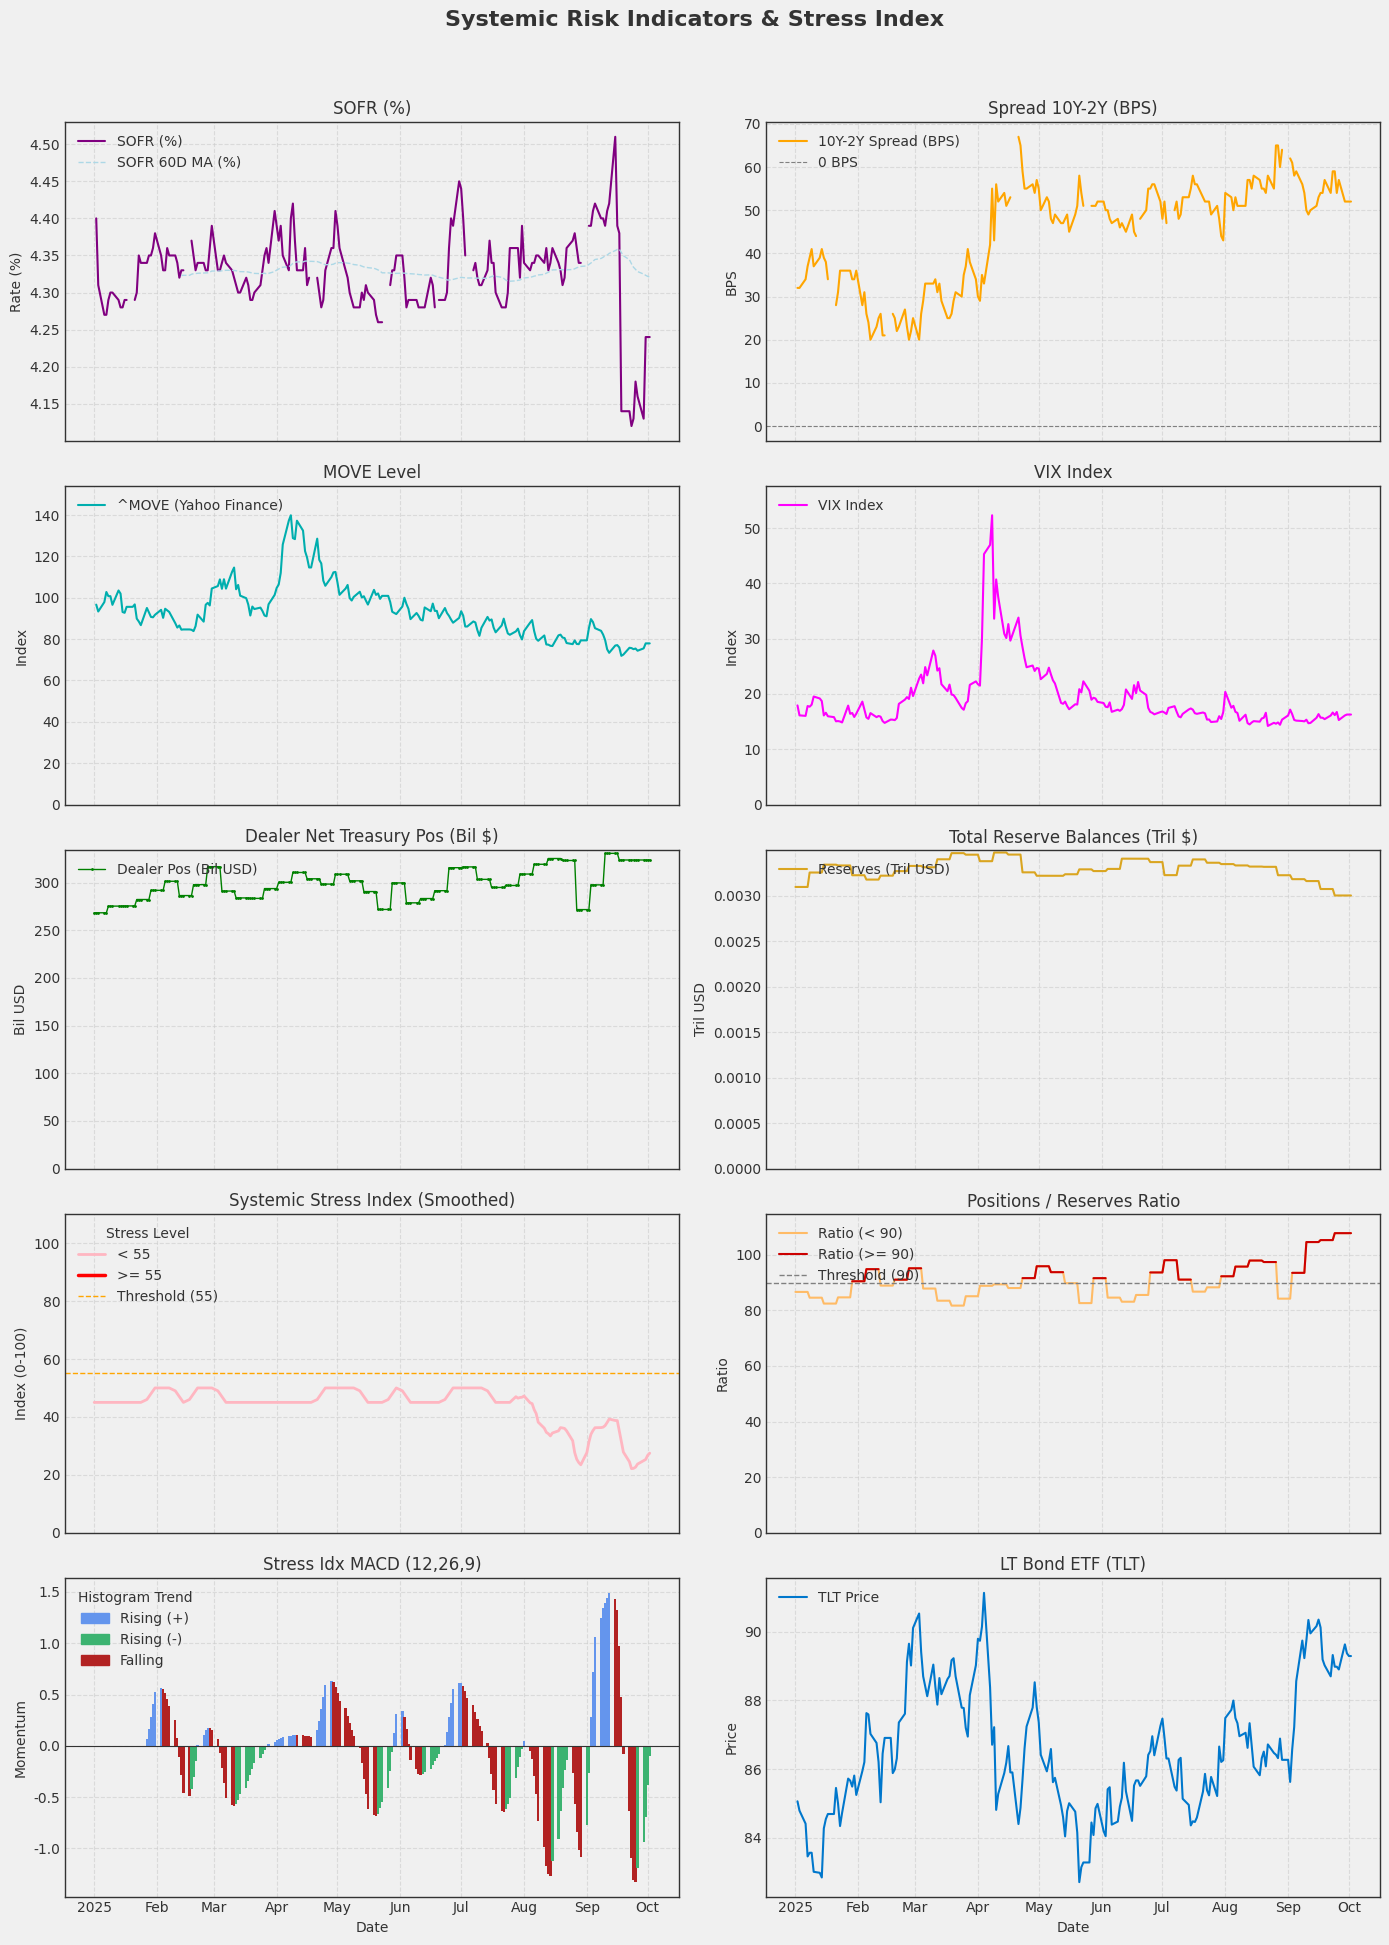

2025-10-01 18:39:12,516 - __main__ - INFO - Cell 9: 產生時間序列圖表 - 繪圖完成，狀態: 成功


  [plot_results] 圖表已顯示。
    > plot_results 函式調用完成。

儲存格: Cell 9: 產生時間序列圖表 (v1.0) **執行總結報告**
**狀態:** ✅ 成功
**執行時間:** 7.79 秒
**完成時間:** 2025-10-02 02:39:12 CST+0800

**⚙️ 輸入參數詳情:**
{ 'final_df_shape': (197, 18),
  'start_date': '2025-01-01',
  'end_date': '2025-10-02',
  'smoothing_window': 5,
  'threshold_stress': 55,
  'threshold_ratio': 90,
  'enable_macd': True,
  'enable_etf': True,
  'etf_ticker': 'TLT'}

**📝 執行註記:**
- 讀取到 final_df (維度: (197, 18)) 和繪圖函式。
- 已成功調用 plot_results 函式。圖表應顯示在下方。

**📊 主要輸出 / 狀態變更:**
{ 'plots_generated': True,
  'plots_availability': { 'SOFR': np.True_,
                          'Spread': np.True_,
                          'Volatility': np.True_,
                          'VIX': np.True_,
                          'GrossPos': np.True_,
                          'StressIndex': np.True_},
  'reserves_plot_possible': np.True_,
  'ratio_plot_possible': np.True_,
  'macd_plot_possible': np.True_,
  'etf_plot_possible': np.True_,
  'info': '時間序列圖表應已顯示在上方輸出區域。'}



In [ ]:
# -*- coding: utf-8 -*-
# 專案: 一級交易商壓力分析 (模組化版本)
# 版本: 1.0 (Cell 9 - 產生時間序列圖表)
# 日期: 2025-05-03
# 地點: 台灣 高雄市 三民區
# ==================================================
# @title Cell 9: 產生時間序列圖表
# --------------------------------------------------
# 功能: 調用 Cell 2 中定義的 `plot_results` 函式，繪製包含多個指標
#       (SOFR, Spread, MOVE, VIX, 持有量, 準備金, 比率, 壓力指數, MACD, ETF)
#       的時間序列圖表。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1', 'Cell 2', 'Cell 3', 'Cell 8']
# 輸入: ['global:final_df', 'global:PROJECT_CONFIG', 'global:validated_start_dt',
#        'global:validated_end_dt', 'global:libs_loaded']
# 輸出: (在儲存格輸出區域顯示 Matplotlib 圖表)
#       (更新 EXECUTION_TRACKER)
# ==================================================

# ==================================================
# 設計註解 (整合版 v2.7.1 - 開頭)
# --------------------------------------------------
# ## 本儲存格主要完成事項：
# * **檢查依賴**: 驗證 Cell 1, 2, 3, 8 是否成功執行，確保 `final_df`,
#   `PROJECT_CONFIG`, `validated_start_dt`, `validated_end_dt` 可用，
#   且繪圖相關函式庫 (matplotlib, pandas, numpy) 和 `plot_results` 函式已定義。
# * **準備參數**:
#   * 從 `PROJECT_CONFIG` 提取繪圖所需的參數 (平滑窗口, 閾值, 顏色, ETF Ticker等)。
#   * **檢查數據可用性**: 根據 `final_df` 中實際存在的數據欄位和非空值情況，
#     確定哪些圖表可以繪製 (設置 `*_ok` 標誌)。例如，檢查 'SOFR' 列是否存在且有數據，
#     才設置 `sofr_ok = True`。
# * **調用繪圖函式**:
#   * 調用 Cell 2 中定義的 `plot_results` 函式。
#   * 將 `final_df`、繪圖標誌字典、相關參數和日期範圍傳遞給函式。
# * **狀態報告**: 在 `finally` 區塊中更新 `EXECUTION_TRACKER` 並打印執行報告。
#
# ## 設計思路/邏輯說明：
# * 將主要的圖表生成步驟放在此儲存格。
# * 核心邏輯是調用已定義好的 `plot_results` 函式。
# * 在調用前仔細檢查每個子圖所需的數據是否真的存在於 `final_df` 中，
#   避免因缺少數據而導致繪圖函式內部出錯。
# * 從 `PROJECT_CONFIG` 集中獲取繪圖參數。
#
# ## 重要假設：
# * Cell 1, 2, 3, 8 已成功執行。
# * `final_df` DataFrame 已成功生成並包含計算結果。
# * `plot_results` 函式已在 Cell 2 中成功定義。
# * Matplotlib 函式庫已成功載入。
#
# ## 主要輸出/狀態變更：
# * 在儲存格輸出區域顯示包含多個子圖的 Matplotlib 圖表。
# * `global:EXECUTION_TRACKER`: 更新了此儲存格 (Cell 9) 的執行記錄。
#
# ## 注意事項/後續步驟：
# * 檢查輸出區域是否成功顯示了預期的圖表。
# * 如果圖表未顯示或缺少某些子圖，請檢查 Cell 8 的執行報告，確認相關數據是否
#   成功計算，以及本儲存格的警告訊息。
# * **後續步驟:** 執行 **Cell 10: 產生趨勢圖與儀表板**。
# ==================================================

# --- 標準庫導入 ---
import time
import traceback
import pprint
import logging
from datetime import datetime # 雖然 Cell 1 已導入，為清晰起見再次導入

# --- 第三方庫導入 ---
# 假設 Cell 1 已確保這些庫可用，但為防萬一再次檢查
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt # 主要用於可能的 plt.show() 或錯誤處理
    print("繪圖所需函式庫 (pandas, numpy, matplotlib) 看似可用。")
except ImportError as e:
    print(f"警告：導入繪圖所需函式庫失敗({e})。")
    pd = None
    np = None
    plt = None

# --- 獲取 Logger ---
logger = logging.getLogger(__name__)

# --- 儲存格標識符 ---
_cell_identifier = "Cell 9: 產生時間序列圖表"

# --- 狀態追蹤變數 ---
_cell_start_time = time.time()
_cell_status = "處理中"
_cell_warnings = []
_cell_notes = []
_cell_error = None
_cell_traceback = None
_cell_inputs = {}
_cell_outputs = {'plots_generated': False} # 記錄是否成功調用繪圖
_cell_generated_files = [] # 如果 plot_results 保存文件，可以在那裡添加

# --- 主要執行邏輯 ---
try:
    # --- 0. 檢查依賴 ---
    logger.info(f"{_cell_identifier} - 開始執行...")
    print(f"\n--- {_cell_identifier} (v1.0) 開始執行 ---")

    # 檢查必要的函式庫
    if not pd or not np or not plt or 'libs_loaded' not in globals():
        _cell_status = "失敗"; _cell_error = "依賴錯誤：缺少 pandas, numpy, matplotlib 函式庫或 Cell 1 未成功執行。"; raise ImportError(_cell_error)
    if not libs_loaded.get('pandas') or not libs_loaded.get('numpy') or not libs_loaded.get('matplotlib'):
         _cell_status = "失敗"; _cell_error = f"依賴錯誤：Cell 1 未能成功載入 pandas, numpy 或 matplotlib。"; raise ImportError(_cell_error)

    # 檢查來自先前 Cell 的必要全局變數和函式
    if 'final_df' not in globals() or not isinstance(final_df, pd.DataFrame):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 8 的有效 final_df DataFrame。"; raise NameError(_cell_error)
    if final_df.empty:
        _cell_status = "失敗"; _cell_error = "輸入錯誤：來自 Cell 8 的 final_df 為空，無法繪圖。"; raise ValueError(_cell_error)
    if 'PROJECT_CONFIG' not in globals() or not isinstance(PROJECT_CONFIG, dict):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到有效的 PROJECT_CONFIG。"; raise NameError(_cell_error)
    if 'validated_start_dt' not in globals() or not isinstance(validated_start_dt, pd.Timestamp):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 3 的有效 validated_start_dt。"; raise NameError(_cell_error)
    if 'validated_end_dt' not in globals() or not isinstance(validated_end_dt, pd.Timestamp):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 3 的有效 validated_end_dt。"; raise NameError(_cell_error)
    if 'plot_results' not in globals() or not callable(plot_results):
         _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 2 的 plot_results 函式。"; raise NameError(_cell_error)

    _cell_inputs['final_df_shape'] = final_df.shape
    _cell_inputs['start_date'] = validated_start_dt.strftime('%Y-%m-%d')
    _cell_inputs['end_date'] = validated_end_dt.strftime('%Y-%m-%d')
    _cell_notes.append(f"讀取到 final_df (維度: {final_df.shape}) 和繪圖函式。")
    print(f"  - 步驟 0: 依賴檢查通過。")

    # --- 1. 準備繪圖參數和標誌 ---
    print("  - 步驟 1: 準備繪圖參數和檢查數據可用性...")
    logger.info("步驟 1: 準備繪圖參數...")

    # 從 PROJECT_CONFIG 獲取參數
    smoothing_window = PROJECT_CONFIG.get('smoothing_window_stress_index', 5)
    threshold_stress = PROJECT_CONFIG.get('threshold_high_stress_color', 55)
    threshold_ratio = PROJECT_CONFIG.get('threshold_ratio_color', 90)
    enable_macd = PROJECT_CONFIG.get('enable_macd_momentum_plot', False)
    macd_p = PROJECT_CONFIG.get('macd_params', {})
    macd_c = PROJECT_CONFIG.get('macd_colors', {})
    enable_etf = PROJECT_CONFIG.get('enable_lt_bond_etf_plot', False)
    etf_ticker = PROJECT_CONFIG.get('lt_bond_etf_ticker', '').strip().upper()

    _cell_inputs['smoothing_window'] = smoothing_window
    _cell_inputs['threshold_stress'] = threshold_stress
    _cell_inputs['threshold_ratio'] = threshold_ratio
    _cell_inputs['enable_macd'] = enable_macd
    _cell_inputs['enable_etf'] = enable_etf
    _cell_inputs['etf_ticker'] = etf_ticker

    # 檢查各繪圖所需數據的實際可用性
    plots_available = {}
    plots_available['SOFR'] = 'SOFR' in final_df and final_df['SOFR'].notna().any()
    plots_available['Spread'] = 'Spread_10Y2Y' in final_df and final_df['Spread_10Y2Y'].notna().any()
    plots_available['Volatility'] = 'Volatility_Index' in final_df and final_df['Volatility_Index'].notna().any()
    plots_available['VIX'] = 'VIX' in final_df and final_df['VIX'].notna().any()
    plots_available['GrossPos'] = 'Total_Gross_Positions_Millions' in final_df and final_df['Total_Gross_Positions_Millions'].notna().any()
    plots_available['StressIndex'] = 'Dealer_Stress_Index' in final_df and final_df['Dealer_Stress_Index'].notna().any()

    reserves_ok = 'Reserves' in final_df and final_df['Reserves'].notna().any()
    ratio_ok = 'Pos_Res_Ratio' in final_df and final_df['Pos_Res_Ratio'].notna().any()
    macd_ok = enable_macd and 'Stress_Index_MACD_Hist' in final_df and final_df['Stress_Index_MACD_Hist'].notna().any()

    etf_col_name_plot = f'ETF_{etf_ticker}_Price' if etf_ticker else None
    etf_ok = enable_etf and etf_col_name_plot and etf_col_name_plot in final_df and final_df[etf_col_name_plot].notna().any()

    _cell_outputs['plots_availability'] = plots_available
    _cell_outputs['reserves_plot_possible'] = reserves_ok
    _cell_outputs['ratio_plot_possible'] = ratio_ok
    _cell_outputs['macd_plot_possible'] = macd_ok
    _cell_outputs['etf_plot_possible'] = etf_ok

    print("    > 數據可用性檢查完成:")
    for k, v in plots_available.items(): print(f"      - {k}: {'可繪製' if v else '數據不足'}")
    print(f"      - Reserves: {'可繪製' if reserves_ok else '數據不足'}")
    print(f"      - Ratio: {'可繪製' if ratio_ok else '數據不足'}")
    print(f"      - MACD: {'可繪製' if macd_ok else ('未啟用' if not enable_macd else '數據不足')}")
    print(f"      - ETF ({etf_ticker}): {'可繪製' if etf_ok else ('未啟用/Ticker無效' if not enable_etf or not etf_ticker else '數據不足')}")

    # --- 2. 調用繪圖函式 ---
    print("\n  - 步驟 2: 調用 plot_results 函式生成圖表...")
    logger.info("步驟 2: 調用 plot_results 函式...")

    # 準備波動率指數名稱和來源 (雖然 Cell 5 應該有，但以防萬一)
    # 這裡可以考慮從 EXECUTION_TRACKER 讀取 Cell 5 的輸出，但為簡化直接用預設值
    vol_name = "^MOVE" if plots_available['Volatility'] else "MOVE"
    vol_source = "Yahoo Finance" if plots_available['Volatility'] else "N/A"

    # 檢查是否有任何圖表可以繪製
    can_plot_anything = any(plots_available.values()) or reserves_ok or ratio_ok or macd_ok or etf_ok
    if can_plot_anything:
        try:
            plot_results(
                final_df=final_df,
                plots_to_draw_flags=plots_available,
                vol_index_fetched_name=vol_name,
                vol_data_source=vol_source,
                smoothing_window_stress_index=smoothing_window,
                threshold_high_stress_color=threshold_stress,
                start_dt=validated_start_dt, # 傳遞 datetime 物件
                end_dt=validated_end_dt,     # 傳遞 datetime 物件
                reserves_plot_ok=reserves_ok,
                ratio_plot_ok=ratio_ok,
                threshold_ratio_color=threshold_ratio,
                enable_macd_momentum_plot=enable_macd, # 傳遞啟用標誌
                macd_fast_period=macd_p.get('fast', 12),
                macd_slow_period=macd_p.get('slow', 26),
                macd_signal_period=macd_p.get('signal', 9),
                macd_color_blue=macd_c.get('blue', "#6495ED"),
                macd_color_green=macd_c.get('green', "#3CB371"),
                macd_color_red=macd_c.get('red', "#B22222"),
                lt_bond_etf_plot_ok=etf_ok, # 傳遞實際是否可繪製的標誌
                lt_bond_etf_ticker_used=etf_ticker if etf_ok else None
            )
            _cell_outputs['plots_generated'] = True
            _cell_notes.append("已成功調用 plot_results 函式。圖表應顯示在下方。")
            print("    > plot_results 函式調用完成。")
        except Exception as e_plot:
            _cell_status = "失敗"
            _cell_error = f"調用 plot_results 函式時發生錯誤: {e_plot}"
            _cell_traceback = traceback.format_exc()
            logger.error(f"{_cell_identifier} - 調用繪圖函式失敗", exc_info=True)
            print(f"    > 錯誤：調用繪圖函式失敗: {e_plot}")
            _cell_outputs['plots_generated'] = False
            # 嘗試關閉可能未正常關閉的圖形
            try: plt.close('all')
            except: pass
    else:
        _cell_warnings.append("沒有任何可繪製的時間序列數據。")
        print("    > 警告：沒有任何可繪製的時間序列數據，跳過繪圖。")
        _cell_outputs['plots_generated'] = False


    # --- 標記 Cell 9 執行狀態 ---
    if _cell_status == "處理中": # 如果前面沒有設置為失敗
        _cell_status = "成功"
        if not _cell_outputs['plots_generated'] and can_plot_anything: # 如果有數據但繪圖失敗
             _cell_status = "失敗" # 應該在 except 中處理了，但雙重保險
        elif not can_plot_anything: # 如果本來就沒數據畫
             _cell_status = "成功 (無圖可繪)"
        elif _cell_warnings: # 如果有警告
             _cell_status = "成功 (有警告)"
    logger.info(f"{_cell_identifier} - 繪圖完成，狀態: {_cell_status}")


# --- 異常處理 ---
except (NameError, ValueError, ImportError, KeyError) as e:
    if _cell_status != "失敗": _cell_status = "失敗"; _cell_error = f"執行過程中發生錯誤: {e}"
    if not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗。")
except Exception as e:
    if _cell_status != "失敗":
        _cell_status = "失敗"; _cell_error = f"執行時發生未預期錯誤 ({e.__class__.__name__}): {e}"
        _cell_traceback = traceback.format_exc()
        logger.critical(f"{_cell_identifier} 失敗: {_cell_error}", exc_info=True)
    elif not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗 (未預期錯誤)。")

# --- finally 區塊：執行總結報告 ---
finally:
    _cell_end_time = time.time()
    _cell_duration = _cell_end_time - _cell_start_time
    _final_status_icon = "❓"

    if _cell_status == "失敗": _final_status_icon = "❌"
    elif _cell_status == "跳過": _final_status_icon = "🚫"
    elif "無圖可繪" in _cell_status: _final_status_icon = "📊" # 特殊圖標表示無圖
    elif "有警告" in _cell_status: _final_status_icon = "⚠️"
    elif _cell_status == "成功": _final_status_icon = "✅"

    _current_time_str = "N/A"
    try:
        if 'target_tz' in globals() and target_tz: _report_tz_info = target_tz
        else: _report_tz_info = timezone(timedelta(hours=8), name='UTC+8 (Fallback)')
        _current_time_str = datetime.now(_report_tz_info).strftime('%Y-%m-%d %H:%M:%S %Z%z')
    except Exception as time_err:
        try: _current_time_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S (Local)')
        except Exception as time_err_local: _current_time_str = f"獲取時間錯誤: {time_err_local}"
        if _cell_status != "失敗": _cell_warnings.append(f"報告時間獲取錯誤: {time_err}")

    if 'EXECUTION_TRACKER' not in globals() or not isinstance(EXECUTION_TRACKER, dict):
        EXECUTION_TRACKER = {}
        if _cell_status != "失敗": _cell_warnings.append("EXECUTION_TRACKER 未正確初始化。")

    _tracking_record = {
        'cell_id': _cell_identifier,
        'status_icon': _final_status_icon,
        'status_text': _cell_status,
        'timestamp': _current_time_str,
        'duration_sec': round(_cell_duration, 2),
        'warnings': sorted(list(set(_cell_warnings))),
        'error': _cell_error,
        'traceback': _cell_traceback.strip() if _cell_traceback else None,
        'notes': _cell_notes,
        'inputs': _cell_inputs,
        'outputs': _cell_outputs,
        'generated_files': _cell_generated_files
    }
    try:
        EXECUTION_TRACKER[_cell_identifier] = _tracking_record
    except Exception as tracker_update_err:
         print(f"錯誤: 更新 EXECUTION_TRACKER 時發生異常: {tracker_update_err}")
         try: logger.error(f"更新 EXECUTION_TRACKER 時失敗: {tracker_update_err}", exc_info=True)
         except: pass

    # 打印報告
    print("\n" + "="*80)
    print(f"儲存格: {_cell_identifier} (v1.0) **執行總結報告**")
    print(f"**狀態:** {_final_status_icon} {_cell_status}")
    print(f"**執行時間:** {_cell_duration:.2f} 秒")
    print(f"**完成時間:** {_current_time_str}")
    if _cell_inputs: print("\n**⚙️ 輸入參數詳情:**"); pprint.pprint(_cell_inputs, indent=2, width=70, sort_dicts=False)
    if _cell_notes: print("\n**📝 執行註記:**"); [print(f"- {note}") for note in _cell_notes]
    if _tracking_record.get('warnings'): print("\n**⚠️ 警告訊息:**"); [print(f"- {warning}") for warning in _tracking_record['warnings']]
    if _tracking_record.get('error'): print(f"\n**❌ 錯誤訊息:**\n{_tracking_record['error']}")
    if _tracking_record.get('traceback'):
        print("\n" + "-"*20 + " **詳細錯誤追蹤 (Traceback)** " + "-"*20)
        print(f"<pre>{_tracking_record['traceback']}</pre>")
        print("-" * (46 + len(" 詳細錯誤追蹤 (Traceback) ")))
    print("\n**📊 主要輸出 / 狀態變更:**")
    outputs_display = _tracking_record.get('outputs', {}).copy()
    if _cell_status != "失敗":
        outputs_display['info'] = "時間序列圖表應已顯示在上方輸出區域。"
        if not outputs_display.get('plots_generated', False):
             outputs_display['info'] += " (但實際繪圖可能因數據不足或錯誤而跳過)"
    else:
        outputs_display['info'] = "因執行失敗，未生成圖表。"

    pprint.pprint(outputs_display, indent=2, width=70, sort_dicts=False)
    if _tracking_record.get('generated_files'): print("\n**📄 相關檔案:**"); [print(f"- ./{f_path}") for f_path in _tracking_record['generated_files']]
    print("="*80 + "\n")

    # --- 清理 ---
    try: del _cell_start_time, _cell_end_time, _cell_duration, _cell_status
    except NameError: pass
    try: del _cell_error, _cell_traceback, _cell_warnings, _cell_notes
    except NameError: pass
    try: del _cell_inputs, _cell_outputs, _cell_generated_files
    except NameError: pass
    try: del _final_status_icon, _current_time_str, _tracking_record, _report_tz_info
    except NameError: pass
    try: del smoothing_window, threshold_stress, threshold_ratio, enable_macd, macd_p
    except NameError: pass
    try: del macd_c, enable_etf, etf_ticker, plots_available, reserves_ok, ratio_ok
    except NameError: pass
    try: del macd_ok, etf_col_name_plot, etf_ok, vol_name, vol_source, can_plot_anything
    except NameError: pass
    try: del outputs_display # 清理新增的變數
    except NameError: pass
    # 全局變數保留

# ==================================================
# 頁尾註解 (v2.7.1) - 快速回顧標頭信息
# --------------------------------------------------
# @title Cell 9: 產生時間序列圖表
# 功能: 調用繪圖函式生成包含多個指標的時間序列圖表。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1', 'Cell 2', 'Cell 3', 'Cell 8']
# 輸入: ['global:final_df', 'global:PROJECT_CONFIG', 'global:validated_start_dt', 'global:validated_end_dt', 'global:libs_loaded']
# 輸出: (顯示 Matplotlib 圖表)
# ==================================================

數據預覽與繪圖所需函式庫 (pandas, numpy, matplotlib, IPython) 看似可用。


2025-10-01 18:39:12,725 - __main__ - INFO - Cell 10: 產生趨勢圖與儀表板 - 開始執行...
2025-10-01 18:39:12,727 - __main__ - INFO - 步驟 1: 顯示數據預覽...



--- Cell 10: 產生趨勢圖與儀表板 (v1.0) 開始執行 ---
  - 步驟 0: 依賴檢查通過。

--- 數據預覽 (最近 5 筆有效數據) ---


,SOFR,Spread_10Y2Y,Volatility_Index,VIX,Total_Gross_Positions_Millions,Reserves,Pos_Res_Ratio,Dealer_Stress_Index,Dealer_Stress_Index_Raw,Stress_Index_MACD_Hist,ETF_TLT_Price
2025-09-26 00:00:00,4.160%,57.0 bps,74.38,15.29,"$323,745 Mn","$3,002 Mn",107.84,23.68,19.45,-1.189,88.90
2025-09-29 00:00:00,4.130%,52.0 bps,75.51,16.12,"$323,745 Mn","$3,002 Mn",107.84,24.87,24.54,-0.943,89.63
2025-09-30 00:00:00,4.240%,52.0 bps,77.93,16.28,"$323,745 Mn","$3,002 Mn",107.84,25.27,27.20,-0.692,89.37
2025-10-01 00:00:00,4.240%,52.0 bps,77.93,16.28,"$323,745 Mn","$3,002 Mn",107.84,26.72,27.45,-0.382,89.29
2025-10-02 00:00:00,4.240%,52.0 bps,77.93,16.28,"$323,745 Mn","$3,002 Mn",107.84,27.45,27.69,-0.097,89.29


2025-10-01 18:39:12,754 - __main__ - INFO - 步驟 2: 繪製壓力儀表板...



--- Gemini 主觀壓力儀表板 ---
使用最新壓力指數 (2025-10-02): 27.45 (指數已 5日 中心平滑)

--- [plot_gemini_gauge_mpl] 正在生成壓力儀表板 (輸出: show) ---


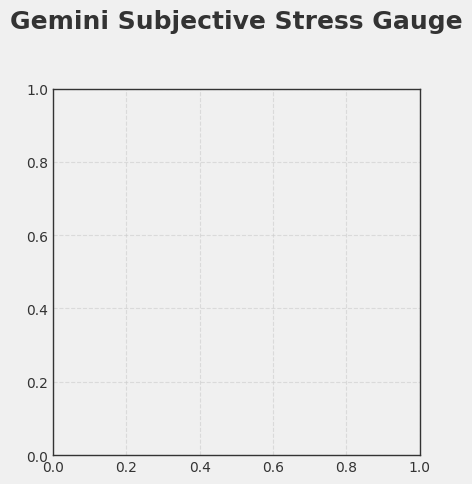

2025-10-01 18:39:13,019 - __main__ - INFO - 步驟 3: 繪製近期趨勢圖...


  [plot_gemini_gauge_mpl] 儀表板已顯示。

--- [plot_trend_colored] 過去 60 天壓力指數趨勢圖 (輸出: show) ---


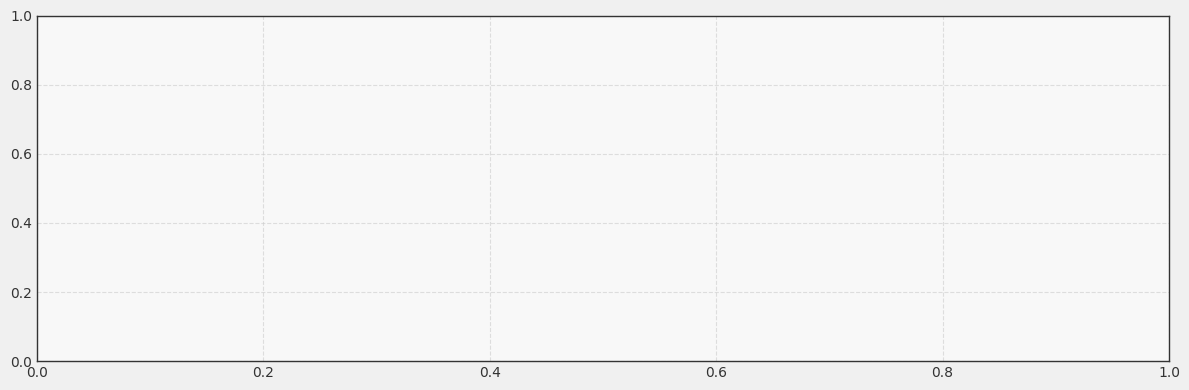

2025-10-01 18:39:13,278 - __main__ - INFO - Cell 10: 產生趨勢圖與儀表板 - 預覽與繪圖完成，狀態: 成功


  [plot_trend_colored] 趨勢圖已顯示。

儲存格: Cell 10: 產生趨勢圖與儀表板 (v1.0) **執行總結報告**
**狀態:** ✅ 成功
**執行時間:** 0.56 秒
**完成時間:** 2025-10-02 02:39:13 CST+0800

**⚙️ 輸入參數詳情:**
{ 'final_df_shape': (197, 18),
  'project_config_keys_subset': ['trend_plot_days'],
  'trend_plot_days': 60}

**📝 執行註記:**
- 讀取到 final_df (維度: (197, 18)) 和繪圖函式。
- 已使用 IPython 顯示格式化數據預覽。
- 壓力儀表板已生成 (值: 27.45, 等級: Normal - Low Side)。
- 近期 (60天) 壓力趨勢圖已生成。

**📊 主要輸出 / 狀態變更:**
{ 'preview_displayed': True,
  'gauge_displayed': True,
  'trend_displayed': True,
  'latest_stress_value': 27.446303319501364,
  'stress_level_en': 'Normal - Low Side',
  'info': '數據預覽、儀表板和趨勢圖應已顯示在上方輸出區域。'}



In [ ]:
# -*- coding: utf-8 -*-
# 專案: 一級交易商壓力分析 (模組化版本)
# 版本: 1.0 (Cell 10 - 產生趨勢圖與儀表板)
# 日期: 2025-05-03
# 地點: 台灣 高雄市 三民區
# ==================================================
# @title Cell 10: 產生趨勢圖與儀表板
# --------------------------------------------------
# 功能: 顯示最終 DataFrame (`final_df`) 的尾部數據預覽。
#       調用 Cell 2 定義的函式，繪製主觀壓力儀表板和近期壓力指數趨勢圖。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1', 'Cell 2', 'Cell 8']
# 輸入: ['global:final_df', 'global:PROJECT_CONFIG', 'global:libs_loaded']
# 輸出: (在儲存格輸出區域顯示數據表格和 Matplotlib 圖表)
#       (更新 EXECUTION_TRACKER)
# ==================================================

# ==================================================
# 設計註解 (整合版 v2.7.1 - 開頭)
# --------------------------------------------------
# ## 本儲存格主要完成事項：
# * **檢查依賴**: 驗證 Cell 1, 2, 8 是否成功執行，確保 `final_df`,
#   `PROJECT_CONFIG` 可用，且繪圖相關函式庫 (matplotlib, pandas, numpy)
#   和 `plot_gemini_gauge_mpl`, `plot_trend_colored` 函式已定義。
#   檢查 `IPython.display` 是否可用於美化表格。
# * **數據預覽**:
#   * 從 `final_df` 中選取需要預覽的欄位。
#   * 移除全為 NaN 的行，選取最後 5 行數據。
#   * 定義各欄位的顯示格式。
#   * 使用 `IPython.display` (若可用) 或 `print` 顯示格式化的數據表格。
# * **繪製儀表板**:
#   * 從 `final_df` 獲取最新的有效壓力指數值。
#   * 根據壓力值和預設閾值 (60, 80) 判斷壓力等級描述 (英文) 和顏色分類。
#   * 調用 Cell 2 的 `plot_gemini_gauge_mpl` 函式繪製儀表板。
#   * 包含錯誤處理，若無法獲取最新壓力值則不繪製。
# * **繪製趨勢圖**:
#   * 從 `PROJECT_CONFIG` 獲取要顯示的趨勢天數 (`trend_plot_days`)。
#   * 獲取壓力指數的時間序列數據。
#   * 調用 Cell 2 的 `plot_trend_colored` 函式繪製帶顏色編碼的趨勢圖。
#   * 包含錯誤處理，若數據不足則不繪製。
# * **狀態報告**: 在 `finally` 區塊中更新 `EXECUTION_TRACKER` 並打印執行報告。
#
# ## 設計思路/邏輯說明：
# * 將數據預覽、儀表板和趨勢圖這三個相關的輸出步驟組合在此儲存格。
# * 重用 Cell 2 中定義的繪圖函式。
# * 從 `PROJECT_CONFIG` 讀取趨勢圖的天數設定。
# * 包含對數據有效性的檢查，確保在有數據時才進行繪圖。
#
# ## 重要假設：
# * Cell 1, 2, 8 已成功執行。
# * `final_df` DataFrame 已成功生成並包含計算結果，特別是 'Dealer_Stress_Index' 列。
# * `plot_gemini_gauge_mpl` 和 `plot_trend_colored` 函式已在 Cell 2 中成功定義。
# * Matplotlib 和 IPython (可選，用於表格) 函式庫已成功載入。
#
# ## 主要輸出/狀態變更：
# * 在儲存格輸出區域顯示數據預覽表格、壓力儀表板圖和壓力趨勢圖。
# * `global:EXECUTION_TRACKER`: 更新了此儲存格 (Cell 10) 的執行記錄。
#
# ## 注意事項/後續步驟：
# * 檢查輸出區域是否成功顯示了預期的表格和圖表。
# * 如果缺少圖表，請檢查 Cell 8 的執行報告確認壓力指數是否成功計算。
# * **後續步驟:** 執行 **Cell 11: 顯示文字分析結果**。
# ==================================================

# --- 標準庫導入 ---
import time
import traceback
import pprint
import logging
from datetime import datetime

# --- 第三方庫導入 ---
# 假設 Cell 1 已確保這些庫可用，但為防萬一再次檢查
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt # 主要用於可能的 plt.show() 或錯誤處理
    # 嘗試導入 IPython 用於美化表格
    from IPython.display import display, HTML
    _IPYTHON_AVAILABLE = True
    print("數據預覽與繪圖所需函式庫 (pandas, numpy, matplotlib, IPython) 看似可用。")
except ImportError:
    _IPYTHON_AVAILABLE = False
    # 檢查核心庫是否至少存在
    try:
        import pandas as pd
        import numpy as np
        import matplotlib.pyplot as plt
        print("警告：無法導入 IPython.display，表格將以純文字顯示。")
        print("核心繪圖庫 (pandas, numpy, matplotlib) 看似可用。")
    except ImportError as e:
        print(f"錯誤：導入核心繪圖所需函式庫失敗({e})。")
        pd = None
        np = None
        plt = None

# --- 獲取 Logger ---
logger = logging.getLogger(__name__)

# --- 儲存格標識符 ---
_cell_identifier = "Cell 10: 產生趨勢圖與儀表板"

# --- 狀態追蹤變數 ---
_cell_start_time = time.time()
_cell_status = "處理中"
_cell_warnings = []
_cell_notes = []
_cell_error = None
_cell_traceback = None
_cell_inputs = {}
_cell_outputs = {'preview_displayed': False, 'gauge_displayed': False, 'trend_displayed': False}
_cell_generated_files = []

# --- 主要執行邏輯 ---
try:
    # --- 0. 檢查依賴 ---
    logger.info(f"{_cell_identifier} - 開始執行...")
    print(f"\n--- {_cell_identifier} (v1.0) 開始執行 ---")

    # 檢查必要的函式庫
    if not pd or not np or not plt or 'libs_loaded' not in globals():
        _cell_status = "失敗"; _cell_error = "依賴錯誤：缺少 pandas, numpy, matplotlib 函式庫或 Cell 1 未成功執行。"; raise ImportError(_cell_error)
    if not libs_loaded.get('pandas') or not libs_loaded.get('numpy') or not libs_loaded.get('matplotlib'):
         _cell_status = "失敗"; _cell_error = f"依賴錯誤：Cell 1 未能成功載入 pandas, numpy 或 matplotlib。"; raise ImportError(_cell_error)

    # 檢查來自先前 Cell 的必要全局變數和函式
    if 'final_df' not in globals() or not isinstance(final_df, pd.DataFrame):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 8 的有效 final_df DataFrame。"; raise NameError(_cell_error)
    if final_df.empty:
        # 如果 final_df 為空，無法繼續
        _cell_status = "跳過"; _cell_notes.append("輸入 DataFrame (final_df) 為空，跳過此儲存格。"); raise ValueError("輸入 DataFrame 為空")
    if 'PROJECT_CONFIG' not in globals() or not isinstance(PROJECT_CONFIG, dict):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到有效的 PROJECT_CONFIG。"; raise NameError(_cell_error)
    if 'plot_gemini_gauge_mpl' not in globals() or not callable(plot_gemini_gauge_mpl):
         _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 2 的 plot_gemini_gauge_mpl 函式。"; raise NameError(_cell_error)
    if 'plot_trend_colored' not in globals() or not callable(plot_trend_colored):
         _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 2 的 plot_trend_colored 函式。"; raise NameError(_cell_error)

    _cell_inputs['final_df_shape'] = final_df.shape
    _cell_inputs['project_config_keys_subset'] = ['trend_plot_days'] # 記錄用到的配置
    _cell_notes.append(f"讀取到 final_df (維度: {final_df.shape}) 和繪圖函式。")
    print(f"  - 步驟 0: 依賴檢查通過。")

    # --- 1. 數據預覽 ---
    print("\n--- 數據預覽 (最近 5 筆有效數據) ---")
    logger.info("步驟 1: 顯示數據預覽...")
    try:
        # 選擇要預覽的列 (與原腳本 Section 12 類似)
        cols_to_preview = []
        preview_cols_map = {
            'SOFR': 'SOFR', 'Spread': 'Spread_10Y2Y', 'MOVE': 'Volatility_Index', 'VIX': 'VIX',
            'GrossPos': 'Total_Gross_Positions_Millions', 'Reserves': 'Reserves', 'Ratio': 'Pos_Res_Ratio',
            'StressIndex': 'Dealer_Stress_Index', 'StressIndexRaw': 'Dealer_Stress_Index_Raw',
            'MACD_Hist': 'Stress_Index_MACD_Hist'
        }
        # 檢查 ETF 列
        etf_ticker_preview = PROJECT_CONFIG.get('lt_bond_etf_ticker', '').strip().upper()
        etf_col_preview = f'ETF_{etf_ticker_preview}_Price' if etf_ticker_preview else None
        if etf_col_preview: preview_cols_map['LT_Bond_ETF'] = etf_col_preview

        for key, col_name in preview_cols_map.items():
            if col_name and col_name in final_df.columns and final_df[col_name].notna().any():
                cols_to_preview.append(col_name)

        if cols_to_preview:
            preview_df = final_df[cols_to_preview].dropna(how='all').tail()

            if not preview_df.empty:
                formatters = {}
                if 'Spread_10Y2Y' in preview_df.columns: formatters['Spread_10Y2Y'] = lambda x: f"{x*100:.1f} bps" if pd.notna(x) else "NaN"
                if 'Total_Gross_Positions_Millions' in preview_df.columns: formatters['Total_Gross_Positions_Millions'] = lambda x: f"${x:,.0f} Mn" if pd.notna(x) else "NaN"
                if 'Reserves' in preview_df.columns: formatters['Reserves'] = lambda x: f"${x:,.0f} Mn" if pd.notna(x) else "NaN"
                if 'Dealer_Stress_Index' in preview_df.columns: formatters['Dealer_Stress_Index'] = '{:.2f}'.format
                if 'Dealer_Stress_Index_Raw' in preview_df.columns: formatters['Dealer_Stress_Index_Raw'] = '{:.2f}'.format
                if 'Volatility_Index' in preview_df.columns: formatters['Volatility_Index'] = '{:.2f}'.format
                if 'VIX' in preview_df.columns: formatters['VIX'] = '{:.2f}'.format
                if 'SOFR' in preview_df.columns: formatters['SOFR'] = lambda x: f"{x:.3f}%" if pd.notna(x) else "NaN"
                if 'Pos_Res_Ratio' in preview_df.columns: formatters['Pos_Res_Ratio'] = '{:.2f}'.format
                if 'Stress_Index_MACD_Hist' in preview_df.columns: formatters['Stress_Index_MACD_Hist'] = '{:.3f}'.format
                if etf_col_preview and etf_col_preview in preview_df.columns: formatters[etf_col_preview] = '{:.2f}'.format

                if _IPYTHON_AVAILABLE:
                    display(HTML(preview_df.style.format(formatters, na_rep='NaN')
                                 .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]},
                                                    {'selector': 'td', 'props': [('text-align', 'right')]}])
                                 .to_html()))
                    _cell_notes.append("已使用 IPython 顯示格式化數據預覽。")
                else:
                    print(preview_df.to_string(formatters=formatters))
                    _cell_notes.append("已使用純文字顯示數據預覽。")
                _cell_outputs['preview_displayed'] = True
            else:
                print("無數據可供預覽 (過濾後為空)。")
                _cell_notes.append("無數據可供預覽。")
        else:
            print("沒有可供預覽的數據欄位。")
            _cell_notes.append("無可預覽欄位。")
    except Exception as e_preview:
        _cell_warnings.append(f"顯示數據預覽時出錯: {e_preview}")
        print(f"警告：顯示數據預覽時出錯: {e_preview}")
        logger.warning("顯示數據預覽時出錯", exc_info=True)

    # --- 2. 繪製壓力儀表板 ---
    print("\n--- Gemini 主觀壓力儀表板 ---")
    logger.info("步驟 2: 繪製壓力儀表板...")
    latest_stress_value = np.nan
    level_desc_en = "Cannot Evaluate"
    color_cat = "Unknown"
    gauge_drawn = False

    if 'Dealer_Stress_Index' in final_df and final_df['Dealer_Stress_Index'].notna().any():
        try:
            latest_stress_series = final_df['Dealer_Stress_Index'].dropna()
            if not latest_stress_series.empty:
                latest_stress_value = latest_stress_series.iloc[-1]
                latest_date_gauge = latest_stress_series.index[-1].strftime('%Y-%m-%d')
                smoothing_status_subj = f"(指數已 {PROJECT_CONFIG.get('smoothing_window_stress_index', 0)}日 中心平滑)" if PROJECT_CONFIG.get('smoothing_window_stress_index', 0) > 1 else "(指數未平滑)"
                print(f"使用最新壓力指數 ({latest_date_gauge}): {latest_stress_value:.2f} {smoothing_status_subj}")

                if latest_stress_value < 60:
                    color_cat = "Green"
                    if latest_stress_value < 30: level_desc_en = "Normal - Low Side"
                    elif latest_stress_value < 50: level_desc_en = "Normal"
                    else: level_desc_en = "Normal - High Side / Approaching Yellow"
                elif 60 <= latest_stress_value < 80:
                    color_cat = "Yellow"; level_desc_en = "High Stress"
                else: # >= 80
                    color_cat = "Red"; level_desc_en = "Extreme Stress / Significant Risk"

                # 調用繪圖函式
                plot_gemini_gauge_mpl(latest_stress_value, level_desc_en, color_cat)
                gauge_drawn = True
                _cell_notes.append(f"壓力儀表板已生成 (值: {latest_stress_value:.2f}, 等級: {level_desc_en})。")
            else:
                print("壓力指數數據有效但為空，無法生成儀表板。")
                _cell_notes.append("壓力指數數據有效但為空，無法生成儀表板。")
        except Exception as e_gauge:
            _cell_warnings.append(f"繪製壓力儀表板時出錯: {e_gauge}")
            print(f"警告：繪製壓力儀表板時出錯: {e_gauge}")
            logger.warning("繪製壓力儀表板時出錯", exc_info=True)
    else:
        print("缺少有效的壓力指數數據 ('Dealer_Stress_Index')，無法生成儀表板。")
        _cell_notes.append("缺少壓力指數數據，無法生成儀表板。")
    _cell_outputs['gauge_displayed'] = gauge_drawn
    _cell_outputs['latest_stress_value'] = float(latest_stress_value) if pd.notna(latest_stress_value) else None
    _cell_outputs['stress_level_en'] = level_desc_en

    # --- 3. 繪製近期趨勢圖 ---
    logger.info("步驟 3: 繪製近期趨勢圖...")
    trend_drawn = False
    if 'Dealer_Stress_Index' in final_df and final_df['Dealer_Stress_Index'].notna().any():
        try:
            days_lookback = int(PROJECT_CONFIG.get('trend_plot_days', 60))
            days_lookback = max(2, days_lookback) # 確保至少 2 天
            _cell_inputs['trend_plot_days'] = days_lookback
            stress_series = final_df['Dealer_Stress_Index'] # 傳遞包含 NaN 的 Series，函式內部會 dropna

            plot_trend_colored(stress_series, days_lookback)
            trend_drawn = True
            _cell_notes.append(f"近期 ({days_lookback}天) 壓力趨勢圖已生成。")
        except Exception as e_trend:
            _cell_warnings.append(f"繪製趨勢圖時出錯: {e_trend}")
            print(f"警告：繪製趨勢圖時出錯: {e_trend}")
            logger.warning("繪製趨勢圖時出錯", exc_info=True)
    else:
        print("缺少有效的壓力指數數據 ('Dealer_Stress_Index')，無法生成趨勢圖。")
        _cell_notes.append("缺少壓力指數數據，無法生成趨勢圖。")
    _cell_outputs['trend_displayed'] = trend_drawn

    # --- 標記 Cell 10 執行狀態 ---
    if _cell_status == "處理中": # 如果前面沒有設置為失敗
        _cell_status = "成功"
        if not gauge_drawn or not trend_drawn: # 如果有圖沒畫出來算警告
            _cell_status = "成功 (部分輸出缺失)"
            _cell_warnings.append("儀表板或趨勢圖未能成功顯示。")
        elif _cell_warnings: # 如果有其他警告
             _cell_status = "成功 (有警告)"
    logger.info(f"{_cell_identifier} - 預覽與繪圖完成，狀態: {_cell_status}")


# --- 異常處理 ---
except (NameError, ValueError, ImportError, KeyError) as e:
    if _cell_status != "失敗": _cell_status = "失敗"; _cell_error = f"執行過程中發生錯誤: {e}"
    if not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗。")
except Exception as e:
    if _cell_status != "失敗":
        _cell_status = "失敗"; _cell_error = f"執行時發生未預期錯誤 ({e.__class__.__name__}): {e}"
        _cell_traceback = traceback.format_exc()
        logger.critical(f"{_cell_identifier} 失敗: {_cell_error}", exc_info=True)
    elif not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗 (未預期錯誤)。")

# --- finally 區塊：執行總結報告 ---
finally:
    _cell_end_time = time.time()
    _cell_duration = _cell_end_time - _cell_start_time
    _final_status_icon = "❓"

    if _cell_status == "失敗": _final_status_icon = "❌"
    elif _cell_status == "跳過": _final_status_icon = "🚫"
    elif "部分輸出缺失" in _cell_status: _final_status_icon = "⚠️"
    elif "有警告" in _cell_status: _final_status_icon = "⚠️"
    elif _cell_status == "成功": _final_status_icon = "✅"

    _current_time_str = "N/A"
    try:
        if 'target_tz' in globals() and target_tz: _report_tz_info = target_tz
        else: _report_tz_info = timezone(timedelta(hours=8), name='UTC+8 (Fallback)')
        _current_time_str = datetime.now(_report_tz_info).strftime('%Y-%m-%d %H:%M:%S %Z%z')
    except Exception as time_err:
        try: _current_time_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S (Local)')
        except Exception as time_err_local: _current_time_str = f"獲取時間錯誤: {time_err_local}"
        if _cell_status != "失敗": _cell_warnings.append(f"報告時間獲取錯誤: {time_err}")

    if 'EXECUTION_TRACKER' not in globals() or not isinstance(EXECUTION_TRACKER, dict):
        EXECUTION_TRACKER = {}
        if _cell_status != "失敗": _cell_warnings.append("EXECUTION_TRACKER 未正確初始化。")

    _tracking_record = {
        'cell_id': _cell_identifier,
        'status_icon': _final_status_icon,
        'status_text': _cell_status,
        'timestamp': _current_time_str,
        'duration_sec': round(_cell_duration, 2),
        'warnings': sorted(list(set(_cell_warnings))),
        'error': _cell_error,
        'traceback': _cell_traceback.strip() if _cell_traceback else None,
        'notes': _cell_notes,
        'inputs': _cell_inputs,
        'outputs': _cell_outputs,
        'generated_files': _cell_generated_files
    }
    try:
        EXECUTION_TRACKER[_cell_identifier] = _tracking_record
    except Exception as tracker_update_err:
         print(f"錯誤: 更新 EXECUTION_TRACKER 時發生異常: {tracker_update_err}")
         try: logger.error(f"更新 EXECUTION_TRACKER 時失敗: {tracker_update_err}", exc_info=True)
         except: pass

    # 打印報告
    print("\n" + "="*80)
    print(f"儲存格: {_cell_identifier} (v1.0) **執行總結報告**")
    print(f"**狀態:** {_final_status_icon} {_cell_status}")
    print(f"**執行時間:** {_cell_duration:.2f} 秒")
    print(f"**完成時間:** {_current_time_str}")
    if _cell_inputs: print("\n**⚙️ 輸入參數詳情:**"); pprint.pprint(_cell_inputs, indent=2, width=70, sort_dicts=False)
    if _cell_notes: print("\n**📝 執行註記:**"); [print(f"- {note}") for note in _cell_notes]
    if _tracking_record.get('warnings'): print("\n**⚠️ 警告訊息:**"); [print(f"- {warning}") for warning in _tracking_record['warnings']]
    if _tracking_record.get('error'): print(f"\n**❌ 錯誤訊息:**\n{_tracking_record['error']}")
    if _tracking_record.get('traceback'):
        print("\n" + "-"*20 + " **詳細錯誤追蹤 (Traceback)** " + "-"*20)
        print(f"<pre>{_tracking_record['traceback']}</pre>")
        print("-" * (46 + len(" 詳細錯誤追蹤 (Traceback) ")))
    print("\n**📊 主要輸出 / 狀態變更:**")
    outputs_display = _tracking_record.get('outputs', {}).copy()
    if _cell_status != "失敗" and _cell_status != "跳過":
        outputs_display['info'] = "數據預覽、儀表板和趨勢圖應已顯示在上方輸出區域。"
    elif _cell_status == "跳過":
         outputs_display['info'] = "因輸入數據為空，跳過執行。"
    else:
        outputs_display['info'] = "因執行失敗，未生成輸出。"
    pprint.pprint(outputs_display, indent=2, width=70, sort_dicts=False)
    if _tracking_record.get('generated_files'): print("\n**📄 相關檔案:**"); [print(f"- ./{f_path}") for f_path in _tracking_record['generated_files']]
    print("="*80 + "\n")

    # --- 清理 ---
    try: del _cell_start_time, _cell_end_time, _cell_duration, _cell_status
    except NameError: pass
    try: del _cell_error, _cell_traceback, _cell_warnings, _cell_notes
    except NameError: pass
    try: del _cell_inputs, _cell_outputs, _cell_generated_files
    except NameError: pass
    try: del _final_status_icon, _current_time_str, _tracking_record, _report_tz_info
    except NameError: pass
    try: del cols_to_preview, preview_cols_map, etf_ticker_preview, etf_col_preview
    except NameError: pass
    try: del key, col_name, preview_df, formatters, latest_stress_value, level_desc_en
    except NameError: pass
    try: del color_cat, gauge_drawn, latest_stress_series, latest_date_gauge, smoothing_status_subj
    except NameError: pass
    try: del trend_drawn, days_lookback, stress_series, outputs_display
    except NameError: pass
    # 全局變數保留

# ==================================================
# 頁尾註解 (v2.7.1) - 快速回顧標頭信息
# --------------------------------------------------
# @title Cell 10: 產生趨勢圖與儀表板
# 功能: 顯示數據預覽，繪製壓力儀表板和近期趨勢圖。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1', 'Cell 2', 'Cell 8']
# 輸入: ['global:final_df', 'global:PROJECT_CONFIG', 'global:libs_loaded']
# 輸出: (顯示數據表格和 Matplotlib 圖表)
# ==================================================

In [ ]:
# -*- coding: utf-8 -*-
# 專案: 一級交易商壓力分析 (模組化版本)
# 版本: 1.0 (Cell 11 - 顯示文字分析結果)
# 日期: 2025-05-03
# 地點: 台灣 高雄市 三民區
# ==================================================
# @title Cell 11: 顯示文字分析結果
# --------------------------------------------------
# 功能: 根據 Cell 8 計算的最新壓力指數值，顯示格式化的文字分析報告，
#       包括歷史事件對比提醒和市場壓力情境分析。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1', 'Cell 8']
# 輸入: ['global:final_df', 'global:libs_loaded']
# 輸出: (在儲存格輸出區域顯示文字或 Markdown 格式的分析報告)
#       (更新 EXECUTION_TRACKER)
# ==================================================

# ==================================================
# 設計註解 (整合版 v2.7.1 - 開頭)
# --------------------------------------------------
# ## 本儲存格主要完成事項：
# * **檢查依賴**: 驗證 Cell 1 和 Cell 8 是否成功執行，確保 `final_df` 可用，
#   且 `pandas`, `numpy` 庫已載入。嘗試導入 `IPython.display` 以支援 Markdown。
# * **獲取最新壓力指數**:
#   * 從 `final_df['Dealer_Stress_Index']` 中提取最新的非 NaN 值。
#   * 處理無法獲取有效值的邊界情況。
# * **產生歷史對比提醒**:
#   * 定義歷史事件及其參考壓力峰值。
#   * 將當前壓力指數與歷史峰值進行比較。
#   * 根據比較結果生成對應的提醒文字。
# * **產生市場情境分析**:
#   * 包含預先定義好的關於壓力指數上升/下降情境下的市場影響和一般性考量文字。
# * **格式化輸出**:
#   * 將歷史對比和情境分析組合成一個完整的報告字串。
#   * **條件化 Markdown**: 如果 `IPython.display.Markdown` 可用，則使用它來顯示
#     格式化的報告；否則，移除 Markdown 語法並打印純文字版本。
# * **狀態報告**: 在 `finally` 區塊中更新 `EXECUTION_TRACKER` 並打印執行報告。
#
# ## 設計思路/邏輯說明：
# * 將文字分析的生成和顯示集中在此儲存格。
# * 分析內容基於最新的量化結果 (壓力指數)。
# * 歷史比較提供相對定位，情境分析提供一般性框架。
# * 使用 Markdown 增強可讀性，並提供純文字回退機制。
# * **免責聲明**: 強調分析內容僅供參考，不構成投資建議。
#
# ## 重要假設：
# * Cell 1 和 Cell 8 已成功執行。
# * `final_df` DataFrame 包含 'Dealer_Stress_Index' 列。
# * `pandas` 和 `numpy` 函式庫已成功載入。
#
# ## 主要輸出/狀態變更：
# * 在儲存格輸出區域顯示文字分析報告 (Markdown 或純文字)。
# * `global:EXECUTION_TRACKER`: 更新了此儲存格 (Cell 11) 的執行記錄。
#
# ## 注意事項/後續步驟：
# * 仔細閱讀輸出的分析內容和免責聲明。
# * **後續步驟:** (可選) 執行 **Cell Z: 執行流程匯總報告** 來查看所有儲存格的狀態。
# ==================================================

# --- 標準庫導入 ---
import time
import traceback
import pprint
import logging
from datetime import datetime

# --- 第三方庫導入 ---
# 假設 Cell 1 已確保這些庫可用，但為防萬一再次檢查
try:
    import pandas as pd
    import numpy as np
    # 嘗試導入 IPython 用於 Markdown 顯示
    from IPython.display import display, Markdown
    _IPYTHON_AVAILABLE_MD = True
    print("文字分析所需函式庫 (pandas, numpy, IPython) 看似可用。")
except ImportError:
    _IPYTHON_AVAILABLE_MD = False
    # 檢查核心庫是否至少存在
    try:
        import pandas as pd
        import numpy as np
        print("警告：無法導入 IPython.display，分析報告將以純文字顯示。")
        print("核心庫 (pandas, numpy) 看似可用。")
    except ImportError as e:
        print(f"錯誤：導入核心所需函式庫失敗({e})。")
        pd = None
        np = None

# --- 獲取 Logger ---
logger = logging.getLogger(__name__)

# --- 儲存格標識符 ---
_cell_identifier = "Cell 11: 顯示文字分析結果"

# --- 狀態追蹤變數 ---
_cell_start_time = time.time()
_cell_status = "處理中"
_cell_warnings = []
_cell_notes = []
_cell_error = None
_cell_traceback = None
_cell_inputs = {}
_cell_outputs = {'analysis_generated': False}
_cell_generated_files = []

# --- 主要執行邏輯 ---
try:
    # --- 0. 檢查依賴 ---
    logger.info(f"{_cell_identifier} - 開始執行...")
    print(f"\n--- {_cell_identifier} (v1.0) 開始執行 ---")

    # 檢查必要的函式庫
    if not pd or not np or 'libs_loaded' not in globals():
        _cell_status = "失敗"; _cell_error = "依賴錯誤：缺少 pandas, numpy 函式庫或 Cell 1 未成功執行。"; raise ImportError(_cell_error)
    if not libs_loaded.get('pandas') or not libs_loaded.get('numpy'):
         _cell_status = "失敗"; _cell_error = f"依賴錯誤：Cell 1 未能成功載入 pandas 或 numpy。"; raise ImportError(_cell_error)

    # 檢查來自 Cell 8 的 final_df
    if 'final_df' not in globals() or not isinstance(final_df, pd.DataFrame):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到來自 Cell 8 的有效 final_df DataFrame。"; raise NameError(_cell_error)
    if final_df.empty:
        _cell_status = "跳過"; _cell_notes.append("輸入 DataFrame (final_df) 為空，無法生成文字分析。"); raise ValueError("輸入 DataFrame 為空")
    if 'Dealer_Stress_Index' not in final_df.columns:
        _cell_status = "失敗"; _cell_error = "輸入錯誤：final_df 中缺少 'Dealer_Stress_Index' 欄位。"; raise KeyError(_cell_error)

    _cell_inputs['final_df_shape'] = final_df.shape
    _cell_inputs['stress_index_column_present'] = True
    _cell_notes.append(f"讀取到 final_df (維度: {final_df.shape})。")
    print(f"  - 步驟 0: 依賴檢查通過。")

    # --- 1. 獲取最新壓力指數值 ---
    print("  - 步驟 1: 獲取最新壓力指數值...")
    logger.info("步驟 1: 獲取最新壓力指數值...")
    latest_stress_value = np.nan
    latest_stress_date = "N/A"
    stress_index_series = final_df['Dealer_Stress_Index'].dropna()

    if not stress_index_series.empty:
        latest_stress_value = stress_index_series.iloc[-1]
        latest_stress_date = stress_index_series.index[-1].strftime('%Y-%m-%d')
        _cell_inputs['latest_stress_value'] = latest_stress_value
        _cell_inputs['latest_stress_date'] = latest_stress_date
        _cell_notes.append(f"獲取到最新壓力指數值: {latest_stress_value:.2f} (日期: {latest_stress_date})")
        print(f"    > 最新壓力指數 ({latest_stress_date}): {latest_stress_value:.2f}")
    else:
        _cell_warnings.append("無法從 final_df 中獲取有效的最新壓力指數值。")
        print("    > 警告：無法獲取有效的最新壓力指數值。")
        # 雖然可以繼續顯示通用文本，但歷史比較將不可用

    # --- 2. 產生歷史對比提醒 ---
    print("  - 步驟 2: 產生歷史對比提醒...")
    logger.info("步驟 2: 產生歷史對比提醒...")
    history_comparison_lines = []
    history_comparison_lines.append("**與歷史事件壓力參考點比較:**")

    if pd.notna(latest_stress_value):
        historical_peaks = {
            "雷曼兄弟時期 (Lehman Era ~2008)": 95, # 假設值
            "新冠疫情衝擊 (COVID Crash 2020)": 80, # 假設值
            "回購利率飆升 (Repo Spike 2019)": 65, # 假設值
            "歐洲主權債務危機 (Euro Crisis ~2011)": 70 # 假設值
        }
        _cell_inputs['historical_peaks_reference'] = historical_peaks
        high_stress_reminder_shown = False
        moderate_stress_reminder_shown = False
        comparison_made = False

        for event, peak_value in historical_peaks.items():
            comparison_made = True
            comparison_text = ""
            reminder = ""
            if latest_stress_value >= peak_value * 0.95:
                comparison_text = f"已達到或超過 **{event}** 的參考水平 (約 {peak_value})"
                reminder = (f"**警示：** 目前壓力水平極高，堪比歷史上的重大危機時期。"
                            f"需極度關注市場流動性、交易對手風險及潜在的系統性問題。")
                if not high_stress_reminder_shown: high_stress_reminder_shown = True
                else: reminder = ""
            elif latest_stress_value >= peak_value * 0.8:
                comparison_text = f"已接近 **{event}** 的參考水平 (約 {peak_value})"
                reminder = (f"**注意：** 壓力水平顯著升高，已進入歷史上相對緊張的區間。"
                            f"建議加強風險管理，評估資產曝險。")
                if not high_stress_reminder_shown and not moderate_stress_reminder_shown:
                    moderate_stress_reminder_shown = True
                else: reminder = ""
            elif latest_stress_value >= peak_value * 0.6:
                comparison_text = f"高於 **{event}** 時期的一半，但仍有距離 (參考約 {peak_value})"
            else:
                comparison_text = f"顯著低於 **{event}** 的參考水平 (約 {peak_value})"

            history_comparison_lines.append(f"* {comparison_text}")
            if reminder:
                 history_comparison_lines.append(f"    * {reminder}") # Markdown 列表下的縮進列表

        if not comparison_made:
            history_comparison_lines.append("* 未設定歷史比較點。")
        _cell_notes.append("已生成歷史對比提醒文字。")
    else:
        history_comparison_lines.append("* 無法獲取當前壓力指數，無法進行歷史比較。")
        _cell_notes.append("因無最新壓力指數，未生成歷史對比。")

    # --- 3. 產生市場情境分析文字 ---
    print("  - 步驟 3: 產生市場情境分析文字...")
    logger.info("步驟 3: 產生市場情境分析文字...")
    scenario_analysis_text = f"""
---

**情境分析：若壓力指數持續上升**

* **一般市場影響：**
    * **債券市場：** 通常伴隨避險情緒升溫，可能導致投資者湧向美國公債等避險資產，壓低公債殖利率（尤其是長天期），債券價格上漲。但若壓力來源於通膨失控或貨幣政策驟緊，殖利率可能反而上升。信用利差（公司債與公債的利差）可能擴大，反映風險趨避。
    * **股票市場：** 波動性（如VIX）通常會顯著升高。投資者風險偏好下降，可能導致股市普遍下跌，尤其是對利率敏感的成長股、小型股及週期性板塊可能承壓較大。防禦性板塊（如公用事業、必需消費品）可能相對抗跌。
    * **資金流動：** 可能出現「現金為王」或流向避險貨幣（如美元、日圓）的現象。
* **一般性策略考量（非建議）：**
    * **風險評估：** 重新評估投資組合的風險敞口，特別是對利率、信用風險和市場波動的敏感度。
    * **現金水平：** 考慮是否需要維持較高的現金或現金等價物水平，以應對潛在的市場波動或捕捉機會。
    * **資產質量：** 關注資產負債表穩健、現金流充裕的高質量公司或債券發行人。
    * **分散配置：** 檢查投資組合的分散程度，確保不過度集中於特定資產類別或板塊。

---

**情境分析：若壓力指數持續下降**

* **一般市場影響：**
    * **債券市場：** 避險情緒降溫，資金可能流出公債，導致殖利率上升（價格下跌）。信用利差可能收窄，反映市場對企業信用的信心增強。
    * **股票市場：** 波動性可能降低。投資者風險偏好提升，可能帶動股市上漲，成長股、小型股及週期性板塊可能表現較好。先前受壓抑的板塊可能出現反彈。
    * **資金流動：** 資金可能從避險資產流向風險資產。
* **一般性策略考量（非建議）：**
    * **機會評估：** 在風險偏好回升的環境下，評估增持風險資產（如股票）或信用債的機會。
    * **板塊輪動：** 關注市場風格是否轉向更有利於成長股或週期股。
    * **再平衡：** 根據市場變化和自身目標，考慮對投資組合進行再平衡。
    * **通膨預期：** 即使壓力下降，仍需關注通膨數據及其對利率前景的影響。
"""
    _cell_notes.append("已生成市場情境分析文字。")

    # --- 4. 組合並顯示報告 ---
    print("  - 步驟 4: 組合並顯示最終分析報告...")
    logger.info("步驟 4: 組合並顯示最終分析報告...")

    # 組合報告內容
    final_report_lines = ["\n--- Gemini 歷史對比與提醒 ---"]
    if pd.notna(latest_stress_value):
        final_report_lines.append(f"**當前 ({latest_stress_date}) 壓力指數:** {latest_stress_value:.2f}\n")
    else:
        final_report_lines.append("**當前壓力指數:** 無法獲取有效值\n")
    final_report_lines.extend(history_comparison_lines)
    final_report_lines.append("\n--- Gemini 市場壓力情境分析與一般性考量 ---")
    final_report_lines.append("\n**>>> 重要免責聲明 <<<**")
    final_report_lines.append(
        "以下內容基於壓力指數的假設性變動，提供一般性的市場觀察和原則性考量，\n"
        "**不構成任何形式的投資建議**。市場實際表現受多重複雜因素影響，\n"
        "任何投資決策請務必諮詢合格的專業財務顧問，並進行獨立判斷。"
    )
    final_report_lines.append(scenario_analysis_text)
    final_report_lines.append(
        "\n---\n\n**再次強調：以上分析僅為一般性原則探討，不能替代專業投資建議。市場變化莫測，請謹慎決策。**"
    )

    final_report_str = "\n".join(final_report_lines)

    # 根據環境選擇輸出方式
    if _IPYTHON_AVAILABLE_MD:
        display(Markdown(final_report_str))
        _cell_notes.append("已使用 Markdown 顯示文字分析報告。")
    else:
        # 純文字回退：移除 Markdown 語法
        plain_text_report = final_report_str.replace('**', '').replace('* ', '- ').replace('    * ', '  > ')
        print(plain_text_report)
        _cell_notes.append("已使用純文字顯示文字分析報告。")

    _cell_outputs['analysis_generated'] = True
    _cell_outputs['report_format'] = 'Markdown' if _IPYTHON_AVAILABLE_MD else 'Plain Text'

    # --- 標記 Cell 11 執行狀態 ---
    if _cell_status == "處理中": # 如果前面沒有設置為失敗
        _cell_status = "成功"
        if _cell_warnings: # 如果有警告
             _cell_status = "成功 (有警告)"
    logger.info(f"{_cell_identifier} - 文字分析顯示完成，狀態: {_cell_status}")


# --- 異常處理 ---
except (NameError, ValueError, ImportError, KeyError) as e:
    if _cell_status != "失敗": _cell_status = "失敗"; _cell_error = f"執行過程中發生錯誤: {e}"
    if not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗。")
except Exception as e:
    if _cell_status != "失敗":
        _cell_status = "失敗"; _cell_error = f"執行時發生未預期錯誤 ({e.__class__.__name__}): {e}"
        _cell_traceback = traceback.format_exc()
        logger.critical(f"{_cell_identifier} 失敗: {_cell_error}", exc_info=True)
    elif not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗 (未預期錯誤)。")

# --- finally 區塊：執行總結報告 ---
finally:
    _cell_end_time = time.time()
    _cell_duration = _cell_end_time - _cell_start_time
    _final_status_icon = "❓"

    if _cell_status == "失敗": _final_status_icon = "❌"
    elif _cell_status == "跳過": _final_status_icon = "🚫"
    elif "有警告" in _cell_status: _final_status_icon = "⚠️"
    elif _cell_status == "成功": _final_status_icon = "✅"

    _current_time_str = "N/A"
    try:
        if 'target_tz' in globals() and target_tz: _report_tz_info = target_tz
        else: _report_tz_info = timezone(timedelta(hours=8), name='UTC+8 (Fallback)')
        _current_time_str = datetime.now(_report_tz_info).strftime('%Y-%m-%d %H:%M:%S %Z%z')
    except Exception as time_err:
        try: _current_time_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S (Local)')
        except Exception as time_err_local: _current_time_str = f"獲取時間錯誤: {time_err_local}"
        if _cell_status != "失敗": _cell_warnings.append(f"報告時間獲取錯誤: {time_err}")

    if 'EXECUTION_TRACKER' not in globals() or not isinstance(EXECUTION_TRACKER, dict):
        EXECUTION_TRACKER = {}
        if _cell_status != "失敗": _cell_warnings.append("EXECUTION_TRACKER 未正確初始化。")

    _tracking_record = {
        'cell_id': _cell_identifier,
        'status_icon': _final_status_icon,
        'status_text': _cell_status,
        'timestamp': _current_time_str,
        'duration_sec': round(_cell_duration, 2),
        'warnings': sorted(list(set(_cell_warnings))),
        'error': _cell_error,
        'traceback': _cell_traceback.strip() if _cell_traceback else None,
        'notes': _cell_notes,
        'inputs': _cell_inputs,
        'outputs': _cell_outputs,
        'generated_files': _cell_generated_files
    }
    try:
        EXECUTION_TRACKER[_cell_identifier] = _tracking_record
    except Exception as tracker_update_err:
         print(f"錯誤: 更新 EXECUTION_TRACKER 時發生異常: {tracker_update_err}")
         try: logger.error(f"更新 EXECUTION_TRACKER 時失敗: {tracker_update_err}", exc_info=True)
         except: pass

    # 打印報告
    print("\n" + "="*80)
    print(f"儲存格: {_cell_identifier} (v1.0) **執行總結報告**")
    print(f"**狀態:** {_final_status_icon} {_cell_status}")
    print(f"**執行時間:** {_cell_duration:.2f} 秒")
    print(f"**完成時間:** {_current_time_str}")
    if _cell_inputs: print("\n**⚙️ 輸入參數詳情:**"); pprint.pprint(_cell_inputs, indent=2, width=70, sort_dicts=False)
    if _cell_notes: print("\n**📝 執行註記:**"); [print(f"- {note}") for note in _cell_notes]
    if _tracking_record.get('warnings'): print("\n**⚠️ 警告訊息:**"); [print(f"- {warning}") for warning in _tracking_record['warnings']]
    if _tracking_record.get('error'): print(f"\n**❌ 錯誤訊息:**\n{_tracking_record['error']}")
    if _tracking_record.get('traceback'):
        print("\n" + "-"*20 + " **詳細錯誤追蹤 (Traceback)** " + "-"*20)
        print(f"<pre>{_tracking_record['traceback']}</pre>")
        print("-" * (46 + len(" 詳細錯誤追蹤 (Traceback) ")))
    print("\n**📊 主要輸出 / 狀態變更:**")
    outputs_display = _tracking_record.get('outputs', {}).copy()
    if _cell_status != "失敗" and _cell_status != "跳過":
        outputs_display['info'] = "文字分析報告應已顯示在上方輸出區域。"
    elif _cell_status == "跳過":
         outputs_display['info'] = "因輸入數據為空，跳過執行。"
    else:
        outputs_display['info'] = "因執行失敗，未生成文字分析報告。"
    pprint.pprint(outputs_display, indent=2, width=70, sort_dicts=False)
    if _tracking_record.get('generated_files'): print("\n**📄 相關檔案:**"); [print(f"- ./{f_path}") for f_path in _tracking_record['generated_files']]
    print("="*80 + "\n")

    # --- 清理 ---
    try: del _cell_start_time, _cell_end_time, _cell_duration, _cell_status
    except NameError: pass
    try: del _cell_error, _cell_traceback, _cell_warnings, _cell_notes
    except NameError: pass
    try: del _cell_inputs, _cell_outputs, _cell_generated_files
    except NameError: pass
    try: del _final_status_icon, _current_time_str, _tracking_record, _report_tz_info
    except NameError: pass
    try: del latest_stress_value, latest_stress_date, stress_index_series, history_comparison_lines
    except NameError: pass
    try: del historical_peaks, high_stress_reminder_shown, moderate_stress_reminder_shown
    except NameError: pass
    try: del comparison_made, event, peak_value, comparison_text, reminder, scenario_analysis_text
    except NameError: pass
    try: del final_report_lines, final_report_str, plain_text_report, outputs_display
    except NameError: pass
    # 全局變數保留

# ==================================================
# 頁尾註解 (v2.7.1) - 快速回顧標頭信息
# --------------------------------------------------
# @title Cell 11: 顯示文字分析結果
# 功能: 根據最新壓力指數顯示歷史對比和市場情境分析文字。
# 版本: 1.0
# 日期: 2025-05-03
# 依賴: ['Cell 1', 'Cell 8']
# 輸入: ['global:final_df', 'global:libs_loaded']
# 輸出: (顯示文字分析報告)
# ==================================================

2025-10-01 18:39:13,401 - __main__ - INFO - Cell 11: 顯示文字分析結果 - 開始執行...
2025-10-01 18:39:13,407 - __main__ - INFO - 步驟 1: 獲取最新壓力指數值...
2025-10-01 18:39:13,412 - __main__ - INFO - 步驟 2: 產生歷史對比提醒...
2025-10-01 18:39:13,413 - __main__ - INFO - 步驟 3: 產生市場情境分析文字...
2025-10-01 18:39:13,417 - __main__ - INFO - 步驟 4: 組合並顯示最終分析報告...


文字分析所需函式庫 (pandas, numpy, IPython) 看似可用。

--- Cell 11: 顯示文字分析結果 (v1.0) 開始執行 ---
  - 步驟 0: 依賴檢查通過。
  - 步驟 1: 獲取最新壓力指數值...
    > 最新壓力指數 (2025-10-02): 27.45
  - 步驟 2: 產生歷史對比提醒...
  - 步驟 3: 產生市場情境分析文字...
  - 步驟 4: 組合並顯示最終分析報告...



--- Gemini 歷史對比與提醒 ---
**當前 (2025-10-02) 壓力指數:** 27.45

**與歷史事件壓力參考點比較:**
* 顯著低於 **雷曼兄弟時期 (Lehman Era ~2008)** 的參考水平 (約 95)
* 顯著低於 **新冠疫情衝擊 (COVID Crash 2020)** 的參考水平 (約 80)
* 顯著低於 **回購利率飆升 (Repo Spike 2019)** 的參考水平 (約 65)
* 顯著低於 **歐洲主權債務危機 (Euro Crisis ~2011)** 的參考水平 (約 70)

--- Gemini 市場壓力情境分析與一般性考量 ---

**>>> 重要免責聲明 <<<**
以下內容基於壓力指數的假設性變動，提供一般性的市場觀察和原則性考量，
**不構成任何形式的投資建議**。市場實際表現受多重複雜因素影響，
任何投資決策請務必諮詢合格的專業財務顧問，並進行獨立判斷。

---

**情境分析：若壓力指數持續上升**

* **一般市場影響：**
    * **債券市場：** 通常伴隨避險情緒升溫，可能導致投資者湧向美國公債等避險資產，壓低公債殖利率（尤其是長天期），債券價格上漲。但若壓力來源於通膨失控或貨幣政策驟緊，殖利率可能反而上升。信用利差（公司債與公債的利差）可能擴大，反映風險趨避。
    * **股票市場：** 波動性（如VIX）通常會顯著升高。投資者風險偏好下降，可能導致股市普遍下跌，尤其是對利率敏感的成長股、小型股及週期性板塊可能承壓較大。防禦性板塊（如公用事業、必需消費品）可能相對抗跌。
    * **資金流動：** 可能出現「現金為王」或流向避險貨幣（如美元、日圓）的現象。
* **一般性策略考量（非建議）：**
    * **風險評估：** 重新評估投資組合的風險敞口，特別是對利率、信用風險和市場波動的敏感度。
    * **現金水平：** 考慮是否需要維持較高的現金或現金等價物水平，以應對潛在的市場波動或捕捉機會。
    * **資產質量：** 關注資產負債表穩健、現金流充裕的高質量公司或債券發行人。
    * **分散配置：** 檢查投資組合的分散程度，確保不過度集中於特定資產類別或板塊。

---

**情境分析：若壓力指數持續下降**

* **一般市場影響：**
    * **債券市場：** 避險情緒降溫，資金可能流出公債，導致殖利率上升（價格下跌）。信用利差可能收窄，反映市場對企業信用的信心增強。
    * **股票市場：** 波動性可能降低。投資者風險偏好提升，可能帶動股市上漲，成長股、小型股及週期性板塊可能表現較好。先前受壓抑的板塊可能出現反彈。
    * **資金流動：** 資金可能從避險資產流向風險資產。
* **一般性策略考量（非建議）：**
    * **機會評估：** 在風險偏好回升的環境下，評估增持風險資產（如股票）或信用債的機會。
    * **板塊輪動：** 關注市場風格是否轉向更有利於成長股或週期股。
    * **再平衡：** 根據市場變化和自身目標，考慮對投資組合進行再平衡。
    * **通膨預期：** 即使壓力下降，仍需關注通膨數據及其對利率前景的影響。


---

**再次強調：以上分析僅為一般性原則探討，不能替代專業投資建議。市場變化莫測，請謹慎決策。**

2025-10-01 18:39:13,426 - __main__ - INFO - Cell 11: 顯示文字分析結果 - 文字分析顯示完成，狀態: 成功



儲存格: Cell 11: 顯示文字分析結果 (v1.0) **執行總結報告**
**狀態:** ✅ 成功
**執行時間:** 0.04 秒
**完成時間:** 2025-10-02 02:39:13 CST+0800

**⚙️ 輸入參數詳情:**
{ 'final_df_shape': (197, 18),
  'stress_index_column_present': True,
  'latest_stress_value': np.float64(27.446303319501364),
  'latest_stress_date': '2025-10-02',
  'historical_peaks_reference': { '雷曼兄弟時期 (Lehman Era ~2008)': 95,
                                  '新冠疫情衝擊 (COVID Crash 2020)': 80,
                                  '回購利率飆升 (Repo Spike 2019)': 65,
                                  '歐洲主權債務危機 (Euro Crisis ~2011)': 70}}

**📝 執行註記:**
- 讀取到 final_df (維度: (197, 18))。
- 獲取到最新壓力指數值: 27.45 (日期: 2025-10-02)
- 已生成歷史對比提醒文字。
- 已生成市場情境分析文字。
- 已使用 Markdown 顯示文字分析報告。

**📊 主要輸出 / 狀態變更:**
{ 'analysis_generated': True,
  'report_format': 'Markdown',
  'info': '文字分析報告應已顯示在上方輸出區域。'}



In [ ]:
# -*- coding: utf-8 -*-
# 專案: 一級交易商壓力分析 (模組化版本)
# 版本: 1.1 (Cell Z - 修正 NameError)
# 日期: 2025-05-03
# 地點: 台灣 高雄市 三民區
# ==================================================
# @title Cell Z: 執行流程匯總報告
# --------------------------------------------------
# 功能: 讀取全局執行追蹤器 EXECUTION_TRACKER，生成並顯示所有已執行儲存格
#       (Cell >= 1) 的狀態摘要表格。
# 版本: 1.1 (修正 NameError)
# 日期: 2025-05-03
# 依賴: ['Cell 1'...'Cell 11'] (隱式依賴 EXECUTION_TRACKER)
# 輸入: ['global:EXECUTION_TRACKER', 'global:libs_loaded'] (檢查 pandas/ipython)
# 輸出: (在儲存格輸出區域顯示摘要表格和詳細信息)
#       (更新 EXECUTION_TRACKER - 可選，記錄此報告 Cell 自身狀態)
# ==================================================

# ==================================================
# 設計註解 (整合版 v2.7.1 - 開頭)
# --------------------------------------------------
# ## 本儲存格主要完成事項：
# * **檢查依賴**: 驗證 Cell 1 是否成功執行並設定了 `EXECUTION_TRACKER`，
#   並檢查 `pandas` 和 `IPython.display` 是否可用於生成格式化表格。
# * **讀取追蹤數據**: 從全局 `EXECUTION_TRACKER` 字典獲取所有儲存格的執行記錄。
# * **處理數據**:
#   * 將追蹤記錄轉換為列表。
#   * 過濾掉無效記錄（非字典）。
#   * **(若 Pandas 可用)** 將有效記錄轉換為 Pandas DataFrame。
#   * 計算警告數量和錯誤摘要等輔助欄位。
# * **格式化顯示**:
#   * **(若 Pandas 和 IPython 可用)**:
#     * 選擇要在摘要表中顯示的欄位。
#     * 重命名欄位為中文。
#     * 定義樣式函數，根據執行狀態（成功、警告、失敗）對表格行進行顏色高亮。
#     * 使用 Pandas Styler 應用樣式並顯示格式化的 HTML 表格。
#     * 遍歷 DataFrame，顯示詳細的警告和錯誤信息（包括 Traceback）。
#     * 計算並顯示最終的統計總結（成功/警告/失敗數量）。
#   * **(若 Pandas 或 IPython 不可用)**:
#     * 使用 `pprint` 或簡單的循環打印原始追蹤數據或基本摘要。
# * **自身報告 (可選但建議)**: 此 Cell 自身也有一個簡化的 `finally` 塊，
#   報告其生成匯總報告的執行狀態。
#
# ## 設計思路/邏輯說明：
# * 提供一個集中的視圖來監控整個筆記本的執行流程。
# * 利用 Pandas 和 IPython (如果可用) 提供美觀、易讀的摘要表格。
# * 提供純文字回退機制，確保在缺少可選庫時仍能提供基本信息。
# * 錯誤處理確保即使追蹤器數據格式略有問題，也能盡可能生成報告。
# * **修正**: 修正了 finally 區塊中記錄 Cell Z 自身狀態時引用錯誤變數的問題。
#
# ## 重要假設：
# * Cell 1 已成功執行並初始化了 `EXECUTION_TRACKER` 字典。
# * 先前的儲存格 (Cell 1-11) 在執行時已按照規範更新了 `EXECUTION_TRACKER`。
# * 為了獲得最佳視覺效果，建議安裝 `pandas` 和 `ipython`。
#
# ## 主要輸出/狀態變更：
# * 在儲存格輸出區域顯示：
#   * (若可用) 格式化的執行狀態摘要表格。
#   * (若可用) 詳細的警告和錯誤信息。
#   * (若可用) 最終統計總結。
#   * (若不可用) 原始追蹤數據或簡化摘要。
# * `global:EXECUTION_TRACKER`: (可選) 更新此儲存格 (Cell Z) 的執行記錄。
#
# ## 注意事項/後續步驟：
# * 此儲存格應在所有主要工作流程儲存格執行完畢後運行。
# * 根據摘要結果，可以快速定位執行失敗或出現警告的儲存格進行檢查。
# * **後續步驟:** 分析結束。
# ==================================================

# --- 標準庫導入 ---
import time
import traceback
import pprint
import logging
from datetime import datetime, timezone, timedelta # 確保 datetime 可用

# --- 第三方庫導入 (嘗試導入) ---
_PANDAS_AVAILABLE_Z = False
_IPYTHON_AVAILABLE_Z = False
try:
    # 檢查是否在 Cell 1 成功載入
    if 'libs_loaded' in globals() and libs_loaded.get('pandas'):
        import pandas as pd
        _PANDAS_AVAILABLE_Z = True
    else:
        pd = None # 確保 pd 為 None

    # 檢查 IPython 是否可用 (主要用於 display 和 HTML)
    if 'libs_loaded' in globals() and libs_loaded.get('ipywidgets'): # ipywidgets 通常伴隨 IPython
         from IPython.display import display, HTML
         _IPYTHON_AVAILABLE_Z = True
    else:
         # 定義備用的 display 和 HTML 函數
         def display(x): print(x)
         def HTML(x): return str(x) # 返回字串
         print("提示: IPython 未安裝或未在 Cell 1 成功加載，將使用純文本格式顯示追蹤摘要。")

    if _PANDAS_AVAILABLE_Z and _IPYTHON_AVAILABLE_Z:
         print("Pandas 和 IPython 可用，將生成格式化摘要。")
    elif _PANDAS_AVAILABLE_Z:
         print("Pandas 可用，但 IPython 不可用，摘要表格將以純文字 DataFrame 形式顯示。")
    else:
         print("提示: Pandas 庫不可用，將使用純文本格式顯示追蹤摘要。")

except ImportError:
     # 這個 except 塊理論上不應該觸發，因為 Cell 1 會處理導入
     print("警告：嘗試再次導入 Pandas 或 IPython 時失敗。")
     pd = None
     def display(x): print(x)
     def HTML(x): return str(x)

# --- 獲取 Logger ---
logger = logging.getLogger(__name__)

# --- 儲存格標識符 ---
_cell_identifier = "Cell Z: 執行流程匯總報告"

# --- 儲存格狀態 (用於此儲存格自身的 finally 報告) ---
_cell_start_time_z = time.time()
_cell_status_z = "處理中"
_cell_error_z = None
_cell_traceback_z = None
_cell_notes_z = [] # 此 Cell 的執行註記
_cell_inputs_z = {'source_cells': [f'Cell {i}' for i in range(1, 12)]} # Cell Z 的輸入是前面所有 Cell 的結果 (隱式)
_cell_outputs_z = {'report_generated': False} # Cell Z 的輸出是報告本身
_cell_generated_files_z = [] # Cell Z 通常不生成文件

try:
    logger.info(f"{_cell_identifier} - 開始執行...")
    print(f"\n--- {_cell_identifier} (v1.1) 開始執行 ---") # 更新版本號
    print("="*80)
    print("                  執行流程匯總報告")
    print("="*80 + "\n")
    _cell_notes_z.append("開始生成執行狀態摘要。")

    # --- 1. 檢查必需的全局變數 ---
    logger.info("步驟 1: 檢查 EXECUTION_TRACKER...")
    if 'EXECUTION_TRACKER' not in globals() or not isinstance(EXECUTION_TRACKER, dict):
        _cell_status_z = "失敗"
        _cell_error_z = "依賴錯誤：找不到全局執行追蹤器 EXECUTION_TRACKER 或其類型錯誤。"
        logger.error(_cell_error_z)
        raise NameError(_cell_error_z)

    tracker_data = EXECUTION_TRACKER
    if not tracker_data:
        print("ℹ️ 執行追蹤器為空，尚無儲存格執行記錄。")
        _cell_status_z = "成功 (無記錄)"
        _cell_notes_z.append("追蹤器為空，無需生成摘要。")
    elif not _PANDAS_AVAILABLE_Z:
        # Pandas 不可用，使用 pprint 打印原始數據
        warning_msg = "⚠️ 警告: Pandas 庫不可用，將以原始格式顯示追蹤數據。"
        print(warning_msg)
        logger.warning(warning_msg)
        _cell_notes_z.append("Pandas 不可用，使用 pprint 顯示原始數據。")
        print("\n**原始追蹤器數據:**")
        pprint.pprint(tracker_data, indent=2, width=80)
        _cell_status_z = "成功 (純文本)"
    else:
        # Pandas 可用，生成摘要表
        logger.info("步驟 2: 使用 Pandas 生成執行摘要表...")
        _cell_notes_z.append("使用 Pandas 生成摘要表。")
        try:
            # --- 2a. 將追蹤器數據轉換為 DataFrame ---
            records = list(tracker_data.values())
            valid_records = [r for r in records if isinstance(r, dict) and 'cell_id' in r] # 確保是字典且有 cell_id
            ignored_count = len(records) - len(valid_records)
            if ignored_count > 0:
                warn_msg = f"發現 {ignored_count} 條無效/缺少 'cell_id' 的追蹤記錄已被忽略。"
                logger.warning(warn_msg); _cell_warnings.append(warn_msg); _cell_notes_z.append(warn_msg) # Cell Z 本身的警告

            if not valid_records:
                 info_msg = "ℹ️ 未找到有效的儲存格執行記錄。"
                 print(info_msg); logger.info(info_msg); _cell_status_z = "成功 (無有效記錄)"; _cell_notes_z.append(info_msg)
            else:
                # 定義基礎列
                columns_in_summary = ['cell_id', 'status_icon', 'status_text', 'timestamp', 'duration_sec', 'warnings', 'error']
                processed_data = []
                for r in valid_records:
                    record_data = {col: r.get(col) for col in columns_in_summary} # 使用 get 避免 KeyError
                    record_data['num_warnings'] = len(record_data.get('warnings', []))
                    error_val = record_data.get('error')
                    record_data['error_summary'] = str(error_val) if error_val is not None else None
                    processed_data.append(record_data)

                if not processed_data:
                     info_msg = "ℹ️ 處理後無有效數據可生成摘要。"
                     print(info_msg); logger.info(info_msg); _cell_status_z = "成功 (無有效數據)"; _cell_notes_z.append(info_msg)
                else:
                    df_summary = pd.DataFrame(processed_data)
                    logger.info(f"成功創建包含 {len(df_summary)} 行的摘要 DataFrame。")
                    _cell_notes_z.append(f"創建了 {len(df_summary)} 行的摘要 DataFrame。")

                    # --- 2b. 格式化並顯示摘要表 ---
                    display_columns = ['cell_id', 'status_icon', 'status_text', 'timestamp', 'duration_sec', 'num_warnings', 'error_summary']
                    for col in display_columns: # 確保列存在
                        if col not in df_summary.columns: df_summary[col] = None
                    df_display = df_summary[display_columns].copy()
                    df_display.rename(columns={
                        'cell_id': '儲存格 ID', 'status_icon': '狀態', 'status_text': '狀態說明',
                        'timestamp': '完成時間', 'duration_sec': '耗時(秒)',
                        'num_warnings': '警告數', 'error_summary': '錯誤摘要'
                    }, inplace=True)

                    def highlight_status(row): # 高亮樣式函數
                        style = [''] * len(row)
                        status_icon = row.get('狀態', '')
                        error_summary = row.get('錯誤摘要', None)
                        is_error = (status_icon == '❌' or (error_summary is not None and str(error_summary).strip() != ''))
                        is_warning = (status_icon == '⚠️' and not is_error)
                        if is_error: style = ['background-color: #F8D7DA; color: #721C24; font-weight: bold;'] * len(row)
                        elif is_warning: style = ['background-color: #FFF3CD; color: #856404;'] * len(row)
                        return style

                    print("\n**📊 儲存格執行狀態摘要 (包含 Cell 1 初始化):**\n")
                    if _IPYTHON_AVAILABLE_Z:
                        try:
                            styled_df = df_display.style.apply(highlight_status, axis=1)\
                                              .set_properties(**{'text-align': 'left', 'vertical-align': 'top'})\
                                              .set_table_styles([dict(selector='th', props=[('text-align', 'left')])])\
                                              .format({'耗時(秒)': "{:.2f}", '警告數': "{:d}"})
                            display(styled_df)
                            _cell_notes_z.append("已使用 IPython 顯示樣式化摘要表。")
                        except Exception as style_err:
                             logger.error(f"應用樣式或顯示 DataFrame 時出錯: {style_err}", exc_info=True)
                             _cell_warnings.append(f"警告: 應用樣式時出錯: {style_err}，回退到純文本顯示。") # Cell Z 警告
                             print("(應用樣式時出錯，回退到純文本顯示)")
                             print(df_display.to_string(index=False))
                    else: # IPython 不可用時，打印普通 DataFrame
                        print(df_display.to_string(index=False))
                        _cell_notes_z.append("IPython 不可用，已顯示純文本摘要表。")

                    # --- 2c. 顯示詳細警告和錯誤 ---
                    warnings_found = df_summary[df_summary['num_warnings'] > 0]
                    errors_found = df_summary[df_summary['error'].notna()]
                    # 詳細警告不過濾 Cell 1
                    if not warnings_found.empty:
                        print("\n" + "-"*30 + " **⚠️ 詳細警告訊息** " + "-"*30)
                        _cell_notes_z.append(f"發現 {len(warnings_found)} 個儲存格有詳細警告。")
                        for index, row in warnings_found.iterrows():
                            print(f"\n**[{row['cell_id']}]** ({row['num_warnings']} 條警告):")
                            original_record = tracker_data.get(row['cell_id'])
                            original_warnings = original_record.get('warnings', []) if original_record else []
                            if original_warnings: [print(f"- {warning}") for warning in original_warnings]
                            else: print("- (無警告內容記錄)")
                    else: _cell_notes_z.append("未發現儲存格的詳細警告。")

                    if not errors_found.empty:
                        print("\n" + "-"*30 + " **❌ 詳細錯誤訊息與追蹤** " + "-"*30)
                        _cell_notes_z.append(f"發現 {len(errors_found)} 個儲存格有錯誤。")
                        for index, row in errors_found.iterrows():
                            print(f"\n**[{row['cell_id']}]**")
                            print(f"錯誤摘要: {row['error_summary']}")
                            original_record = tracker_data.get(row['cell_id'])
                            traceback_info = original_record.get('traceback') if original_record else None
                            if traceback_info:
                                print("-" * 10 + " Traceback " + "-" * 10)
                                if _IPYTHON_AVAILABLE_Z:
                                    try: display(HTML(f"<pre style='white-space: pre-wrap; word-wrap: break-word; background-color: #f8f8f8; border: 1px solid #ddd; padding: 5px;'>{traceback_info}</pre>"))
                                    except Exception as display_err: print(f"(顯示 Traceback 出錯: {display_err})"); print(traceback_info)
                                else: print(traceback_info)
                            else: print("(無詳細追蹤記錄)")
                    else: _cell_notes_z.append("未發現儲存格的錯誤記錄。")

                    # --- 2d. 總結統計 ---
                    num_total_tracked = len(df_summary)
                    init_record_df = df_summary[df_summary['cell_id'].str.startswith("Cell 1:", na=False)]
                    init_failed = not init_record_df.empty and init_record_df['error'].notna().any()
                    workflow_df = df_summary[~df_summary['cell_id'].str.startswith("Cell 1:", na=False)]
                    num_workflow = len(workflow_df)
                    num_workflow_failed = workflow_df['error'].notna().sum()
                    num_workflow_warning_only = workflow_df[(workflow_df['num_warnings'] > 0) & workflow_df['error'].isna()].shape[0]
                    num_workflow_ok = num_workflow - num_workflow_failed - num_workflow_warning_only

                    print("\n" + "="*80)
                    print(f"**總結:** 共追蹤 {num_total_tracked} 個儲存格。")
                    if not init_record_df.empty: print(f"  - {'❌ Cell 1 初始化失敗!' if init_failed else '✅ Cell 1 初始化成功。'}")
                    else: print(f"  - ❓ Cell 1 初始化狀態未知 (未追蹤)。")
                    print(f"\n**工作流程 (Cell >= 2) 狀態 ({num_workflow} 個):**")
                    print(f"  - ✅/👍 成功 (無警告/錯誤): {num_workflow_ok}")
                    print(f"  - ⚠️  僅有警告 (無錯誤): {num_workflow_warning_only}")
                    print(f"  - ❌  失敗 (可能伴隨警告): {num_workflow_failed}")
                    print("="*80)
                    _cell_notes_z.append("已打印最終統計總結。")
                    _cell_status_z = "成功"
                    _cell_outputs_z['report_generated'] = True # 更新 Cell Z 的輸出狀態
                    logger.info("使用 Pandas 生成摘要成功完成。")

        except Exception as e_pandas:
            # 捕獲生成摘要過程中的錯誤
            error_msg = f"使用 Pandas 生成執行摘要時發生錯誤: {e_pandas}"
            print(f"❌ {error_msg}")
            logger.error(error_msg, exc_info=True)
            _cell_status_z = "失敗"
            _cell_error_z = error_msg
            _cell_traceback_z = traceback.format_exc()
            _cell_notes_z.append(f"錯誤: 生成 Pandas 摘要失敗: {e_pandas}")
            # 嘗試打印原始數據
            if 'tracker_data' in locals():
                 print("\n**原始追蹤器數據 (用於除錯):**")
                 pprint.pprint(tracker_data, indent=2, width=80)

# --- 異常處理 (捕獲 Cell Z 自身執行的基本錯誤) ---
except NameError as e:
    error_msg = f"❌ 錯誤: {e}。無法生成摘要。"
    print(error_msg); logger.error(str(e)); _cell_status_z = "失敗"; _cell_error_z = str(e); _cell_notes_z.append(f"失敗: {e}")
except Exception as e:
    error_msg = f"{_cell_identifier} 執行時發生未預期錯誤: {e}"
    print(f"❌ {error_msg}"); logger.error(error_msg, exc_info=True)
    _cell_status_z = "失敗"; _cell_error_z = error_msg; _cell_traceback_z = traceback.format_exc(); _cell_notes_z.append(f"失敗: 發生未預期錯誤: {e}")

# --- finally 區塊：執行總結報告 (Cell Z 自身) ---
finally:
    _cell_end_time_z = time.time()
    _cell_duration_z = _cell_end_time_z - _cell_start_time_z
    _final_status_icon_z = "✅" if _cell_status_z.startswith("成功") else "❌"
    if "警告" in _cell_status_z: _final_status_icon_z = "⚠️"

    _current_time_str_z = "N/A"
    try:
        _report_tz_info_z = target_tz if 'target_tz' in globals() and target_tz else timezone(timedelta(hours=8), name='UTC+8 (Fallback)')
        _current_time_str_z = datetime.now(_report_tz_info_z).strftime('%Y-%m-%d %H:%M:%S %Z%z')
    except Exception as time_err:
        try: _current_time_str_z = datetime.now().strftime('%Y-%m-%d %H:%M:%S (Local)')
        except Exception as time_err_local: _current_time_str_z = f"獲取時間錯誤: {time_err_local}"

    # 可選：更新 EXECUTION_TRACKER 記錄 Cell Z 自身狀態
    _tracking_record_z = {
        'cell_id': _cell_identifier, 'status_icon': _final_status_icon_z, 'status_text': _cell_status_z,
        'timestamp': _current_time_str_z, 'duration_sec': round(_cell_duration_z, 2),
        'warnings': [], # Cell Z 自身的警告已記錄在 _cell_warnings_z (如果需要顯示可以加入)
        'error': _cell_error_z, 'traceback': _cell_traceback_z,
        'notes': _cell_notes_z, # 使用 Cell Z 自身的 notes
        'inputs': _cell_inputs_z, # 使用 Cell Z 自身的 inputs
        'outputs': _cell_outputs_z, # 使用 Cell Z 自身的 outputs
        'generated_files': _cell_generated_files_z # 使用 Cell Z 自身的 generated_files
    }
    try:
        if 'EXECUTION_TRACKER' in globals() and isinstance(EXECUTION_TRACKER, dict):
             EXECUTION_TRACKER[_cell_identifier] = _tracking_record_z
    except Exception as tracker_update_err_z:
         print(f"警告: 更新 Cell Z 自身追蹤記錄時出錯: {tracker_update_err_z}")

    # 打印 Cell Z 自身報告
    print("\n" + "-"*80)
    print(f"**儲存格自身執行報告: {_cell_identifier} (v1.1)**") # 更新版本號
    print(f"**狀態:** {_final_status_icon_z} {_cell_status_z}")
    print(f"**執行時間:** {_cell_duration_z:.2f} 秒")
    print(f"**完成時間:** {_current_time_str_z}")
    if _cell_notes_z: print("**執行註記:**"); [print(f"- {note}") for note in _cell_notes_z]
    if _cell_error_z: print(f"**錯誤訊息:** {_cell_error_z}")
    if _cell_traceback_z: print("**Traceback:**"); print(f"<pre>{_cell_traceback_z}</pre>")
    print("-" * 80 + "\n")

    # --- 清理 ---
    try: del tracker_data, records, valid_records, processed_data, df_summary, df_display
    except NameError: pass
    try: del styled_df, warnings_found, errors_found, workflow_df, init_record_df
    except NameError: pass
    try: del _PANDAS_AVAILABLE_Z, _IPYTHON_AVAILABLE_Z
    except NameError: pass
    try: del _cell_start_time_z, _cell_status_z, _cell_error_z, _cell_traceback_z
    except NameError: pass
    try: del _cell_end_time_z, _cell_duration_z, _final_status_icon_z, _current_time_str_z, _cell_notes_z
    except NameError: pass
    try: del _tracking_record_z, _report_tz_info_z, time_err, time_err_local, error_msg
    except NameError: pass
    try: del num_total_tracked, init_failed, num_workflow, num_workflow_failed, num_workflow_warning_only, num_workflow_ok
    except NameError: pass
    try: del index, row, original_record, original_warnings, traceback_info, display_err
    except NameError: pass
    try: del columns_in_summary, record_data, col, error_val, display_columns, highlight_status, style_err
    except NameError: pass
    try: del info_msg, ignored_count, warn_msg # 清理新增的變數
    except NameError: pass
    try: del _cell_inputs_z, _cell_outputs_z, _cell_generated_files_z # 清理 Cell Z 自身狀態變數
    except NameError: pass
    # 全局變數保留

# ==================================================
# 頁尾註解 (v2.7.1) - 快速回顧標頭信息
# --------------------------------------------------
# @title Cell Z: 執行流程匯總報告
# 功能: 讀取全局執行追蹤器，生成並顯示所有儲存格的狀態摘要。
# 版本: 1.1 (修正 NameError)
# 日期: 2025-05-03
# 依賴: ['Cell 1'...'Cell 11'] (隱式)
# 輸入: ['global:EXECUTION_TRACKER', 'global:libs_loaded']
# 輸出: (顯示摘要表格)
# ==================================================

2025-10-01 18:39:13,570 - __main__ - INFO - Cell Z: 執行流程匯總報告 - 開始執行...
2025-10-01 18:39:13,571 - __main__ - INFO - 步驟 1: 檢查 EXECUTION_TRACKER...
2025-10-01 18:39:13,571 - __main__ - INFO - 步驟 2: 使用 Pandas 生成執行摘要表...
2025-10-01 18:39:13,577 - __main__ - INFO - 成功創建包含 11 行的摘要 DataFrame。


Pandas 和 IPython 可用，將生成格式化摘要。

--- Cell Z: 執行流程匯總報告 (v1.1) 開始執行 ---
                  執行流程匯總報告


**📊 儲存格執行狀態摘要 (包含 Cell 1 初始化):**



,儲存格 ID,狀態,狀態說明,完成時間,耗時(秒),警告數,錯誤摘要
0,Cell 1: 專案初始化與全局設定,💾,成功 (已從設定檔載入),2025-10-02 02:38:59 CST+0800,0.05,0,None
1,Cell 2: 核心函式定義,✅,成功,2025-10-02 02:38:59 CST+0800,0.01,0,None
2,Cell 3: 日期處理與 API 驗證,✅,成功,2025-10-02 02:39:00 CST+0800,0.57,0,None
3,Cell 4: 抓取 FRED 經濟數據,✅,成功,2025-10-02 02:39:01 CST+0800,1.26,0,None
4,Cell 5: 抓取額外市場數據 (Yahoo Finance),✅,成功,2025-10-02 02:39:01 CST+0800,0.24,0,None
5,Cell 6: 抓取並處理 NY Fed 持有量,⚠️,成功 (有警告),2025-10-02 02:39:04 CST+0800,2.24,1,None
6,Cell 7: 合併所有數據源,✅,成功,2025-10-02 02:39:04 CST+0800,0.06,0,None
7,Cell 8: 計算衍生指標與壓力指數,✅,成功,2025-10-02 02:39:04 CST+0800,0.06,0,None
8,Cell 9: 產生時間序列圖表,✅,成功,2025-10-02 02:39:12 CST+0800,7.79,0,None
9,Cell 10: 產生趨勢圖與儀表板,✅,成功,2025-10-02 02:39:13 CST+0800,0.56,0,None


2025-10-01 18:39:13,607 - __main__ - INFO - 使用 Pandas 生成摘要成功完成。



------------------------------ **⚠️ 詳細警告訊息** ------------------------------

**[Cell 6: 抓取並處理 NY Fed 持有量]** (1 條警告):
- 合併了定義可能不同的 SBN(Gross?) 和 SBP(Net?) 數據，解釋需謹慎。

**總結:** 共追蹤 11 個儲存格。
  - ✅ Cell 1 初始化成功。

**工作流程 (Cell >= 2) 狀態 (10 個):**
  - ✅/👍 成功 (無警告/錯誤): 9
  - ⚠️  僅有警告 (無錯誤): 1
  - ❌  失敗 (可能伴隨警告): 0

--------------------------------------------------------------------------------
**儲存格自身執行報告: Cell Z: 執行流程匯總報告 (v1.1)**
**狀態:** ✅ 成功
**執行時間:** 0.04 秒
**完成時間:** 2025-10-02 02:39:13 CST+0800
**執行註記:**
- 開始生成執行狀態摘要。
- 使用 Pandas 生成摘要表。
- 創建了 11 行的摘要 DataFrame。
- 已使用 IPython 顯示樣式化摘要表。
- 發現 1 個儲存格有詳細警告。
- 未發現儲存格的錯誤記錄。
- 已打印最終統計總結。
--------------------------------------------------------------------------------



In [ ]:
# -*- coding: utf-8 -*-
# 專案: 一級交易商壓力分析 (模組化版本)
# 版本: 1.1 (Cell 12 - 使用 Checkbox)
# 日期: 2025-05-03
# 地點: 台灣 高雄市 三民區
# ==================================================
# @title Cell 12: 互動式報告參數設定 (使用 Checkbox)
# --------------------------------------------------
# 功能: 提供互動式介面，讓使用者選擇要生成之 HTML 報告的日期範圍
#       (最新狀況、最近 N 天、自訂) 和要包含的圖表 (使用勾選框)。
#       將使用者選擇儲存到全局變數中。
# 版本: 1.1
# 日期: 2025-05-03
# 依賴: ['Cell 1'] (需要 ipywidgets 庫)
# 輸入: (使用者透過 ipywidgets 互動)
#       ['global:PROJECT_CONFIG'] (讀取預設 ETF Ticker)
# 輸出: ['global:report_date_range_type', 'global:report_start_date',
#        'global:report_end_date', 'global:report_charts_selected']
#       (更新 EXECUTION_TRACKER)
# ==================================================

# ==================================================
# 設計註解 (整合版 v2.7.1 - 開頭)
# --------------------------------------------------
# ## 本儲存格主要完成事項：
# * **檢查依賴**: 驗證 Cell 1 是否成功載入 `ipywidgets` 函式庫。
# * **定義可用圖表**: 列出可供使用者選擇的圖表名稱。
# * **創建 Widgets**:
#   * `Dropdown` (日期範圍類型): 提供 "最新狀況", "最近30天", "最近90天", "自訂區間" 選項。
#   * `DatePicker` (開始/結束日期): 用於選擇自訂區間，初始隱藏。
#   * **`Checkbox` 列表 (圖表選擇)**: 為每個可用圖表創建一個勾選框，替代 SelectMultiple。
#   * `Button` (確認按鈕): 觸發參數儲存。
#   * `Output` (訊息區域): 顯示確認或錯誤訊息。
# * **互動邏輯**:
#   * `Dropdown` 的觀察者 (`observe`): 當選擇 "自訂區間" 時顯示日期選擇器，否則隱藏。
#   * 按鈕的 `on_click` 事件處理:
#     * 讀取所有 widget 的當前值。
#     * 驗證自訂區間的日期邏輯 (若選擇)。
#     * **遍歷 Checkbox 列表**，將勾選的圖表名稱加入 `report_charts_selected`。
#     * 驗證是否至少選擇了一個圖表。
#     * 將有效的選擇儲存到對應的全局變數。
#     * 在 Output 區域顯示確認訊息。
# * **佈局與顯示**: 使用 `VBox` 和 `HBox` (或 `GridBox`) 排列 widgets 並顯示。
# * **狀態報告**: 在 `finally` 區塊中更新 `EXECUTION_TRACKER` 並打印執行報告。
#
# ## 設計思路/邏輯說明：
# * 將報告參數的設定集中在此互動式儲存格。
# * 使用 `Dropdown` 和動態顯示的 `DatePicker` 提供靈活的日期範圍選擇。
# * **改用 Checkbox** 列表進行圖表選擇，提高行動裝置易用性。
# * 透過全局變數將使用者的選擇傳遞給下一個儲存格 (Cell 13)。
# * 提供清晰的輸出訊息，引導使用者執行下一步。
#
# ## 重要假設：
# * Cell 1 已成功執行並載入了 `ipywidgets`。
# * 使用者會在此儲存格進行互動並點擊按鈕，然後再執行 Cell 13。
#
# ## 主要輸出/狀態變更：
# * `global:report_date_range_type` (str): 使用者選擇的日期範圍類型。
# * `global:report_start_date` (str or None): 自訂開始日期 (若選擇自訂)。
# * `global:report_end_date` (str or None): 自訂結束日期 (若選擇自訂)。
# * `global:report_charts_selected` (list): 使用者勾選的圖表名稱列表。
# * `global:EXECUTION_TRACKER`: 更新了此儲存格 (Cell 12) 的執行記錄。
#
# ## 注意事項/後續步驟：
# * 執行此儲存格後，請進行互動選擇，並**務必點擊「產生 HTML 報告參數」按鈕**
#   來儲存您的選擇。
# * **後續步驟:** 執行 **Cell 13: 產生 HTML 報告檔**。
# ==================================================

# --- 標準庫導入 ---
import time
import traceback
import pprint
import logging
from datetime import datetime, date, timedelta

# --- 第三方庫導入 ---
try:
    import ipywidgets as widgets
    from ipywidgets import HBox, VBox, Layout # 引入 Layout 控制樣式
    from IPython.display import display, clear_output
    import pandas as pd
    print("互動介面所需函式庫 (ipywidgets, pandas) 看似可用。")
    _WIDGETS_AVAILABLE = True
except ImportError as e:
    print(f"警告：導入互動介面所需函式庫失敗({e})。此儲存格無法正常工作。")
    widgets = None; HBox = None; VBox = None; Layout = None
    display = print; clear_output = lambda wait=True: None
    pd = None
    _WIDGETS_AVAILABLE = False

# --- 獲取 Logger ---
logger = logging.getLogger(__name__)

# --- 儲存格標識符 ---
_cell_identifier = "Cell 12: 互動式報告參數設定"

# --- 狀態追蹤變數 ---
_cell_start_time = time.time()
_cell_status = "處理中"
_cell_warnings = []
_cell_notes = []
_cell_error = None
_cell_traceback = None
_cell_inputs = {}
_cell_outputs = {}
_cell_generated_files = []

# --- 全局變數定義 ---
global report_date_range_type, report_start_date, report_end_date, report_charts_selected
report_date_range_type = None
report_start_date = None
report_end_date = None
report_charts_selected = []

# --- 主要執行邏輯 ---
try:
    # --- 0. 檢查依賴 ---
    logger.info(f"{_cell_identifier} - 開始執行...")
    print(f"\n--- {_cell_identifier} (v1.1) 開始執行 ---") # 更新版本號

    if not _WIDGETS_AVAILABLE or not pd:
        _cell_status = "失敗"; _cell_error = "依賴錯誤：缺少 ipywidgets 或 pandas 函式庫。"; raise ImportError(_cell_error)
    if 'libs_loaded' not in globals() or not libs_loaded.get('ipywidgets'):
         _cell_status = "失敗"; _cell_error = f"依賴錯誤：Cell 1 未能成功載入 ipywidgets。"; raise ImportError(_cell_error)
    if 'PROJECT_CONFIG' not in globals() or not isinstance(PROJECT_CONFIG, dict):
        _cell_status = "失敗"; _cell_error = "依賴錯誤：找不到有效的 PROJECT_CONFIG。"; raise NameError(_cell_error)

    print(f"  - 步驟 0: 依賴檢查通過。")

    # --- 1. 定義互動元件 ---
    print("  - 步驟 1: 定義互動元件...")
    logger.info("步驟 1: 定義互動元件...")

    # 可用圖表選項
    available_charts = [
        "SOFR (%)", "Spread 10Y-2Y (BPS)", "MOVE Level", "VIX Index",
        "Dealer Pos (Bil $)", "Reserves (Tril $)", "Stress Index (Smoothed)",
        "Positions/Reserves Ratio", "Stress Idx MACD",
    ]
    etf_ticker_widget = PROJECT_CONFIG.get('lt_bond_etf_ticker', '').strip().upper()
    if PROJECT_CONFIG.get('enable_lt_bond_etf_plot', False) and etf_ticker_widget:
        available_charts.append(f"LT Bond ETF ({etf_ticker_widget})")
    _cell_inputs['available_charts'] = available_charts

    # 日期範圍選擇
    date_range_options = [
        ("最新狀況", "latest"), ("最近 30 天", "last_30d"), ("最近 90 天", "last_90d"),
        ("最近一年", "last_1y"), ("自訂區間", "custom")
    ]
    date_range_dropdown = widgets.Dropdown(
        options=date_range_options, value="latest", description='報告日期範圍:',
        style={'description_width': 'initial'}
    )
    _cell_inputs['default_date_range_type'] = "latest"

    # 自訂日期選擇器
    try:
        if 'target_tz' in globals() and target_tz: today_widget = datetime.now(target_tz).date()
        else: today_widget = datetime.now(timezone.utc).date()
    except: today_widget = date.today()

    start_date_picker_custom = widgets.DatePicker(description='自訂開始日期:', value=today_widget - timedelta(days=90), disabled=False)
    end_date_picker_custom = widgets.DatePicker(description='自訂結束日期:', value=today_widget, disabled=False)
    custom_date_box = VBox([start_date_picker_custom, end_date_picker_custom])
    custom_date_box.layout.display = 'none'

    # 圖表選擇 (使用 Checkbox)
    print("      - 創建圖表選擇 Checkbox...")
    chart_checkboxes = {} # 使用字典儲存 Checkbox，方便按名稱查找
    default_selected_charts = [
        "Stress Index (Smoothed)", "MOVE Level", "Spread 10Y-2Y (BPS)", "Positions/Reserves Ratio"
    ]
    valid_defaults = [c for c in default_selected_charts if c in available_charts]
    _cell_inputs['default_charts_selected'] = valid_defaults

    checkbox_widgets = []
    for chart_name in available_charts:
        checkbox = widgets.Checkbox(
            value=(chart_name in valid_defaults), # 預設勾選
            description=chart_name,
            disabled=False,
            indent=False, # 減少縮排，更緊湊
            layout=Layout(width='auto', margin='0px 5px 0px 0px') # 自動寬度，加右邊距
        )
        chart_checkboxes[chart_name] = checkbox
        checkbox_widgets.append(checkbox)

    # 將 Checkbox 分成兩欄顯示，更適合手機
    num_charts = len(checkbox_widgets)
    mid_point = (num_charts + 1) // 2
    checkbox_col1 = VBox(checkbox_widgets[:mid_point])
    checkbox_col2 = VBox(checkbox_widgets[mid_point:])
    charts_selection_box = HBox([checkbox_col1, checkbox_col2]) # 水平排列兩欄

    # 確認按鈕和輸出區域
    confirm_button_report = widgets.Button(
        description="✅ 確認參數並準備生成報告", # 更新按鈕文字
        button_style='success',
        tooltip='點擊此按鈕確認以上選擇，然後執行下一個 Cell 生成報告'
    )
    output_area_report = widgets.Output()

    # --- 2. 定義互動邏輯 ---
    print("  - 步驟 2: 定義互動邏輯...")
    logger.info("步驟 2: 定義互動邏輯...")

    def handle_date_range_change(change):
        if change['new'] == 'custom': custom_date_box.layout.display = 'flex' # Use flex for VBox
        else: custom_date_box.layout.display = 'none'
    date_range_dropdown.observe(handle_date_range_change, names='value')

    def on_confirm_report_button_clicked(b):
        global report_date_range_type, report_start_date, report_end_date, report_charts_selected
        global _cell_outputs, _cell_status, _cell_warnings, _cell_notes

        with output_area_report:
            clear_output(wait=True)
            logger.info("報告參數確認按鈕被點擊。")

            selected_range_type = date_range_dropdown.value
            custom_start = None; custom_end = None
            validation_ok = True

            if selected_range_type == 'custom':
                start_obj = start_date_picker_custom.value
                end_obj = end_date_picker_custom.value
                if start_obj and end_obj:
                    if start_obj >= end_obj:
                        print("❌ 錯誤：自訂區間的開始日期必須早於結束日期。"); validation_ok = False
                    else:
                        custom_start = start_obj.strftime('%Y-%m-%d')
                        custom_end = end_obj.strftime('%Y-%m-%d')
                else:
                    print("❌ 錯誤：選擇自訂區間時，必須指定開始和結束日期。"); validation_ok = False

            # 從 Checkbox 收集選擇的圖表
            selected_charts = []
            for chart_name, checkbox in chart_checkboxes.items():
                if checkbox.value:
                    selected_charts.append(chart_name)

            if not selected_charts:
                print("❌ 錯誤：請至少選擇一個要包含在報告中的圖表。"); validation_ok = False

            if validation_ok:
                report_date_range_type = selected_range_type
                report_start_date = custom_start
                report_end_date = custom_end
                report_charts_selected = selected_charts

                _cell_outputs['selected_date_range_type'] = report_date_range_type
                _cell_outputs['selected_start_date'] = report_start_date
                _cell_outputs['selected_end_date'] = report_end_date
                _cell_outputs['selected_charts_count'] = len(report_charts_selected)
                _cell_outputs['selected_charts_list'] = report_charts_selected

                success_msg = (f"✅ 報告參數已設定！\n"
                               f"   - 日期範圍: {dict(date_range_options)[report_date_range_type]}"
                               f"{' (' + report_start_date + ' 至 ' + report_end_date + ')' if report_date_range_type == 'custom' else ''}\n"
                               f"   - 已選圖表: {', '.join(report_charts_selected)}\n"
                               f"➡️ 請執行下一個儲存格 (Cell 13) 來生成 HTML 報告。")
                print(success_msg)
                _cell_notes.append("使用者已確認報告參數。")
                logger.info(f"報告參數已確認: 範圍={report_date_range_type}, 圖表={report_charts_selected}")
                if not _cell_warnings: _cell_status = "成功" # 更新狀態
            else:
                 report_date_range_type = None; report_start_date = None; report_end_date = None; report_charts_selected = []
                 _cell_outputs.pop('selected_date_range_type', None) # 清除記錄

    confirm_button_report.on_click(on_confirm_report_button_clicked)

    # --- 3. 顯示介面 ---
    print("  - 步驟 3: 顯示互動介面...")
    logger.info("步驟 3: 顯示互動介面...")
    ui = VBox([
        widgets.HTML("<h3>請選擇 HTML 報告的參數：</h3>"),
        date_range_dropdown,
        custom_date_box,
        widgets.HTML("<hr>"),
        widgets.Label("選擇圖表:"), # 添加標籤
        charts_selection_box, # 使用包含兩欄 Checkbox 的 HBox
        widgets.HTML("<hr>"),
        confirm_button_report,
        output_area_report
    ])
    display(ui)
    _cell_notes.append("已顯示互動式報告參數設定介面 (使用 Checkbox)。")

    _cell_status = "等待使用者確認"
    logger.info(f"{_cell_identifier} - 介面顯示完成，等待使用者互動。")


# --- 異常處理 ---
except (NameError, ValueError, ImportError, KeyError) as e:
    if _cell_status != "失敗": _cell_status = "失敗"; _cell_error = f"執行過程中發生錯誤: {e}"
    if not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗。")
except Exception as e:
    if _cell_status != "失敗":
        _cell_status = "失敗"; _cell_error = f"執行時發生未預期錯誤 ({e.__class__.__name__}): {e}"
        _cell_traceback = traceback.format_exc()
        logger.critical(f"{_cell_identifier} 失敗: {_cell_error}", exc_info=True)
    elif not _cell_traceback: _cell_traceback = traceback.format_exc()
    print(f"❌ {_cell_identifier} 執行失敗 (未預期錯誤)。")

# --- finally 區塊：執行總結報告 ---
finally:
    _cell_end_time = time.time()
    _cell_duration = _cell_end_time - _cell_start_time
    _final_status_icon = "❓"

    if _cell_status == "失敗": _final_status_icon = "❌"
    elif _cell_status == "跳過": _final_status_icon = "🚫"
    elif "有警告" in _cell_status: _final_status_icon = "⚠️"
    elif _cell_status == "成功": _final_status_icon = "✅"
    elif _cell_status == "等待使用者確認": _final_status_icon = "⏳"

    _current_time_str = "N/A"
    try:
        if 'target_tz' in globals() and target_tz: _report_tz_info = target_tz
        else: _report_tz_info = timezone(timedelta(hours=8), name='UTC+8 (Fallback)')
        _current_time_str = datetime.now(_report_tz_info).strftime('%Y-%m-%d %H:%M:%S %Z%z')
    except Exception as time_err:
        try: _current_time_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S (Local)')
        except Exception as time_err_local: _current_time_str = f"獲取時間錯誤: {time_err_local}"
        if _cell_status != "失敗": _cell_warnings.append(f"報告時間獲取錯誤: {time_err}")

    if 'EXECUTION_TRACKER' not in globals() or not isinstance(EXECUTION_TRACKER, dict):
        EXECUTION_TRACKER = {}
        if _cell_status != "失敗": _cell_warnings.append("EXECUTION_TRACKER 未正確初始化。")

    _tracking_record = {
        'cell_id': _cell_identifier,
        'status_icon': _final_status_icon,
        'status_text': _cell_status,
        'timestamp': _current_time_str,
        'duration_sec': round(_cell_duration, 2),
        'warnings': sorted(list(set(_cell_warnings))),
        'error': _cell_error,
        'traceback': _cell_traceback.strip() if _cell_traceback else None,
        'notes': _cell_notes,
        'inputs': _cell_inputs,
        'outputs': _cell_outputs,
        'generated_files': _cell_generated_files
    }
    try:
        EXECUTION_TRACKER[_cell_identifier] = _tracking_record
    except Exception as tracker_update_err:
         print(f"錯誤: 更新 EXECUTION_TRACKER 時發生異常: {tracker_update_err}")
         try: logger.error(f"更新 EXECUTION_TRACKER 時失敗: {tracker_update_err}", exc_info=True)
         except: pass

    print("\n" + "="*80)
    print(f"儲存格: {_cell_identifier} (v1.1) **執行總結報告**") # 更新版本號
    print(f"**狀態:** {_final_status_icon} {_cell_status}")
    print(f"**執行時間:** {_cell_duration:.2f} 秒")
    print(f"**完成時間:** {_current_time_str}")
    if _cell_inputs: print("\n**⚙️ 輸入參數詳情 (預設/可用選項):**"); pprint.pprint(_cell_inputs, indent=2, width=70, sort_dicts=False)
    if _cell_notes: print("\n**📝 執行註記:**"); [print(f"- {note}") for note in _cell_notes]
    if _tracking_record.get('warnings'): print("\n**⚠️ 警告訊息:**"); [print(f"- {warning}") for warning in _tracking_record['warnings']]
    if _tracking_record.get('error'): print(f"\n**❌ 錯誤訊息:**\n{_tracking_record['error']}")
    if _tracking_record.get('traceback'):
        print("\n" + "-"*20 + " **詳細錯誤追蹤 (Traceback)** " + "-"*20)
        print(f"<pre>{_tracking_record['traceback']}</pre>")
        print("-" * (46 + len(" 詳細錯誤追蹤 (Traceback) ")))
    print("\n**📊 主要輸出 / 狀態變更 (使用者確認後更新):**")
    outputs_display = _tracking_record.get('outputs', {}).copy()
    if not outputs_display.get('selected_date_range_type'):
        outputs_display['info'] = "等待使用者選擇參數並點擊按鈕..."
    pprint.pprint(outputs_display, indent=2, width=70, sort_dicts=False)
    if _tracking_record.get('generated_files'): print("\n**📄 相關檔案:**"); [print(f"- ./{f_path}") for f_path in _tracking_record['generated_files']]
    print("="*80 + "\n")

    # --- 清理 ---
    try: del _cell_start_time, _cell_end_time, _cell_duration, _cell_status
    except NameError: pass
    try: del _cell_error, _cell_traceback, _cell_warnings, _cell_notes
    except NameError: pass
    try: del _cell_inputs, _cell_outputs, _cell_generated_files
    except NameError: pass
    try: del _final_status_icon, _current_time_str, _tracking_record, _report_tz_info
    except NameError: pass
    try: del available_charts, etf_ticker_widget, date_range_options, date_range_dropdown
    except NameError: pass
    try: del today_widget, start_date_picker_custom, end_date_picker_custom, custom_date_box
    except NameError: pass
    try: del default_selected_charts, valid_defaults, chart_checkboxes, checkbox_widgets
    except NameError: pass
    try: del num_charts, mid_point, checkbox_col1, checkbox_col2, charts_selection_box
    except NameError: pass
    try: del confirm_button_report, output_area_report, ui, outputs_display
    except NameError: pass
    # 全局變數和 widget 實例保留

# ==================================================
# 頁尾註解 (v2.7.1) - 快速回顧標頭信息
# --------------------------------------------------
# @title Cell 12: 互動式報告參數設定 (使用 Checkbox)
# 功能: 提供互動介面選擇報告日期範圍和圖表 (使用勾選框)。
# 版本: 1.1
# 日期: 2025-05-03
# 依賴: ['Cell 1']
# 輸入: (使用者互動), ['global:PROJECT_CONFIG']
# 輸出: ['global:report_date_range_type', 'global:report_start_date', 'global:report_end_date', 'global:report_charts_selected']
# ==================================================

2025-10-01 18:39:13,760 - __main__ - INFO - Cell 12: 互動式報告參數設定 - 開始執行...
2025-10-01 18:39:13,761 - __main__ - INFO - 步驟 1: 定義互動元件...


互動介面所需函式庫 (ipywidgets, pandas) 看似可用。

--- Cell 12: 互動式報告參數設定 (v1.1) 開始執行 ---
  - 步驟 0: 依賴檢查通過。
  - 步驟 1: 定義互動元件...
      - 創建圖表選擇 Checkbox...


2025-10-01 18:39:13,946 - __main__ - INFO - 步驟 2: 定義互動邏輯...
2025-10-01 18:39:13,949 - __main__ - INFO - 步驟 3: 顯示互動介面...


  - 步驟 2: 定義互動邏輯...
  - 步驟 3: 顯示互動介面...


2025-10-01 18:39:13,986 - __main__ - INFO - Cell 12: 互動式報告參數設定 - 介面顯示完成，等待使用者互動。



儲存格: Cell 12: 互動式報告參數設定 (v1.1) **執行總結報告**
**狀態:** ⏳ 等待使用者確認
**執行時間:** 0.25 秒
**完成時間:** 2025-10-02 02:39:13 CST+0800

**⚙️ 輸入參數詳情 (預設/可用選項):**
{ 'available_charts': [ 'SOFR (%)',
                        'Spread 10Y-2Y (BPS)',
                        'MOVE Level',
                        'VIX Index',
                        'Dealer Pos (Bil $)',
                        'Reserves (Tril $)',
                        'Stress Index (Smoothed)',
                        'Positions/Reserves Ratio',
                        'Stress Idx MACD',
                        'LT Bond ETF (TLT)'],
  'default_date_range_type': 'latest',
  'default_charts_selected': [ 'Stress Index (Smoothed)',
                               'MOVE Level',
                               'Spread 10Y-2Y (BPS)',
                               'Positions/Reserves Ratio']}

**📝 執行註記:**
- 已顯示互動式報告參數設定介面 (使用 Checkbox)。

**📊 主要輸出 / 狀態變更 (使用者確認後更新):**
{'info': '等待使用者選擇參數並點擊按鈕...'}

